In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pmdarima as pm
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import random
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline

# Rinkinių sujungimas

In [2]:
sentinel_data = pd.read_csv("Sentinel_5p_data.csv")
sentinel_data.head()

,Unnamed: 0,time,absorbing_aerosol_index,cloud_fraction,cloud_top_pressure,cloud_top_height,cloud_base_pressure,cloud_base_height,cloud_optical_depth,NO2_column_number_density,tropospheric_NO2_column_number_density,stratospheric_NO2_column_number_density,NO2_slant_column_number_density,tropopause_pressure,O3_column_number_density,O3_effective_temperature,CO_column_number_density,H2O_column_number_density
0,0,2018-07-04 00:00:00+03:00,-0.621235,NaN,NaN,NaN,NaN,NaN,NaN,0.000077,NaN,0.000062,0.000203,19219.670,NaN,NaN,NaN,NaN
1,1,2018-07-05 00:00:00+03:00,-0.659180,NaN,NaN,NaN,NaN,NaN,NaN,0.000072,0.000011,0.000065,0.000146,19219.450,NaN,NaN,0.027964,1824.4277
2,2,2018-07-06 00:00:00+03:00,-1.010234,NaN,NaN,NaN,NaN,NaN,NaN,0.000079,0.000010,0.000067,0.000198,19218.373,NaN,NaN,0.029050,1257.0642
3,3,2018-07-07 00:00:00+03:00,-1.175477,NaN,NaN,NaN,NaN,NaN,NaN,0.000083,0.000017,0.000069,0.000194,19223.537,NaN,NaN,0.028928,1455.8580
4,4,2018-07-08 00:00:00+03:00,-1.260407,NaN,NaN,NaN,NaN,NaN,NaN,0.000077,0.000006,0.000073,0.000199,19230.297,NaN,NaN,0.028053,1655.6798


In [3]:
sentinel_data = sentinel_data.drop(columns=['Unnamed: 0'])

sentinel_data['time'] = pd.to_datetime(sentinel_data['time'], errors='coerce', utc=True)

sentinel_data['time'] = sentinel_data['time'].dt.tz_convert(None).dt.normalize()

sentinel_data = sentinel_data.set_index('time').sort_index()
sentinel_data.head(10)

,absorbing_aerosol_index,cloud_fraction,cloud_top_pressure,cloud_top_height,cloud_base_pressure,cloud_base_height,cloud_optical_depth,NO2_column_number_density,tropospheric_NO2_column_number_density,stratospheric_NO2_column_number_density,NO2_slant_column_number_density,tropopause_pressure,O3_column_number_density,O3_effective_temperature,CO_column_number_density,H2O_column_number_density
time,,,,,,,,,,,,,,,,
2018-06-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000088,0.000021,0.000066,0.000174,16689.959,NaN,NaN,NaN,NaN
2018-06-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000082,0.000012,0.000066,0.000199,16677.684,NaN,NaN,NaN,NaN
2018-06-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000078,0.000007,0.000063,0.000156,19222.316,NaN,NaN,NaN,NaN
2018-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000075,NaN,0.000063,0.000191,19223.482,NaN,NaN,NaN,NaN
2018-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000075,NaN,0.000062,0.000193,22057.926,NaN,NaN,NaN,NaN
2018-07-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000079,0.000009,0.000066,0.000196,22067.760,NaN,NaN,NaN,NaN
2018-07-03,-0.621235,NaN,NaN,NaN,NaN,NaN,NaN,0.000077,NaN,0.000062,0.000203,19219.670,NaN,NaN,NaN,NaN
2018-07-04,-0.659180,NaN,NaN,NaN,NaN,NaN,NaN,0.000072,0.000011,0.000065,0.000146,19219.450,NaN,NaN,0.027964,1824.4277
2018-07-05,-1.010234,NaN,NaN,NaN,NaN,NaN,NaN,0.000079,0.000010,0.000067,0.000198,19218.373,NaN,NaN,0.029050,1257.0642


In [4]:
sentinel_data_klaipeda = pd.read_csv("Sentinel_5p_data_klaipeda.csv")

sentinel_data_klaipeda= sentinel_data_klaipeda.drop(columns=['Unnamed: 0'])
sentinel_data_klaipeda['time'] = pd.to_datetime(sentinel_data_klaipeda['time'], errors='coerce', utc=True)
sentinel_data_klaipeda['time'] = sentinel_data_klaipeda['time'].dt.tz_convert(None).dt.normalize()

sentinel_data_klaipeda = sentinel_data_klaipeda.set_index('time').sort_index()
sentinel_data_klaipeda = sentinel_data_klaipeda.add_suffix('_klaipeda')
sentinel_data_klaipeda.head()

,absorbing_aerosol_index_klaipeda,CO_column_number_density_klaipeda,H2O_column_number_density_klaipeda,cloud_fraction_klaipeda,cloud_top_pressure_klaipeda,cloud_top_height_klaipeda,cloud_base_pressure_klaipeda,cloud_base_height_klaipeda,cloud_optical_depth_klaipeda,tropospheric_HCHO_column_number_density_klaipeda,...,tropospheric_NO2_column_number_density_klaipeda,stratospheric_NO2_column_number_density_klaipeda,NO2_slant_column_number_density_klaipeda,tropopause_pressure_klaipeda,O3_column_number_density_klaipeda,O3_effective_temperature_klaipeda,SO2_column_number_density_klaipeda,SO2_column_number_density_amf_klaipeda,SO2_slant_column_number_density_klaipeda,SO2_column_number_density_15km_klaipeda
time,,,,,,,,,,,,,,,,,,,,,
2018-06-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000023,0.000068,0.000175,16711.440,NaN,NaN,NaN,NaN,NaN,NaN
2018-06-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000016,0.000067,0.000168,16702.105,NaN,NaN,NaN,NaN,NaN,NaN
2018-06-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000013,0.000072,0.000221,20714.883,NaN,NaN,NaN,NaN,NaN,NaN
2018-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.000065,0.000191,19274.297,NaN,NaN,NaN,NaN,NaN,NaN
2018-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.000061,0.000183,19262.838,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
sentinel_data_ryga = pd.read_csv("Sentinel_5p_data_ryga.csv")

sentinel_data_ryga= sentinel_data_ryga.drop(columns=['Unnamed: 0'])
sentinel_data_ryga['time'] = pd.to_datetime(sentinel_data_ryga['time'], errors='coerce', utc=True)
sentinel_data_ryga['time'] = sentinel_data_ryga['time'].dt.tz_convert(None).dt.normalize()

sentinel_data_ryga = sentinel_data_ryga.set_index('time').sort_index()
sentinel_data_ryga = sentinel_data_ryga.add_suffix('_ryga')
sentinel_data_ryga.head()

,absorbing_aerosol_index_ryga,CO_column_number_density_ryga,H2O_column_number_density_ryga,cloud_fraction_ryga,cloud_top_pressure_ryga,cloud_top_height_ryga,cloud_base_pressure_ryga,cloud_base_height_ryga,cloud_optical_depth_ryga,tropospheric_HCHO_column_number_density_ryga,...,tropospheric_NO2_column_number_density_ryga,stratospheric_NO2_column_number_density_ryga,NO2_slant_column_number_density_ryga,tropopause_pressure_ryga,O3_column_number_density_ryga,O3_effective_temperature_ryga,SO2_column_number_density_ryga,SO2_column_number_density_amf_ryga,SO2_slant_column_number_density_ryga,SO2_column_number_density_15km_ryga
time,,,,,,,,,,,,,,,,,,,,,
2018-06-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000043,0.000068,0.000209,16713.800,NaN,NaN,NaN,NaN,NaN,NaN
2018-06-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000015,0.000067,0.000207,19267.695,NaN,NaN,NaN,NaN,NaN,NaN
2018-06-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000025,0.000072,0.000239,19845.188,NaN,NaN,NaN,NaN,NaN,NaN
2018-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.000066,0.000202,19273.818,NaN,NaN,NaN,NaN,NaN,NaN
2018-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.000064,0.000193,20659.250,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
meteo_data = pd.read_csv("Vilnius_meteo_data_final_2018_2026.csv")
meteo_data.head()

,observationTime,airTemperature,seaLevelPressure,relativeHumidity,missforest_precipitation,xgb_cloudCover,feelsLikeTemperature_fixed,windSpeed_fixed,windGust_fixed,windDirection_fixed
0,2018-07-01,11.295833,1010.637500,72.791667,9.1,89.375000,10.933333,3.762500,13.9,356.0
1,2018-07-02,10.866667,1006.662500,94.000000,11.9,91.500000,10.429167,2.516667,7.0,327.0
2,2018-07-03,13.387500,1008.454167,90.041667,10.0,89.375000,13.387500,2.537500,8.3,271.0
3,2018-07-04,13.591667,1009.237500,88.291667,13.9,88.333333,13.591667,2.358333,8.7,288.0
4,2018-07-05,16.291667,1008.079167,70.208333,0.0,66.000000,16.291667,1.283333,6.1,293.0


In [7]:
meteo_data['observationTime'] = pd.to_datetime(meteo_data['observationTime'])
meteo_data['observationTime'] = meteo_data['observationTime'].dt.normalize()
meteo_data = meteo_data.set_index('observationTime')

In [8]:
cams_data = pd.read_csv("CAMS_data.csv")
cams_data.head()

,Unnamed: 0,time,dust,sia,pm2p5,pans,nmvoc,nh3,pm10
0,0,2018-01-01 00:00:00+02:00,0.027574,3.349921,6.089184,0.407313,2.398289,0.016827,7.808134
1,1,2018-01-02 00:00:00+02:00,0.027978,3.154068,6.762302,0.671220,2.569455,0.063430,9.598956
2,2,2018-01-03 00:00:00+02:00,0.028735,3.811160,5.880989,0.701758,4.656805,0.011970,7.649660
3,3,2018-01-04 00:00:00+02:00,0.004460,4.234188,7.021877,0.677830,5.965854,0.008702,10.568492
4,4,2018-01-05 00:00:00+02:00,0.001764,3.885617,7.876541,0.630805,4.946000,0.023550,13.354506


In [9]:
cams_data = cams_data.drop(columns=['Unnamed: 0'])
cams_data['time'] = pd.to_datetime(cams_data['time'], errors='coerce', utc=True)
cams_data['time'] = cams_data['time'].dt.tz_localize(None).dt.normalize()

cams_data = cams_data.set_index('time')

In [10]:
metop_data = pd.read_csv("../ACSAF/METOP_B_data_Vilnius.csv")
metop_data.head()

,date,BrO,BrO_Error,H2O,H2O_Error,HCHO,HCHO_Error,NO2,NO2Tropo,NO2Tropo_Error,NO2_Error,O3,O3_Error,SO2,SO2_Error
0,2017-01-01,4.353546e+13,9.867955e+12,NaN,NaN,NaN,NaN,1.237005e+15,NaN,NaN,1.543620e+14,304.604390,1.757060,1.056771,3.256420
1,2017-01-02,5.833210e+13,1.117548e+13,NaN,NaN,NaN,NaN,9.244586e+14,-3.286626e+14,1.452435e+15,1.758028e+14,379.464435,1.867822,3.533038,2.935008
2,2017-01-03,5.219061e+13,1.494110e+13,4.332480,28.181491,NaN,NaN,9.831324e+14,NaN,NaN,2.387014e+14,387.543800,1.672608,3.009880,3.890327
3,2017-01-04,3.930048e+13,1.111460e+13,6.211267,33.852913,NaN,NaN,1.290154e+15,NaN,NaN,1.829068e+14,384.132125,2.049642,-0.610197,6.720032
4,2017-01-05,5.243436e+13,9.972223e+12,4.101402,27.298674,NaN,NaN,1.605957e+15,NaN,NaN,1.585830e+14,397.216796,2.102742,13.926733,8.178496


In [11]:
metop_data['date'] = pd.to_datetime(metop_data['date'], errors='coerce', utc=True)
metop_data['date'] = metop_data['date'].dt.tz_localize(None).dt.normalize()

metop_data = metop_data.set_index('date')

In [12]:
combined_data = meteo_data.join(sentinel_data, how='left')
combined_data = combined_data.join(cams_data, how='left')
combined_data = combined_data.join(metop_data, how='left')
combined_data = combined_data.join(sentinel_data_klaipeda, how='left')
combined_data = combined_data.join(sentinel_data_ryga, how='left')

combined_data.tail()

,airTemperature,seaLevelPressure,relativeHumidity,missforest_precipitation,xgb_cloudCover,feelsLikeTemperature_fixed,windSpeed_fixed,windGust_fixed,windDirection_fixed,absorbing_aerosol_index,...,tropospheric_NO2_column_number_density_ryga,stratospheric_NO2_column_number_density_ryga,NO2_slant_column_number_density_ryga,tropopause_pressure_ryga,O3_column_number_density_ryga,O3_effective_temperature_ryga,SO2_column_number_density_ryga,SO2_column_number_density_amf_ryga,SO2_slant_column_number_density_ryga,SO2_column_number_density_15km_ryga
observationTime,,,,,,,,,,,,,,,,,,,,,
2026-01-27,-2.200000,1005.416667,95.625000,3.8,100.000000,-4.162500,1.600000,4.6,70.0,-0.386410,...,0.000027,0.000031,0.000224,19398.450,0.191235,224.46594,NaN,NaN,NaN,NaN
2026-01-28,-5.012500,1002.875000,91.916667,6.0,100.000000,-8.941667,2.495833,7.5,33.0,-0.301222,...,0.000042,0.000030,0.000253,22164.625,0.163251,226.52072,NaN,NaN,NaN,NaN
2026-01-29,-9.604167,1009.787500,87.000000,0.0,81.291667,-14.795833,2.812500,8.3,35.0,-0.406181,...,0.000043,0.000031,0.000238,19294.350,0.200411,226.95917,NaN,NaN,NaN,NaN
2026-01-30,-13.600000,1019.316667,78.833333,0.0,0.541667,-18.804167,2.354167,8.7,42.0,-0.434437,...,0.000024,0.000029,0.000226,19307.096,0.193551,228.29813,NaN,NaN,NaN,NaN
2026-01-31,-15.366667,1025.933333,76.666667,0.0,0.000000,-19.350000,1.720833,4.7,30.0,-0.868755,...,0.000034,0.000033,0.000228,19312.547,0.178348,230.08385,NaN,NaN,NaN,NaN


# Bendro rinkinio apžvalga

In [13]:
def check_data_boundaries(df):
    boundaries = []
    
    for col in df.columns:
        first_idx = df[col].first_valid_index()
        last_idx = df[col].last_valid_index()
        
        count_not_na = df[col].count()
        
        boundaries.append({
            'Stulpelis': col,
            'Pirma ne NA': first_idx,
            'Paskutinė ne NA': last_idx,
            'Viso taškų': count_not_na
        })
    
    boundary_df = pd.DataFrame(boundaries)
    return boundary_df

In [14]:
info_table = check_data_boundaries(combined_data)
print(info_table.to_string(index=False))

                                                     Stulpelis Pirma ne NA Paskutinė ne NA  Viso taškų
                                                airTemperature  2018-07-01      2026-01-31        2772
                                              seaLevelPressure  2018-07-01      2026-01-31        2772
                                              relativeHumidity  2018-07-01      2026-01-31        2772
                                      missforest_precipitation  2018-07-01      2026-01-31        2772
                                                xgb_cloudCover  2018-07-01      2026-01-31        2772
                                    feelsLikeTemperature_fixed  2018-07-01      2026-01-31        2772
                                               windSpeed_fixed  2018-07-01      2026-01-31        2772
                                                windGust_fixed  2018-07-01      2026-01-31        2772
                                           windDirection_fixed  2018-07-0

In [15]:
cut_combined_data = combined_data.loc['2018-07-01':'2026-01-31'].copy()

In [16]:
missing_percent = cut_combined_data.isnull().mean() * 100
print(missing_percent.to_string())

airTemperature                                                     0.000000
seaLevelPressure                                                   0.000000
relativeHumidity                                                   0.000000
missforest_precipitation                                           0.000000
xgb_cloudCover                                                     0.000000
feelsLikeTemperature_fixed                                         0.000000
windSpeed_fixed                                                    0.000000
windGust_fixed                                                     0.000000
windDirection_fixed                                                0.000000
absorbing_aerosol_index                                            0.901876
cloud_fraction                                                     7.178932
cloud_top_pressure                                                10.966811
cloud_top_height                                                  11.002886
cloud_base_p

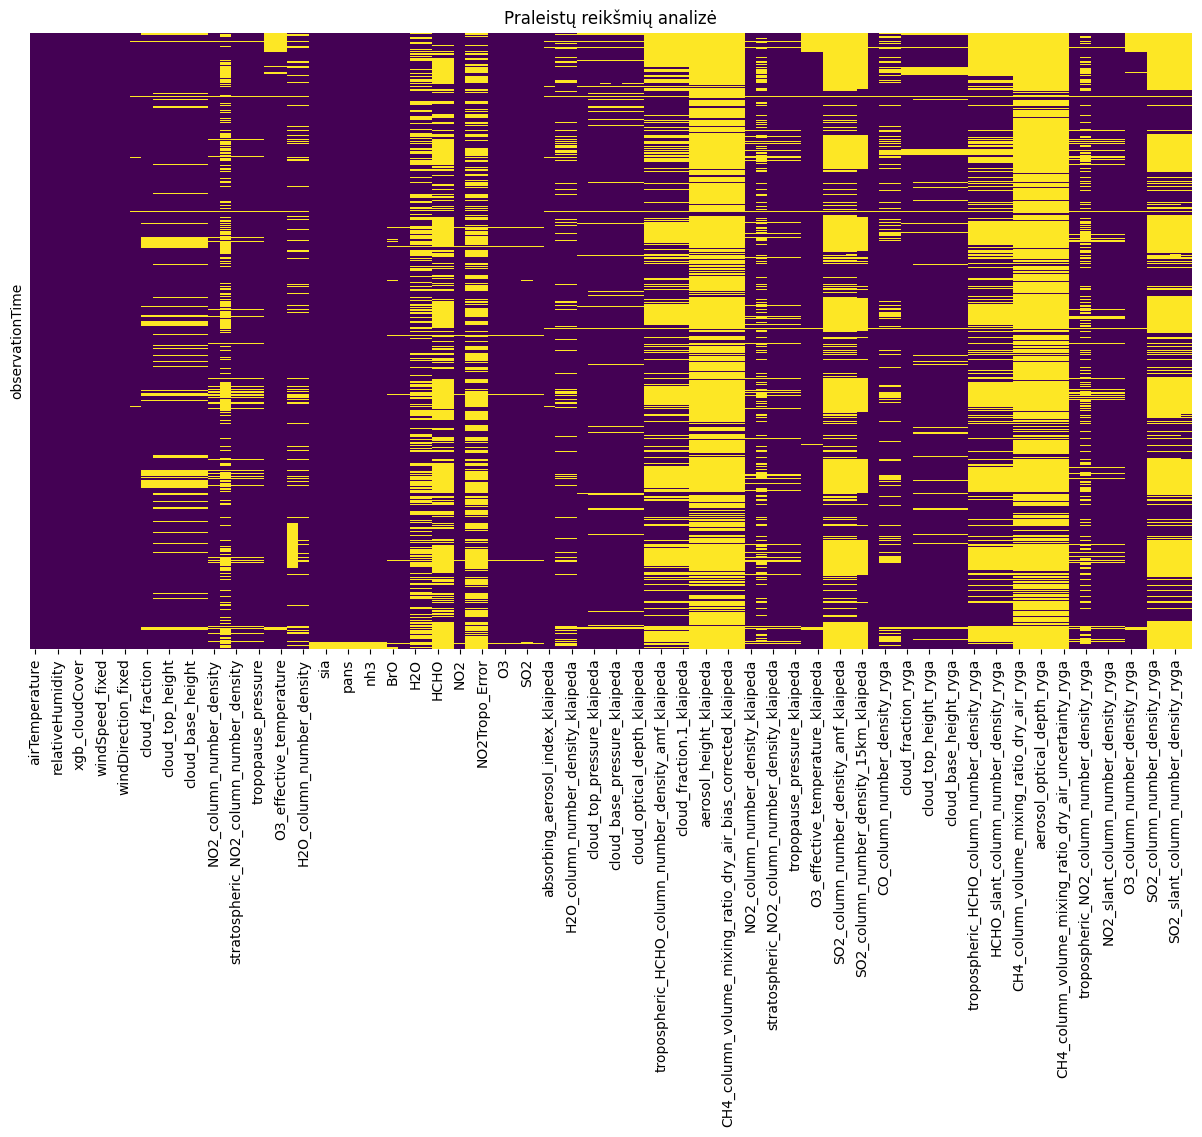

In [17]:
plt.figure(figsize=(15, 8))
sns.heatmap(cut_combined_data.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Praleistų reikšmių analizė')
plt.show()

In [18]:
max_gap = {}

for col in cut_combined_data.columns:
    first_idx = cut_combined_data[col].first_valid_index()
    
    if first_idx is not None:
        subset = cut_combined_data.loc[first_idx:, col]
        
        is_nan = subset.isnull()
        groups = (is_nan != is_nan.shift()).cumsum()
        gap_sizes = is_nan.groupby(groups).sum()
    
        max_gap[col] = gap_sizes.max()
    else:
        max_gap[col] = None

max_gap

{'airTemperature': np.int64(0),
 'seaLevelPressure': np.int64(0),
 'relativeHumidity': np.int64(0),
 'missforest_precipitation': np.int64(0),
 'xgb_cloudCover': np.int64(0),
 'feelsLikeTemperature_fixed': np.int64(0),
 'windSpeed_fixed': np.int64(0),
 'windGust_fixed': np.int64(0),
 'windDirection_fixed': np.int64(0),
 'absorbing_aerosol_index': np.int64(2),
 'cloud_fraction': np.int64(32),
 'cloud_top_pressure': np.int64(32),
 'cloud_top_height': np.int64(32),
 'cloud_base_pressure': np.int64(32),
 'cloud_base_height': np.int64(32),
 'cloud_optical_depth': np.int64(32),
 'NO2_column_number_density': np.int64(4),
 'tropospheric_NO2_column_number_density': np.int64(50),
 'stratospheric_NO2_column_number_density': np.int64(4),
 'NO2_slant_column_number_density': np.int64(4),
 'tropopause_pressure': np.int64(4),
 'O3_column_number_density': np.int64(5),
 'O3_effective_temperature': np.int64(5),
 'CO_column_number_density': np.int64(201),
 'H2O_column_number_density': np.int64(5),
 'dust':

In [19]:
data = cut_combined_data.drop(columns=['tropospheric_NO2_column_number_density',
                                                    'H2O', 'H2O_Error', 'HCHO',
                                                    'HCHO_Error', 'NO2Tropo', 'NO2Tropo_Error',
                                                    'SO2_Error', 'SO2',
                                                    'tropospheric_NO2_column_number_density_klaipeda',
                                                    'tropospheric_NO2_column_number_density_ryga',
                                                    'tropospheric_HCHO_column_number_density_klaipeda',
                                                    'tropospheric_HCHO_column_number_density_amf_klaipeda',
                                                    'HCHO_slant_column_number_density_klaipeda',
                                                    'cloud_fraction.1_klaipeda',
                                                    'CH4_column_volume_mixing_ratio_dry_air_klaipeda',
                                                    'aerosol_height_klaipeda',
                                                    'aerosol_optical_depth_klaipeda',
                                                    'CH4_column_volume_mixing_ratio_dry_air_bias_corrected_klaipeda',
                                                    'CH4_column_volume_mixing_ratio_dry_air_uncertainty_klaipeda',
                                                    'tropospheric_NO2_column_number_density_klaipeda',
                                                    'SO2_column_number_density_klaipeda',
                                                    'SO2_column_number_density_amf_klaipeda',
                                                    'SO2_slant_column_number_density_klaipeda',
                                                    'SO2_column_number_density_15km_klaipeda',
                                                    'tropospheric_HCHO_column_number_density_ryga',
                                                    'tropospheric_HCHO_column_number_density_amf_ryga',
                                                    'HCHO_slant_column_number_density_ryga',
                                                    'cloud_fraction.1_ryga',
                                                    'CH4_column_volume_mixing_ratio_dry_air_ryga',
                                                    'aerosol_height_ryga',
                                                    'aerosol_optical_depth_ryga',
                                                    'CH4_column_volume_mixing_ratio_dry_air_bias_corrected_ryga',
                                                    'CH4_column_volume_mixing_ratio_dry_air_uncertainty_ryga',
                                                    'tropospheric_NO2_column_number_density_ryga',
                                                    'SO2_column_number_density_ryga',
                                                    'SO2_column_number_density_amf_ryga',
                                                    'SO2_slant_column_number_density_ryga',
                                                    'SO2_column_number_density_15km_ryga',
                                                    'CO_column_number_density', 
                                                    'CO_column_number_density_klaipeda',
                                                    'cloud_fraction_klaipeda',
                                                    'cloud_top_pressure_klaipeda',
                                                    'cloud_top_height_klaipeda',
                                                    'cloud_base_pressure_klaipeda',
                                                    'cloud_base_height_klaipeda',
                                                    'cloud_optical_depth_klaipeda',
                                                    'O3_column_number_density_klaipeda',
                                                    'O3_effective_temperature_klaipeda',
                                                    'CO_column_number_density_ryga',
                                                    'cloud_fraction_ryga',
                                                    'cloud_top_pressure_ryga',
                                                    'cloud_top_height_ryga',
                                                    'cloud_base_pressure_ryga',
                                                    'cloud_base_height_ryga',
                                                    'cloud_optical_depth_ryga',
                                                    'O3_column_number_density_ryga',
                                                    'O3_effective_temperature_ryga',
                                                    ])


In [20]:
(data < 0).sum()

for col in ['NO2_column_number_density', 'BrO', 'NO2_column_number_density_klaipeda', 'NO2_column_number_density_ryga']:
    data.loc[data[col] < 0, col] = np.nan

--- Poros, kurių koreliacija > 0.9 ---
cloud_base_height <---> cloud_top_height: 0.9970
feelsLikeTemperature_fixed <---> airTemperature: 0.9954
cloud_base_pressure <---> cloud_top_pressure: 0.9936
stratospheric_NO2_column_number_density_ryga <---> stratospheric_NO2_column_number_density_klaipeda: 0.9913
stratospheric_NO2_column_number_density_ryga <---> stratospheric_NO2_column_number_density: 0.9892
stratospheric_NO2_column_number_density_klaipeda <---> stratospheric_NO2_column_number_density: 0.9856
cloud_base_pressure <---> cloud_top_height: 0.9852
cloud_base_height <---> cloud_base_pressure: 0.9831
cloud_top_height <---> cloud_top_pressure: 0.9791
cloud_base_height <---> cloud_top_pressure: 0.9688
stratospheric_NO2_column_number_density_klaipeda <---> O3_effective_temperature: 0.9296
stratospheric_NO2_column_number_density_ryga <---> O3_effective_temperature: 0.9290
O3_effective_temperature <---> stratospheric_NO2_column_number_density: 0.9289
stratospheric_NO2_column_number_densit

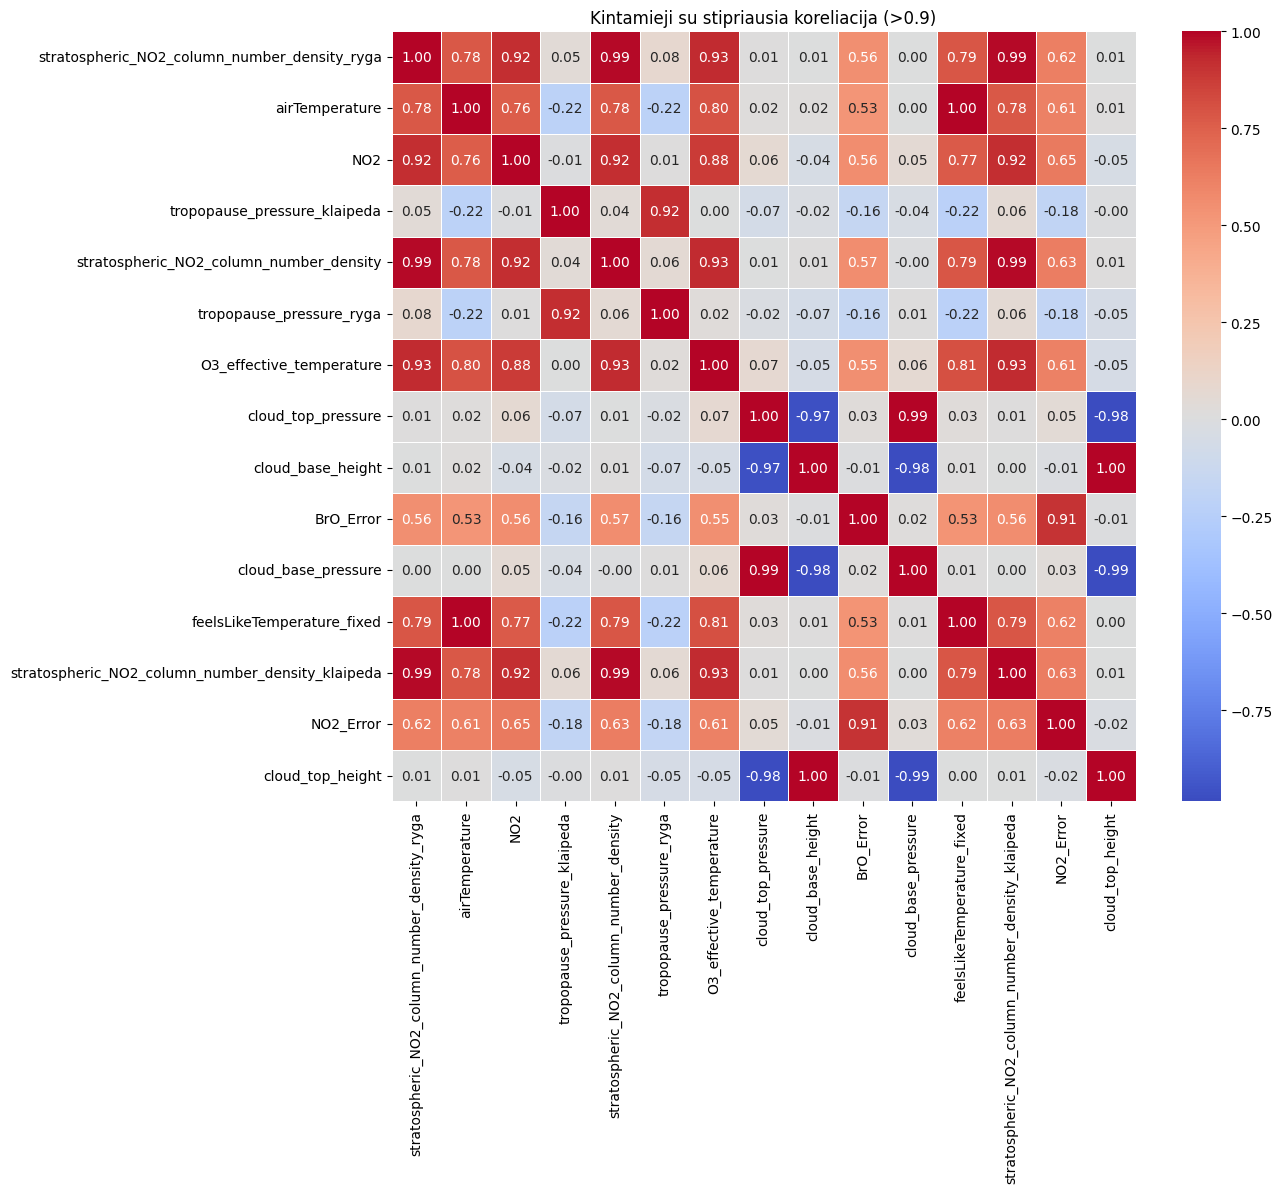

In [21]:
corr_matrix = data.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
correlations = upper.unstack().dropna().sort_values(ascending=False)

threshold = 0.9
high_corr = correlations[correlations > threshold]

print(f"--- Poros, kurių koreliacija > {threshold} ---")
if not high_corr.empty:
    for (col1, col2), val in high_corr.items():
        print(f"{col1} <---> {col2}: {val:.4f}")
else:
    print("Tokių porų nerasta.")

high_corr_cols = list(set([col for pair in high_corr.index for col in pair]))

if high_corr_cols:
    plt.figure(figsize=(12, 10))
    sns.heatmap(data[high_corr_cols].corr(), 
                annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title(f"Kintamieji su stipriausia koreliacija (>{threshold})")
    plt.show()

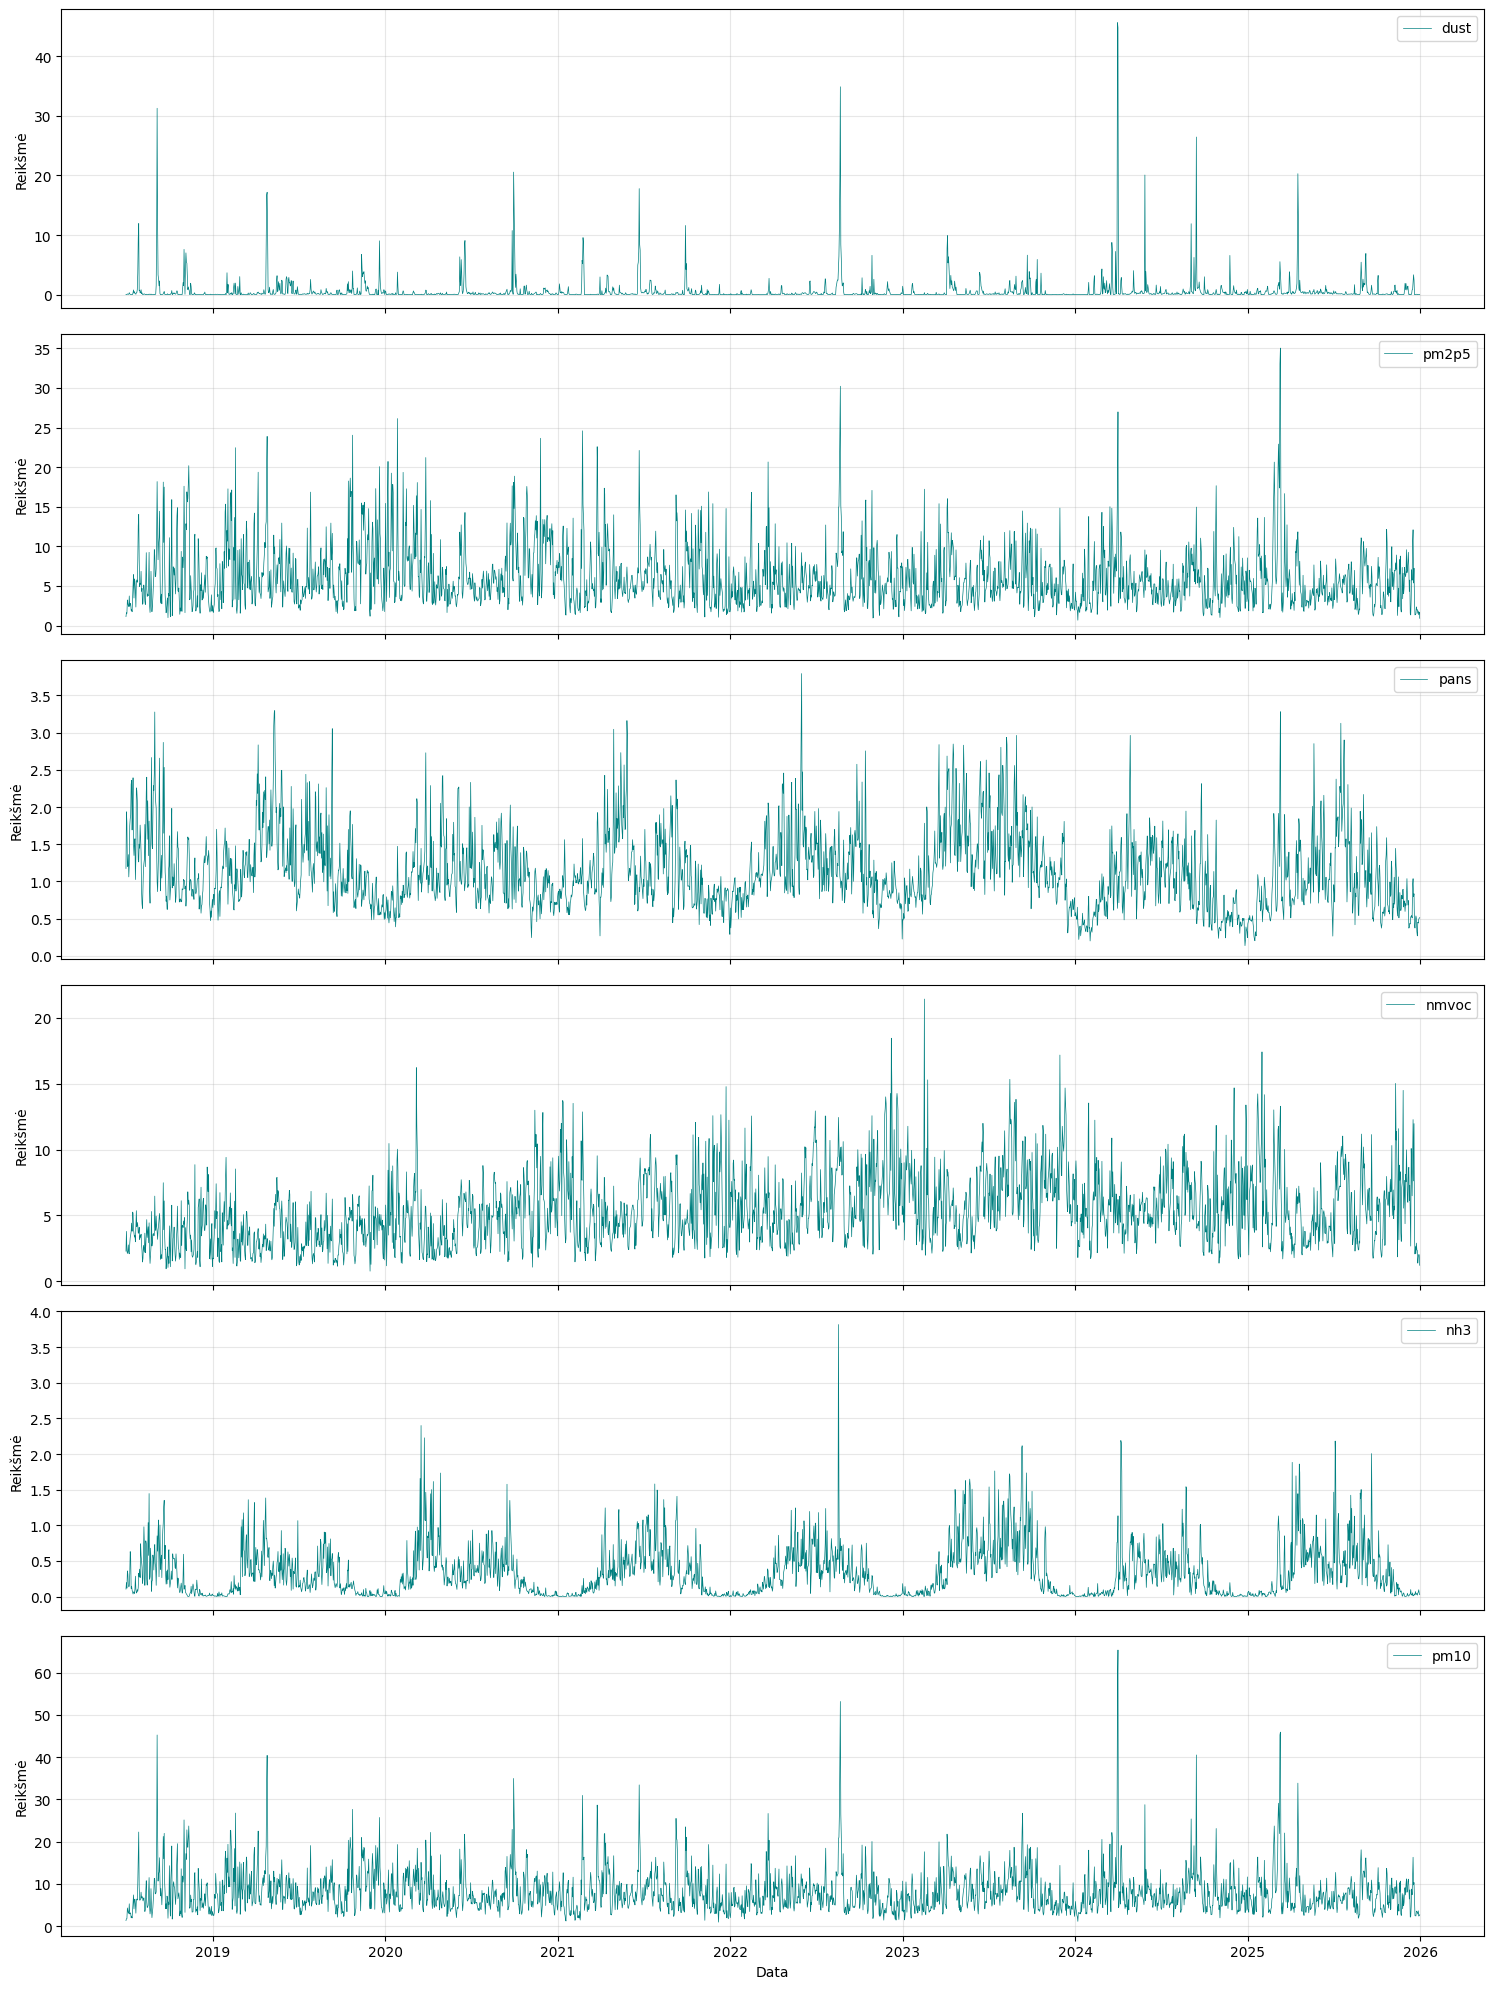

In [22]:
cols_to_show = ['dust', 'pm2p5', 'pans', 'nmvoc', 'nh3', 'pm10']

fig, axes = plt.subplots(len(cols_to_show), 1, figsize=(15, 20), sharex=True)

for i, col in enumerate(cols_to_show):
    axes[i].plot(data.index, data[col], label=col, color='teal', linewidth=0.5)
    axes[i].set_ylabel('Reikšmė')
    axes[i].legend(loc='upper right')
    axes[i].grid(True, alpha=0.3)

plt.xlabel('Data')
plt.tight_layout()
plt.show()

In [23]:
def plot_imputation_results(data_orig, data_filled, variable, method_name="Modelis", start_date=None, end_date=None):
    miss_idx = data_orig[data_orig[variable].isna()].index
    
    if start_date: start_date = pd.to_datetime(start_date)
    if end_date: end_date = pd.to_datetime(end_date)

    if start_date and end_date:
        orig_plot = data_orig.loc[start_date:end_date]
        filled_plot = data_filled.loc[start_date:end_date]
        current_miss_idx = [i for i in miss_idx if start_date <= i <= end_date]
    else:
        orig_plot = data_orig
        filled_plot = data_filled
        current_miss_idx = miss_idx

    plt.figure(figsize=(15, 6))

    plt.plot(filled_plot.index, filled_plot[variable], 
             label=f'{method_name} užpildyta seka', color='orange', linestyle='--', linewidth=1)

    plt.plot(orig_plot.index, orig_plot[variable], 
             label='Originalūs duomenys', color='blue', linewidth=1)
    
    if len(current_miss_idx) > 0:
        plt.scatter(current_miss_idx, filled_plot.loc[current_miss_idx, variable], 
                    color='red', s=15, label=f'{method_name} prognozė', zorder=5)

    plt.title(f'Kintamojo "{variable}" užpildymas ({method_name})')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

In [24]:
def simple_impute(df, target_col, window=14):
    series = df[target_col].copy()
    
    rolling_mean = series.rolling(window=window, min_periods=1, center=True).mean()
    series = series.fillna(rolling_mean)
    
    series = series.interpolate(method='linear')
    series = series.ffill().bfill()
    
    return series

# Testavimas

In [25]:
data['day_of_year'] = data.index.dayofyear

In [26]:
def block_bootstrapping_testdata(data_column, data_skip = 0.2, p_remove = 0.1, block_size = 12):
    data_array = np.array(data_column, dtype=float).copy()
    N = len(data_array)

    start_from = int(N * data_skip)

    total_to_remove = int((N - start_from) * p_remove)
    blocks_count =  total_to_remove // block_size

    for _ in range(blocks_count):
        start_idx = random.randint(start_from, max(start_from, N - block_size))
        data_array[start_idx : start_idx + block_size] = np.nan
    
    return data_array

In [27]:
random.seed(2026)
np.random.seed(2026)

df_corrupted = data.copy()
masks = {}

for col in df_corrupted.columns:
    if df_corrupted[col].dtype in [np.float64, np.int64]:
        original_col_data = df_corrupted[col].values
        corrupted_col = block_bootstrapping_testdata(original_col_data, data_skip = 0.05,  p_remove=0.1, block_size=14)
        
        masks[col] = np.isnan(corrupted_col) & ~np.isnan(original_col_data)
        df_corrupted[col] = corrupted_col

## MICE + MLP 

In [ ]:
tscv = TimeSeriesSplit(n_splits=3)

mlp = MLPRegressor(
    solver='adam',
    early_stopping=True,
    random_state=2026,
    max_iter=1000 
)

imputer = IterativeImputer(estimator=mlp, random_state=2026, verbose=0)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('imputer', imputer)
])

param_distributions = {
    'imputer__estimator__hidden_layer_sizes': [(64, 64, 32), (64, 64), (64,)],
    'imputer__estimator__alpha': [0.001, 0.01, 0.1],
    'imputer__estimator__activation': ['relu', 'tanh'],
    'imputer__estimator__learning_rate_init': [0.001, 0.0005, 0.01],
}

random_search = RandomizedSearchCV(
    pipe, 
    param_distributions=param_distributions, 
    n_iter=5, 
    cv=tscv, 
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=6202
)

random_search.fit(df_corrupted)

best_model_testing = random_search.best_estimator_
print(f"\nGeriausi rasti parametrai: {random_search.best_params_}")

In [29]:
print("Pradedamas MICE + MLP užpildymas...")

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_corrupted)

mlp_reg = MLPRegressor(
    hidden_layer_sizes=(64, 64, 32), 
    activation='tanh', 
    solver='adam',
    alpha=0.01,
    max_iter=500, 
    learning_rate_init=0.01,
    early_stopping=True,
    random_state=2026
)

imputer = IterativeImputer(
    estimator=mlp_reg, 
    max_iter=5,
    random_state=2026,
    imputation_order='descending',
    verbose=2
)

imputed_data_scaled = imputer.fit_transform(scaled_data)
imputed_data_unscaled = scaler.inverse_transform(imputed_data_scaled)
imputed_df = pd.DataFrame(
    imputed_data_unscaled, 
    columns=data.columns, 
    index=data.index
)

Pradedamas MICE + MLP užpildymas...
[IterativeImputer] Completing matrix with shape (2772, 49)
[IterativeImputer] Ending imputation round 1/5, elapsed time 47.51
[IterativeImputer] Change: 21.18153843767999, scaled tolerance: 0.023829496136048508 
[IterativeImputer] Ending imputation round 2/5, elapsed time 102.04
[IterativeImputer] Change: 11.732527936336353, scaled tolerance: 0.023829496136048508 
[IterativeImputer] Ending imputation round 3/5, elapsed time 155.42
[IterativeImputer] Change: 7.933806854631396, scaled tolerance: 0.023829496136048508 
[IterativeImputer] Ending imputation round 4/5, elapsed time 207.97
[IterativeImputer] Change: 7.469646757187551, scaled tolerance: 0.023829496136048508 
[IterativeImputer] Ending imputation round 5/5, elapsed time 259.74
[IterativeImputer] Change: 6.57583798556651, scaled tolerance: 0.023829496136048508 


c:\Users\rugil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [30]:
target_columns = ['absorbing_aerosol_index',
                  'NO2_column_number_density',
                  'stratospheric_NO2_column_number_density',
                  'NO2_slant_column_number_density',
                  'tropopause_pressure',
                  'H2O_column_number_density',
                  'BrO', 'BrO_Error',
                  'NO2', 'NO2_Error',
                  'O3', 'O3_Error']

print("\n--- TESTAVIMO REZULTATAI ---")
metrics_list = []

for col in masks.keys():
    if col in target_columns and masks[col].any():
        y_true = data.loc[masks[col], col]
        y_pred = imputed_df.loc[masks[col], col]
        
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        
        metrics_list.append({
            'Stulpelis': col,
            'R2 Score': round(r2, 4)
        })

results_table = pd.DataFrame(metrics_list)

if not results_table.empty:
    summary_data = [
        {
            'Stulpelis': 'VIDURKIS',
            'R2 Score': round(results_table['R2 Score'].mean(), 4)
        },
        {
            'Stulpelis': 'MEDIANA',
            'R2 Score': round(results_table['R2 Score'].median(), 4)
        }
    ]
    results_table = pd.concat([results_table, pd.DataFrame(summary_data)], ignore_index=True)

print(results_table.to_string(index=False))



--- TESTAVIMO REZULTATAI ---
                              Stulpelis  R2 Score
                absorbing_aerosol_index    0.6677
              NO2_column_number_density    0.4627
stratospheric_NO2_column_number_density    0.9765
        NO2_slant_column_number_density    0.5826
                    tropopause_pressure    0.7628
              H2O_column_number_density    0.7893
                                    BrO    0.1303
                              BrO_Error    0.7782
                                    NO2    0.8451
                              NO2_Error    0.8988
                                     O3    0.7768
                               O3_Error    0.5830
                               VIDURKIS    0.6878
                                MEDIANA    0.7698


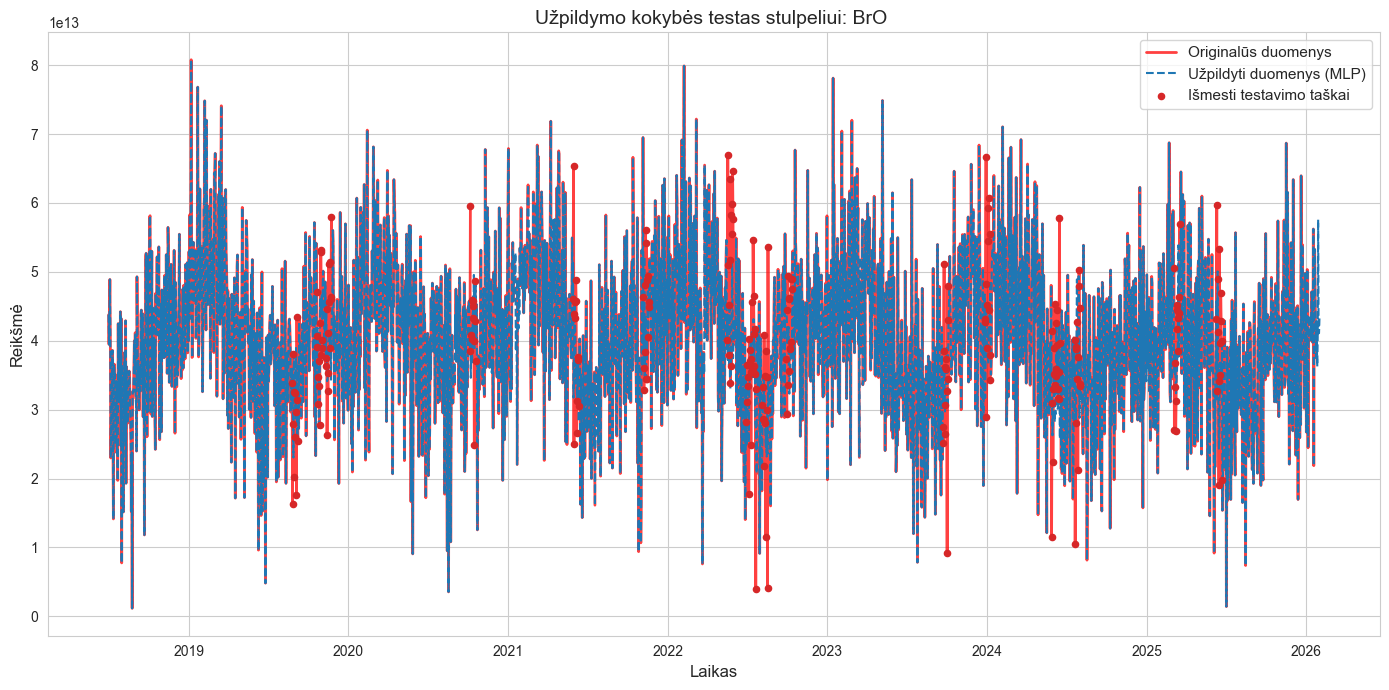

In [31]:
def plot_test_imputation(df_original, df_imputed, mask, col_name, start_date=None, end_date=None, title_suffix=""):
    plot_orig = df_original[col_name].copy()
    plot_imputed = df_imputed[col_name].copy()
    
    test_points = plot_orig.copy()
    test_points[~mask] = np.nan
    
    if start_date and end_date:
        plot_orig = plot_orig.loc[start_date:end_date]
        plot_imputed = plot_imputed.loc[start_date:end_date]
        test_points = test_points.loc[start_date:end_date]

    plt.figure(figsize=(14, 7))
    sns.set_style("whitegrid")

    plt.plot(plot_orig.index, plot_orig, label='Originalūs duomenys', color='red', alpha = 0.75, linewidth=2)

    plt.plot(plot_imputed.index, plot_imputed, label='Užpildyti duomenys (MLP)', color='#1f77b4', linestyle='--', linewidth=1.5)

    if not test_points.isna().all():
        plt.scatter(test_points.index, test_points, color='#d62728', label='Išmesti testavimo taškai', s=20, zorder=5)

    plt.title(f'Užpildymo kokybės testas stulpeliui: {col_name} {title_suffix}', fontsize=14)
    plt.ylabel('Reikšmė', fontsize=12)
    plt.xlabel('Laikas', fontsize=12)
    plt.legend(loc='best', fontsize=11)
    
    plt.tight_layout()
    plt.show()


column_to_plot = 'BrO'
mask_for_plot = masks[column_to_plot]

plot_test_imputation(data, imputed_df, mask_for_plot, column_to_plot)


## Bazinis modelis

In [32]:
simple_test_results = []
simple_imputed_df = pd.DataFrame(index=data.index)

target_columns = ['absorbing_aerosol_index',
                  'NO2_column_number_density',
                  'stratospheric_NO2_column_number_density',
                  'NO2_slant_column_number_density',
                  'tropopause_pressure',
                  'H2O_column_number_density',
                  'BrO', 'BrO_Error',
                  'NO2', 'NO2_Error',
                  'O3', 'O3_Error']

print("Pradedamas paprastas užpildymas testavimui...")

for col in data.columns:
    simple_imputed_series = simple_impute(df_corrupted, col)
    simple_imputed_df[col] = simple_imputed_series
    
    if col in target_columns and col in masks and masks[col].any():
        y_true = data.loc[masks[col], col]
        y_pred = simple_imputed_series.loc[masks[col]]
        
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        
        simple_test_results.append({
            'Stulpelis': col,
            'R2 Score': round(r2, 4)
        })

simple_results_table = pd.DataFrame(simple_test_results)


if not simple_results_table.empty:
    avg_row = pd.DataFrame([{
        'Stulpelis': 'VIDURKIS (Simple)',
        'R2 Score': round(simple_results_table['R2 Score'].mean(), 4)
    }])

    summary_data = [
        {
            'Stulpelis': 'VIDURKIS',
            'R2 Score': round(simple_results_table['R2 Score'].mean(), 4)
        },
        {
            'Stulpelis': 'MEDIANA',
            'R2 Score': round(simple_results_table['R2 Score'].median(), 4)
        }
    ]
    simple_results_table = pd.concat([simple_results_table, pd.DataFrame(summary_data)], ignore_index=True)

print("\n--- SIMPLE IMPUTE REZULTATAI ---")
print(simple_results_table.to_string(index=False))

Pradedamas paprastas užpildymas testavimui...

--- SIMPLE IMPUTE REZULTATAI ---
                              Stulpelis  R2 Score
                absorbing_aerosol_index    0.4492
              NO2_column_number_density   -0.2568
stratospheric_NO2_column_number_density    0.9337
        NO2_slant_column_number_density    0.0589
                    tropopause_pressure   -0.5315
              H2O_column_number_density    0.3419
                                    BrO   -0.2957
                              BrO_Error    0.1867
                                    NO2    0.8425
                              NO2_Error    0.3617
                                     O3    0.5675
                               O3_Error    0.7133
                               VIDURKIS    0.2810
                                MEDIANA    0.3518


## MICE + RF

In [ ]:
tscv = TimeSeriesSplit(n_splits=3)
rf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('imputer', IterativeImputer(
        estimator=RandomForestRegressor(random_state=2026, n_jobs=1),
        random_state=2026
    ))
])

param_distributions_rf = {
    'imputer__estimator__n_estimators': [50, 100, 150],
    'imputer__estimator__max_depth': [None, 15, 20, 30],
    'imputer__estimator__min_samples_split': [2, 5, 10],
    'imputer__estimator__max_features': [1.0, 'sqrt']
}

random_search_rf = RandomizedSearchCV(
    rf_pipe, 
    param_distributions=param_distributions_rf, 
    n_iter=5,
    cv=tscv, 
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=2026,
    verbose=1
)

random_search_rf.fit(df_corrupted)

best_rf_model = random_search_rf.best_estimator_
print(f"\nGeriausi RF parametrai: {random_search_rf.best_params_}")

imputed_data_scaled = best_rf_model.transform(df_corrupted)
scaler_from_pipe = best_rf_model.named_steps['scaler']
imputed_data_unscaled = scaler_from_pipe.inverse_transform(imputed_data_scaled)

imputed_df_rf = pd.DataFrame(imputed_data_unscaled, columns=df_corrupted.columns, index=df_corrupted.index)

In [34]:
print("Pradedamas MICE + Random Forest užpildymas...")

scaler_rf = StandardScaler()
rf_data_scaled = scaler_rf.fit_transform(df_corrupted)

rf_reg = RandomForestRegressor(
    n_estimators=50,
    max_depth=30,
    n_jobs=-1, 
    random_state=2026
)

imputer_rf = IterativeImputer(
    estimator=rf_reg, 
    max_iter=8, 
    initial_strategy='median',
    imputation_order='ascending',
    random_state=2026,
    verbose=2
)

imputed_data_rf = imputer_rf.fit_transform(rf_data_scaled)

imputed_data_rf = scaler_rf.inverse_transform(imputed_data_rf)
imputed_df_rf = pd.DataFrame(
    imputed_data_rf, 
    columns=data.columns, 
    index=data.index
)


Pradedamas MICE + Random Forest užpildymas...
[IterativeImputer] Completing matrix with shape (2772, 49)
[IterativeImputer] Ending imputation round 1/8, elapsed time 36.26
[IterativeImputer] Change: 21.344342117534765, scaled tolerance: 0.023829496136048508 
[IterativeImputer] Ending imputation round 2/8, elapsed time 72.71
[IterativeImputer] Change: 7.906393790592814, scaled tolerance: 0.023829496136048508 
[IterativeImputer] Ending imputation round 3/8, elapsed time 109.55
[IterativeImputer] Change: 5.449220204650372, scaled tolerance: 0.023829496136048508 
[IterativeImputer] Ending imputation round 4/8, elapsed time 146.51
[IterativeImputer] Change: 5.162552082865119, scaled tolerance: 0.023829496136048508 
[IterativeImputer] Ending imputation round 5/8, elapsed time 184.66
[IterativeImputer] Change: 3.86205017413877, scaled tolerance: 0.023829496136048508 
[IterativeImputer] Ending imputation round 6/8, elapsed time 223.58
[IterativeImputer] Change: 5.07782933042988, scaled toleran

c:\Users\rugil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [35]:
rf_metrics_list = []

target_columns = ['absorbing_aerosol_index',
                  'NO2_column_number_density',
                  'stratospheric_NO2_column_number_density',
                  'NO2_slant_column_number_density',
                  'tropopause_pressure',
                  'H2O_column_number_density',
                  'BrO', 'BrO_Error',
                  'NO2', 'NO2_Error',
                  'O3', 'O3_Error']

for col in masks.keys():
    if col in target_columns and masks[col].any():
        y_true = data.loc[masks[col], col]
        y_pred = imputed_df_rf.loc[masks[col], col]
        
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        
        rf_metrics_list.append({
            'Stulpelis': col,
            'R2 Score': round(r2, 4)
        })

results_table_rf = pd.DataFrame(rf_metrics_list)
if not results_table_rf.empty:
    summary_data = [
        {
            'Stulpelis': 'VIDURKIS',
            'R2 Score': round(results_table_rf['R2 Score'].mean(), 4)
        },
        {
            'Stulpelis': 'MEDIANA',
            'R2 Score': round(results_table_rf['R2 Score'].median(), 4)
        }
    ]
    results_table_rf = pd.concat([results_table_rf, pd.DataFrame(summary_data)], ignore_index=True)

print("\n--- RANDOM FOREST REZULTATAI ---")
print(results_table_rf.to_string(index=False))


--- RANDOM FOREST REZULTATAI ---
                              Stulpelis  R2 Score
                absorbing_aerosol_index    0.6843
              NO2_column_number_density    0.3389
stratospheric_NO2_column_number_density    0.9841
        NO2_slant_column_number_density    0.6072
                    tropopause_pressure    0.7719
              H2O_column_number_density    0.8229
                                    BrO    0.2068
                              BrO_Error    0.7959
                                    NO2    0.8908
                              NO2_Error    0.8818
                                     O3    0.7820
                               O3_Error    0.7160
                               VIDURKIS    0.7069
                                MEDIANA    0.7770


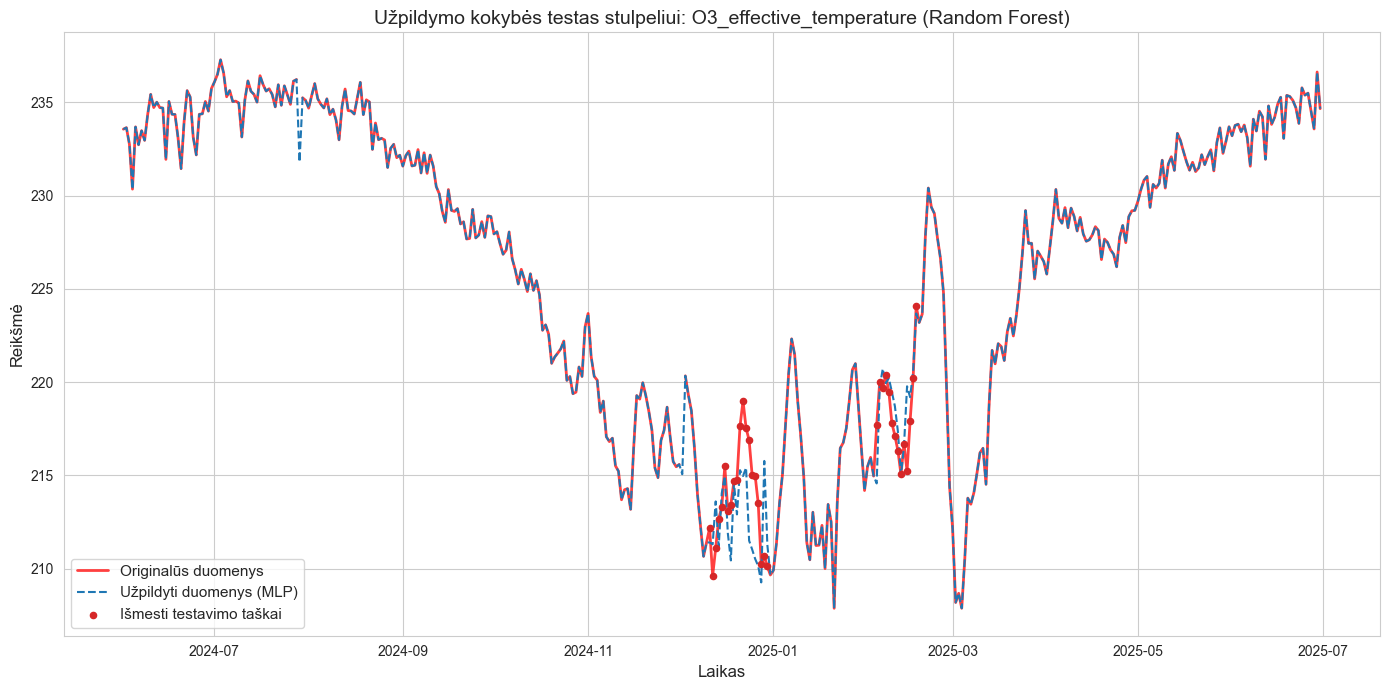

In [36]:
plot_test_imputation(
    df_original=data, 
    df_imputed=imputed_df_rf, 
    mask=masks['O3_effective_temperature'], 
    col_name='O3_effective_temperature', 
    start_date='2024-06-01', 
    end_date='2025-06-30',
    title_suffix="(Random Forest)"
)

## Klasikinis MICE

In [39]:
print("Pradedamas numatytasis MICE užpildymas...")

scaler = StandardScaler()
scaled_corrupted = scaler.fit_transform(df_corrupted)

default_imputer = IterativeImputer(
    max_iter=8, 
    random_state=2026, 
    verbose=0
)

imputed_data_raw = default_imputer.fit_transform(scaled_corrupted)

imputed_df_default = pd.DataFrame(
    scaler.inverse_transform(imputed_data_raw), 
    columns=data.columns, 
    index=data.index
)

Pradedamas numatytasis MICE užpildymas...


c:\Users\rugil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [40]:
metrics_list = []

for col in masks.keys():
    if col in target_columns and masks[col].any():
        y_true = data.loc[masks[col], col]
        y_pred = imputed_df_default.loc[masks[col], col]
        
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        
        metrics_list.append({
            'Stulpelis': col,
            'R2 Score': round(r2, 4)
        })

results_table = pd.DataFrame(metrics_list)

if not results_table.empty:
    summary_data = [
        {
            'Stulpelis': 'VIDURKIS',
            'R2 Score': round(results_table['R2 Score'].mean(), 4)
        },
        {
            'Stulpelis': 'MEDIANA',
            'R2 Score': round(results_table['R2 Score'].median(), 4)
        }
    ]

    results_table = pd.concat([results_table, pd.DataFrame(summary_data)], ignore_index=True)

print("\n--- NUMATYTOJO MICE REZULTATAI ---")
print(results_table.to_string(index=False))


--- NUMATYTOJO MICE REZULTATAI ---
                              Stulpelis  R2 Score
                absorbing_aerosol_index    0.6931
              NO2_column_number_density    0.6480
stratospheric_NO2_column_number_density    0.9880
        NO2_slant_column_number_density    0.6495
                    tropopause_pressure    0.8165
              H2O_column_number_density    0.8134
                                    BrO    0.2420
                              BrO_Error    0.7759
                                    NO2    0.8702
                              NO2_Error    0.7955
                                     O3    0.7431
                               O3_Error    0.4587
                               VIDURKIS    0.7078
                                MEDIANA    0.7595


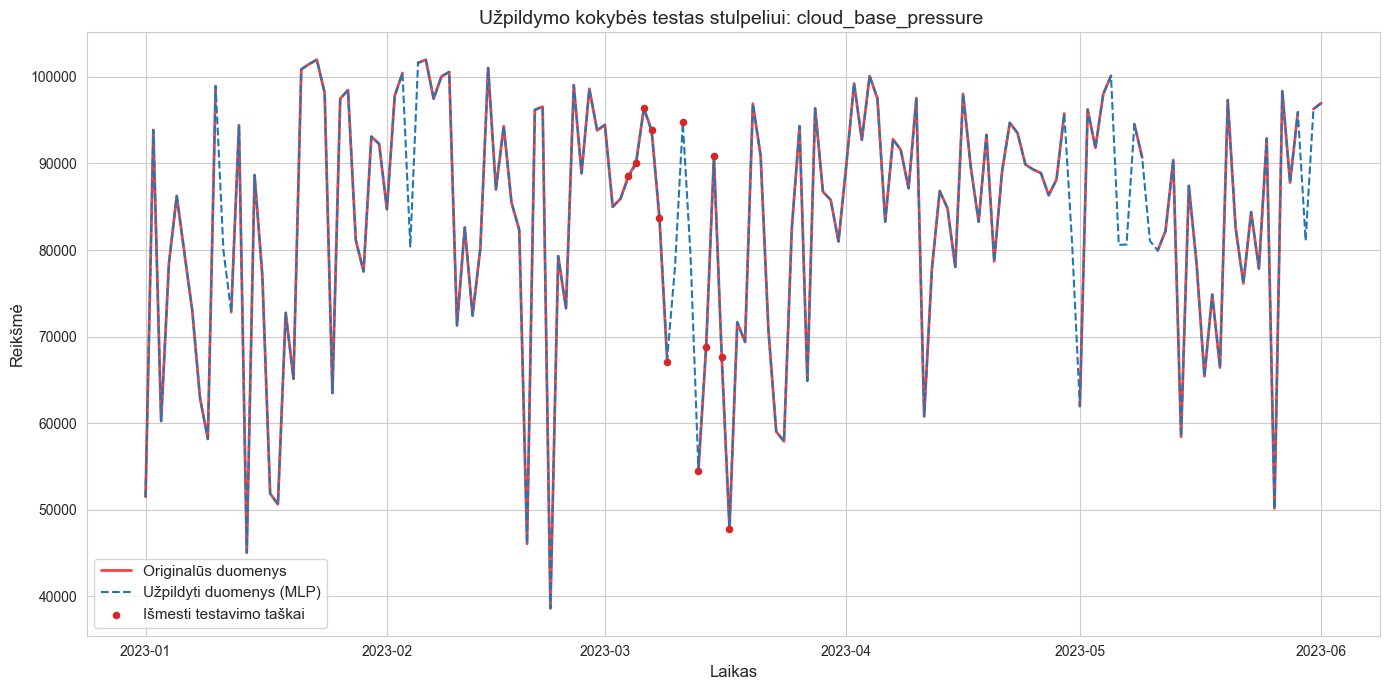

In [41]:
plot_test_imputation(data, 
                     imputed_df_default, 
                     masks['cloud_base_pressure'], 
                     'cloud_base_pressure',
                     start_date='2023-01-01',
                     end_date='2023-06-01')

## Palyginimas

In [ ]:
width_inch = 17 / 2.54
height_inch = width_inch * 0.5

def plot_all_methods_comparison(df_original, methods_dict, mask, col_name, start_date=None, end_date=None):
    if isinstance(mask, np.ndarray):
        mask = pd.Series(mask, index=df_original.index)

    plt.figure(figsize=(width_inch, height_inch))

    if start_date and end_date:
        start_ts = pd.to_datetime(start_date)
        end_ts = pd.to_datetime(end_date)
        
        mask_time = (df_original.index >= start_ts) & (df_original.index <= end_ts)
        plot_df_orig = df_original.loc[mask_time]
        plot_mask = mask.loc[mask_time]
    else:
        plot_df_orig = df_original
        plot_mask = mask

    is_mask = plot_mask.values
    diff = np.diff(is_mask.astype(int), prepend=0, append=0)
    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0]

    for i in range(len(starts)):
        start_idx = plot_df_orig.index[starts[i]]
        end_idx = plot_df_orig.index[min(ends[i], len(plot_df_orig)-1)]
        
        plt.axvspan(start_idx, end_idx, color='gray', alpha=0.2, label='Dirbtinis blokas' if i == 0 else "")

    plt.plot(plot_df_orig.index, plot_df_orig[col_name], 
             label='Originalūs duomenys', color='red', linewidth=0.7)


    test_points = plot_df_orig[col_name].copy()
    test_points[~plot_mask] = np.nan
    
    if not test_points.isna().all():
        plt.scatter(test_points.index, test_points, color='red', 
                    label='Išmesti taškai', s=3)

    colors = ['#ff7f0e', "#1ca0ff", '#2ca02c', "#e02ef4"]
    for (name, df_imp), color in zip(methods_dict.items(), colors):
        plot_data = df_imp.loc[plot_df_orig.index, col_name]
        plt.plot(plot_df_orig.index, plot_data, label=f'{name}', 
                 color=color, linestyle='--', linewidth=0.7)

    # plt.suptitle(f'Metodų palyginimas {col_name}', fontsize=11)
    plt.ylabel('Reikšmė', fontsize=8)
    plt.xlabel('Laikas', fontsize=8)
    plt.tick_params(axis='both', which='major', labelsize=8)
    plt.legend(fontsize=6, labelspacing=0.4, handletextpad=0.6)
    plt.tight_layout()
    plt.grid(True, alpha=0.3)


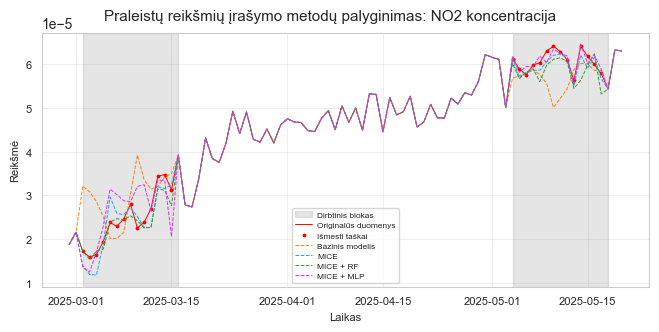

In [46]:
all_methods = {
    'Bazinis modelis': simple_imputed_df,
    'MICE': imputed_df_default,
    'MICE + RF': imputed_df_rf,
    'MICE + MLP': imputed_df,
}

column_to_plot = 'stratospheric_NO2_column_number_density' 

plot_all_methods_comparison(
    data, 
    all_methods, 
    masks[column_to_plot], 
    column_to_plot, 
    start_date='2025-02-28',
    end_date='2025-05-20'
)

plt.suptitle('Praleistų reikšmių įrašymo metodų palyginimas: NO2 koncentracija', fontsize=11)
plt.savefig('metodu_palyginimas.png', dpi=300, bbox_inches='tight')
plt.show()



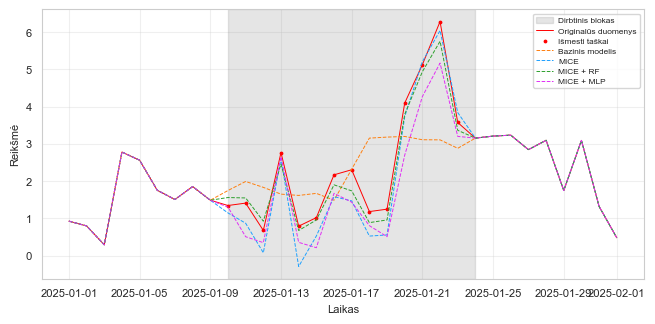

In [45]:
column_to_plot = 'sia' 

plot_all_methods_comparison(
    data, 
    all_methods, 
    masks[column_to_plot], 
    column_to_plot, 
    start_date='2025-01-01',
    end_date='2025-02-01'
)

# Galutinis įrašymas

In [47]:
scaler_rf = StandardScaler()
rf_data_scaled = scaler_rf.fit_transform(data)

rf_reg = RandomForestRegressor(
    n_estimators=50,
    max_depth=30, 
    n_jobs=-1,
    random_state=2026
)

imputer_rf = IterativeImputer(
    estimator=rf_reg, 
    max_iter=8,
    initial_strategy='median',
    imputation_order='ascending',
    random_state=2026,
    verbose=2
)

imputed_data= imputer_rf.fit_transform(rf_data_scaled)

imputed_data_final = scaler_rf.inverse_transform(imputed_data)
filled_data = pd.DataFrame(
    imputed_data_final, 
    columns=df_corrupted.columns, 
    index=df_corrupted.index
)

[IterativeImputer] Completing matrix with shape (2772, 49)
[IterativeImputer] Ending imputation round 1/8, elapsed time 38.40
[IterativeImputer] Change: 15.160760241127448, scaled tolerance: 0.024120095655993525 
[IterativeImputer] Ending imputation round 2/8, elapsed time 76.79
[IterativeImputer] Change: 6.863057331408043, scaled tolerance: 0.024120095655993525 
[IterativeImputer] Ending imputation round 3/8, elapsed time 115.73
[IterativeImputer] Change: 4.310511828233089, scaled tolerance: 0.024120095655993525 
[IterativeImputer] Ending imputation round 4/8, elapsed time 154.89
[IterativeImputer] Change: 4.491236802028817, scaled tolerance: 0.024120095655993525 
[IterativeImputer] Ending imputation round 5/8, elapsed time 196.78
[IterativeImputer] Change: 4.308337918234528, scaled tolerance: 0.024120095655993525 
[IterativeImputer] Ending imputation round 6/8, elapsed time 239.32
[IterativeImputer] Change: 4.225920820331788, scaled tolerance: 0.024120095655993525 
[IterativeImputer]

c:\Users\rugil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


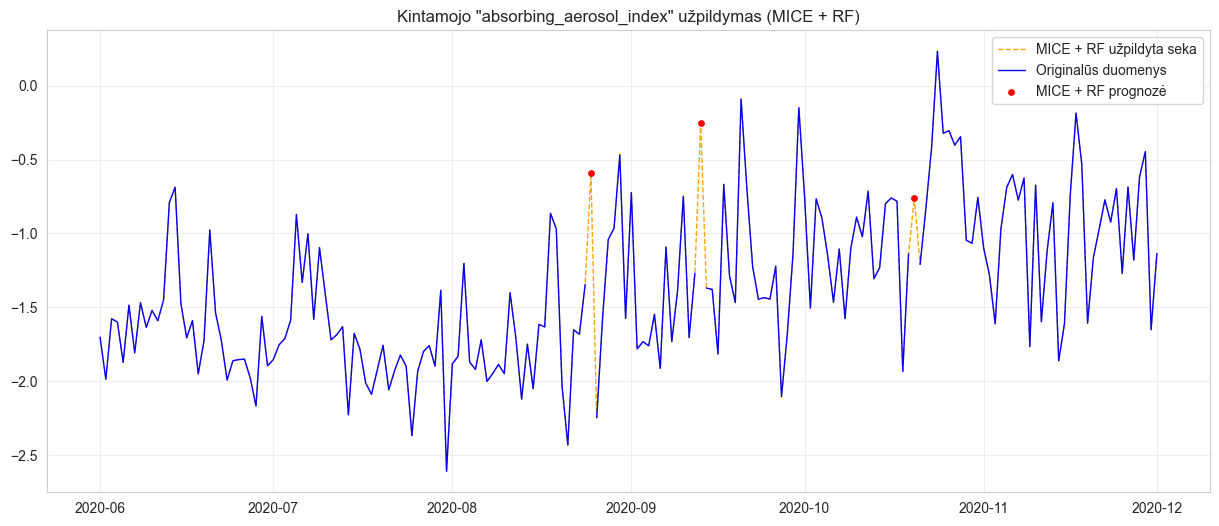

In [51]:
plot_imputation_results(data, 
                        filled_data, 
                        'absorbing_aerosol_index' , 
                        method_name="MICE + RF", 
                        start_date='2020-06-01', 
                        end_date='2020-12-01'
                        )

Galutinis rinkinys

In [52]:
data_to_forecast = data[['dust', 'sia', 'pm2p5', 'pans', 'nmvoc', 'nh3', 'pm10']]


In [53]:
data_for_forecast = filled_data[[
    # 'seaLevelPressure',
    # 'relativeHumidity',
    # 'xgb_precipitation',
    # 'xgb_cloudCover',
    # 'feelsLikeTemperature_fixed',
    # 'windSpeed_fixed',
    # 'windGust_fixed',
    # 'windDirection_fixed',
    'absorbing_aerosol_index', 
    'NO2_column_number_density', 
    'stratospheric_NO2_column_number_density',
    'NO2_slant_column_number_density',
    'tropopause_pressure',
    'H2O_column_number_density',
    'BrO',
    'NO2',
    'O3'
    ]]

In [54]:
data_for_forecasting = data_for_forecast.join(meteo_data)
data_for_forecasting = data_for_forecasting.join(data_to_forecast)
data_for_forecasting

,absorbing_aerosol_index,NO2_column_number_density,stratospheric_NO2_column_number_density,NO2_slant_column_number_density,tropopause_pressure,H2O_column_number_density,BrO,NO2,O3,airTemperature,...,windSpeed_fixed,windGust_fixed,windDirection_fixed,dust,sia,pm2p5,pans,nmvoc,nh3,pm10
observationTime,,,,,,,,,,,,,,,,,,,,,
2018-07-01,-1.016247,0.000075,0.000062,0.000193,22057.926,1136.782022,4.376100e+13,3.627587e+15,332.670633,11.295833,...,3.762500,13.9,356.0,0.011452,0.412340,1.127883,1.174715,2.292138,0.105974,1.338105
2018-07-02,-0.800622,0.000079,0.000066,0.000196,22067.760,1229.531736,3.946727e+13,3.795988e+15,339.679410,10.866667,...,2.516667,7.0,327.0,0.011515,0.946260,1.609913,1.935448,3.792921,0.198428,1.752331
2018-07-03,-0.621235,0.000077,0.000062,0.000203,19219.670,1314.680602,4.465846e+13,4.526218e+15,361.533268,13.387500,...,2.537500,8.3,271.0,0.044194,0.676988,1.534471,1.787800,2.332084,0.118859,1.789138
2018-07-04,-0.659180,0.000072,0.000065,0.000146,19219.450,1824.427700,4.888972e+13,4.149200e+15,343.308865,13.591667,...,2.358333,8.7,288.0,0.128728,0.833161,3.229130,1.201320,2.113538,0.361157,4.323638
2018-07-05,-1.010234,0.000079,0.000067,0.000198,19218.373,1257.064200,4.093649e+13,3.959891e+15,311.500626,16.291667,...,1.283333,6.1,293.0,0.097650,0.737482,2.768797,1.206750,2.267631,0.316533,3.718909
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-27,-0.386410,0.000079,0.000036,0.000211,22040.164,520.054200,4.547000e+13,1.580704e+15,395.745543,-2.200000,...,1.600000,4.6,70.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-28,-0.301222,0.000113,0.000032,0.000223,19222.887,133.845490,5.302146e+13,2.127232e+15,450.404488,-5.012500,...,2.495833,7.5,33.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-29,-0.406181,0.000060,0.000033,0.000207,19240.344,101.578510,4.515460e+13,1.917223e+15,353.699717,-9.604167,...,2.812500,8.3,35.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Prognozavimas

## Gradient Boosting Regressor

In [55]:
data_for_forecasting['day_of_year'] = data_for_forecasting.index.dayofyear
data_for_forecasting['month'] = data_for_forecasting.index.month

### PM10

In [56]:
forecasting_pm10 = data_for_forecasting.copy()

test_cutoff = '2025-12-01'
others = ['dust', 'sia', 'pm2p5', 'pans', 'nmvoc', 'nh3', 'pm10']
target = 'pm10'


for col in others:
    forecasting_pm10[f'{col}_lag_31'] = forecasting_pm10[col].shift(31)

cols_to_remove = [c for c in others if c != target]
forecasting_pm10.drop(columns=cols_to_remove, inplace=True)
forecasting_pm10.dropna(inplace=True)

train_data_pm10 = forecasting_pm10[forecasting_pm10.index < test_cutoff]
test_data_pm10 = forecasting_pm10[forecasting_pm10.index >= test_cutoff]

X_train_pm10 = train_data_pm10.drop(columns=[target])
y_train_pm10 = train_data_pm10[target]

X_test_pm10 = test_data_pm10.drop(columns=[target])
y_test_pm10 = test_data_pm10[target]

In [57]:
tscv = TimeSeriesSplit(n_splits=3)

param_dist = {
    'n_estimators': [100, 300, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 5, 10],
    'subsample': [0.7, 0.8, 0.9, 1.0]
}

gbr = GradientBoostingRegressor(random_state=2026)

random_search = RandomizedSearchCV(
    estimator=gbr, 
    param_distributions=param_dist, 
    n_iter=20, 
    cv=tscv , 
    scoring='r2', 
    verbose=1, 
    n_jobs=-1,
    random_state=2026
)

random_search.fit(X_train_pm10, y_train_pm10)

print(f"Geriausi parametrai: {random_search.best_params_}")


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Geriausi parametrai: {'subsample': 0.8, 'n_estimators': 500, 'min_samples_split': 2, 'max_depth': 4, 'learning_rate': 0.01}


In [58]:
best_model_pm10 = random_search.best_estimator_
y_pred_pm10_gbr = best_model_pm10.predict(X_test_pm10)

r2_pm10 = r2_score(y_test_pm10, y_pred_pm10_gbr)
rmse_pm10 = np.sqrt(mean_squared_error(y_test_pm10, y_pred_pm10_gbr))

print(f"--- Modelio rezultatai---")
print(f"R2 koeficientas: {r2_pm10:.4f}")
print(f"RMSE paklaida: {rmse_pm10:.4f}")

--- Modelio rezultatai---
R2 koeficientas: 0.6543
RMSE paklaida: 2.1930


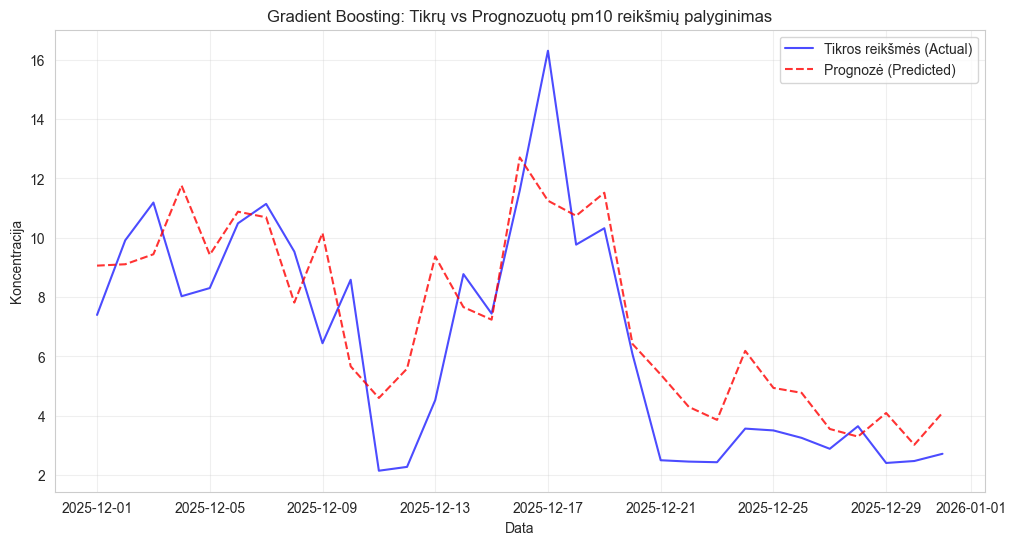

In [60]:
plt.figure(figsize=(12, 6))
plt.plot(test_data_pm10.index, y_test_pm10.values, label='Tikros reikšmės (Actual)', color='blue', alpha=0.7)
plt.plot(test_data_pm10.index, y_pred_pm10_gbr, label='Prognozė (Predicted)', color='red', linestyle='--', alpha=0.8)

plt.title(f'Gradient Boosting: Tikrų vs Prognozuotų {target} reikšmių palyginimas')
plt.xlabel('Data')
plt.ylabel('Koncentracija')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### NH3

In [61]:
forecasting_nh3 = data_for_forecasting.copy()

test_cutoff = '2025-12-01'
others = ['dust', 'sia', 'pm2p5', 'pans', 'nmvoc', 'nh3', 'pm10']
target = 'nh3'

for col in others:
    forecasting_nh3[f'{col}_lag_31'] = forecasting_nh3[col].shift(31)
    forecasting_nh3[f'{col}_lag_38'] = forecasting_nh3[col].shift(38)
    forecasting_nh3[f'{col}_roll_7_lag_31'] = forecasting_nh3[col].shift(31).rolling(window=7).mean()

forecasting_nh3.drop(columns=others, inplace=True, errors='ignore') 
forecasting_nh3[target] = data_for_forecasting[target] 
forecasting_nh3.dropna(inplace=True)

train_data_nh3 = forecasting_nh3[forecasting_nh3.index < test_cutoff]
test_data_nh3 = forecasting_nh3[forecasting_nh3.index >= test_cutoff]

X_train_nh3 = train_data_nh3.drop(columns=[target])
y_train_nh3 = train_data_nh3[target]

X_test_nh3 = test_data_nh3.drop(columns=[target])
y_test_nh3 = test_data_nh3[target]


In [62]:
param_dist = {
    'n_estimators': [100, 300, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 5, 10],
    'subsample': [0.7, 0.8, 0.9, 1.0]
}

gbr = GradientBoostingRegressor(random_state=2026)

random_search = RandomizedSearchCV(
    estimator=gbr, 
    param_distributions=param_dist, 
    n_iter=20, 
    cv=tscv , 
    scoring='r2', 
    verbose=1, 
    n_jobs=-1,
    random_state=2026
)

random_search.fit(X_train_nh3, y_train_nh3)

print(f"Geriausi parametrai: {random_search.best_params_}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Geriausi parametrai: {'subsample': 1.0, 'n_estimators': 300, 'min_samples_split': 5, 'max_depth': 4, 'learning_rate': 0.05}


In [63]:
best_model_nh3 = random_search.best_estimator_
y_pred_nh3_gbr = best_model_nh3.predict(X_test_nh3)

r2_nh3 = r2_score(y_test_nh3, y_pred_nh3_gbr)
rmse_nh3 = np.sqrt(mean_squared_error(y_test_nh3, y_pred_nh3_gbr))

print(f"--- Modelio rezultatai---")
print(f"R2 koeficientas: {r2_nh3:.4f}")
print(f"RMSE paklaida: {rmse_nh3:.4f}")

--- Modelio rezultatai---
R2 koeficientas: -1.4546
RMSE paklaida: 0.0381


### NMVOC

In [64]:
forecasting_nmvoc = data_for_forecasting.copy()

test_cutoff = '2025-12-01'
others = ['dust', 'sia', 'pm2p5', 'pans', 'nmvoc', 'nh3', 'pm10']
target = 'nmvoc'

for col in others:
    forecasting_nmvoc[f'{col}_lag_31'] = forecasting_nmvoc[col].shift(31)
    forecasting_nmvoc[f'{col}_lag_38'] = forecasting_nmvoc[col].shift(38)
    forecasting_nmvoc[f'{col}_roll_7_lag_31'] = (
        forecasting_nmvoc[col]
        .shift(31)
        .rolling(window=7)
        .mean()
    )

cols_to_remove = [c for c in others if c != target]
forecasting_nmvoc.drop(columns=cols_to_remove, inplace=True)
forecasting_nmvoc.dropna(inplace=True)

train_data_nmvoc = forecasting_nmvoc[forecasting_nmvoc.index < test_cutoff]
test_data_nmvoc = forecasting_nmvoc[forecasting_nmvoc.index >= test_cutoff]

X_train_nmvoc = train_data_nmvoc.drop(columns=[target])
y_train_nmvoc = train_data_nmvoc[target]

X_test_nmvoc = test_data_nmvoc.drop(columns=[target])
y_test_nmvoc = test_data_nmvoc[target]

In [65]:
param_dist = {
    'n_estimators': [100, 300, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 5, 10],
    'subsample': [0.7, 0.8, 0.9, 1.0]
}

gbr = GradientBoostingRegressor(random_state=2026)

random_search = RandomizedSearchCV(
    estimator=gbr, 
    param_distributions=param_dist, 
    n_iter=20, 
    cv=tscv , 
    scoring='r2', 
    verbose=1, 
    n_jobs=-1,
    random_state=2026
)

random_search.fit(X_train_nmvoc, y_train_nmvoc)
print(f"Geriausi parametrai: {random_search.best_params_}")

best_model_nmvoc = random_search.best_estimator_
y_pred_nmvoc_gbr = best_model_nmvoc.predict(X_test_nmvoc)

r2_nmvoc = r2_score(y_test_nmvoc, y_pred_nmvoc_gbr)
rmse_nmvoc = np.sqrt(mean_squared_error(y_test_nmvoc, y_pred_nmvoc_gbr))

print(f"--- Modelio rezultatai---")
print(f"R2 koeficientas: {r2_nmvoc:.4f}")
print(f"RMSE paklaida: {rmse_nmvoc:.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Geriausi parametrai: {'subsample': 0.7, 'n_estimators': 1000, 'min_samples_split': 2, 'max_depth': 5, 'learning_rate': 0.01}
--- Modelio rezultatai---
R2 koeficientas: 0.4707
RMSE paklaida: 2.4070


### PANS

In [66]:
forecasting_pans = data_for_forecasting.copy()

test_cutoff = '2025-12-01'
others = ['dust', 'sia', 'pm2p5', 'pans', 'nmvoc', 'nh3', 'pm10']
target = 'pans'

for col in others:
    forecasting_pans[f'{col}_lag_31'] = forecasting_pans[col].shift(31)

forecasting_pans.dropna(inplace=True)

train_data_pans = forecasting_pans[forecasting_pans.index < test_cutoff]
test_data_pans = forecasting_pans[(forecasting_pans.index >= test_cutoff) &
                                 (forecasting_pans[target].notna())]

cols_to_drop = [target] + others

X_train_pans = train_data_pans.drop(columns=cols_to_drop)
y_train_pans = train_data_pans[target]

X_test_pans = test_data_pans.drop(columns=cols_to_drop)
y_test_pans = test_data_pans[target]

In [67]:
tscv = TimeSeriesSplit(n_splits=3)

param_dist = {
    'n_estimators': [100, 300, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 5, 10],
    'subsample': [0.7, 0.8, 0.9, 1.0]
}

gbr = GradientBoostingRegressor(random_state=2026)

random_search = RandomizedSearchCV(
    estimator=gbr, 
    param_distributions=param_dist, 
    n_iter=20, 
    cv=tscv , 
    scoring='r2', 
    verbose=1, 
    n_jobs=-1,
    random_state=2026
)

random_search.fit(X_train_pans, y_train_pans)
print(f"Geriausi parametrai: {random_search.best_params_}")

best_model_pans = random_search.best_estimator_
y_pred_pans_gbr = best_model_pans.predict(X_test_pans)

r2_pans= r2_score(y_test_pans, y_pred_pans_gbr)
rmse_pans = np.sqrt(mean_squared_error(y_test_pans, y_pred_pans_gbr))

print(f"--- Modelio rezultatai---")
print(f"R2 koeficientas: {r2_pans:.4f}")
print(f"RMSE paklaida: {rmse_pans:.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Geriausi parametrai: {'subsample': 0.8, 'n_estimators': 500, 'min_samples_split': 2, 'max_depth': 4, 'learning_rate': 0.01}
--- Modelio rezultatai---
R2 koeficientas: -0.3553
RMSE paklaida: 0.2359


### pm2p5

In [68]:
forecasting_pm2p5 = data_for_forecasting.copy()

test_cutoff = '2025-12-01'
others = ['dust', 'sia', 'pm2p5', 'pans', 'nmvoc', 'nh3', 'pm10']
target = 'pm2p5'

for col in others:
    forecasting_pm2p5[f'{col}_lag_31'] = forecasting_pm2p5[col].shift(31)
    forecasting_pm2p5[f'{col}_lag_38'] = forecasting_pm2p5[col].shift(38)
    forecasting_pm2p5[f'{col}_roll_7_lag_31'] = (
        forecasting_pm2p5[col]
        .shift(31)
        .rolling(window=7)
        .mean()
    )

cols_to_remove = [c for c in others if c != target]
forecasting_pm2p5.drop(columns=cols_to_remove, inplace=True)
forecasting_pm2p5.dropna(inplace=True)

train_data_pm2p5 = forecasting_pm2p5[forecasting_pm2p5.index < test_cutoff]
test_data_pm2p5 = forecasting_pm2p5[forecasting_pm2p5.index >= test_cutoff]


X_train_pm2p5 = train_data_pm2p5.drop(columns=[target])
y_train_pm2p5 = train_data_pm2p5[target]

X_test_pm2p5 = test_data_pm2p5.drop(columns=[target])
y_test_pm2p5 = test_data_pm2p5[target]

In [69]:
param_dist = {
    'n_estimators': [100, 300, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 5, 10],
    'subsample': [0.7, 0.8, 0.9, 1.0]
}

gbr = GradientBoostingRegressor(random_state=2026)

random_search = RandomizedSearchCV(
    estimator=gbr, 
    param_distributions=param_dist, 
    n_iter=20, 
    cv=tscv , 
    scoring='r2', 
    verbose=1, 
    n_jobs=-1,
    random_state=2026
)

random_search.fit(X_train_pm2p5, y_train_pm2p5)
print(f"Geriausi parametrai: {random_search.best_params_}")

best_model_pm2p5 = random_search.best_estimator_
y_pred_pm2p5_gbr = best_model_pm2p5.predict(X_test_pm2p5)

r2_pm2p5 = r2_score(y_test_pm2p5, y_pred_pm2p5_gbr)
rmse_pm2p5 = np.sqrt(mean_squared_error(y_test_pm2p5, y_pred_pm2p5_gbr))

print(f"--- Modelio rezultatai---")
print(f"R2 koeficientas: {r2_pm2p5:.4f}")
print(f"RMSE paklaida: {rmse_pm2p5:.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Geriausi parametrai: {'subsample': 1.0, 'n_estimators': 100, 'min_samples_split': 10, 'max_depth': 3, 'learning_rate': 0.05}
--- Modelio rezultatai---
R2 koeficientas: 0.4934
RMSE paklaida: 2.2604


### SIA

In [70]:
forecasting_sia = data_for_forecasting.copy()

test_cutoff = '2025-12-01'
others = ['dust', 'sia', 'pm2p5', 'pans', 'nmvoc', 'nh3', 'pm10']
target = 'sia'

for col in others:
    forecasting_sia[f'{col}_lag_31'] = forecasting_sia[col].shift(31)
    forecasting_sia[f'{col}_lag_38'] = forecasting_sia[col].shift(38)
    forecasting_sia[f'{col}_roll_7_lag_31'] = (
        forecasting_sia[col]
        .shift(31)
        .rolling(window=7)
        .mean()
    )

cols_to_remove = [c for c in others if c != target]
forecasting_sia.drop(columns=cols_to_remove, inplace=True)
forecasting_sia.dropna(inplace=True)

train_data_sia = forecasting_sia[forecasting_sia.index < test_cutoff]
test_data_sia = forecasting_sia[forecasting_sia.index >= test_cutoff]

X_train_sia = train_data_sia.drop(columns=[target])
y_train_sia = train_data_sia[target]

X_test_sia = test_data_sia.drop(columns=[target])
y_test_sia = test_data_sia[target]

In [71]:
param_dist = {
    'n_estimators': [100, 300, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 5, 10],
    'subsample': [0.7, 0.8, 0.9, 1.0]
}

gbr = GradientBoostingRegressor(random_state=2026)

random_search = RandomizedSearchCV(
    estimator=gbr, 
    param_distributions=param_dist, 
    n_iter=20, 
    cv=tscv , 
    scoring='r2', 
    verbose=1, 
    n_jobs=-1,
    random_state=2026
)

random_search.fit(X_train_sia, y_train_sia)
print(f"Geriausi parametrai: {random_search.best_params_}")

best_model_sia = random_search.best_estimator_
y_pred_sia_gbr = best_model_sia.predict(X_test_sia)

r2_sia= r2_score(y_test_sia, y_pred_sia_gbr)
rmse_sia = np.sqrt(mean_squared_error(y_test_sia, y_pred_sia_gbr))

print(f"--- Modelio rezultatai---")
print(f"R2 koeficientas: {r2_sia:.4f}")
print(f"RMSE paklaida: {rmse_sia:.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Geriausi parametrai: {'subsample': 0.8, 'n_estimators': 300, 'min_samples_split': 2, 'max_depth': 5, 'learning_rate': 0.01}
--- Modelio rezultatai---
R2 koeficientas: 0.6815
RMSE paklaida: 0.9630


### DUST

In [72]:
forecasting_dust = data_for_forecasting.copy()

test_cutoff = '2025-12-01'
others = ['dust', 'sia', 'pm2p5', 'pans', 'nmvoc', 'nh3', 'pm10']
target = 'dust'

for col in others:
    forecasting_dust[f'{col}_lag_31'] = forecasting_dust[col].shift(31)
    forecasting_dust[f'{col}_lag_38'] = forecasting_dust[col].shift(38)
    forecasting_dust[f'{col}_roll_7_lag_31'] = (
        forecasting_dust[col]
        .shift(31)
        .rolling(window=7)
        .mean()
    )

cols_to_remove = [c for c in others if c != target]
forecasting_dust.drop(columns=cols_to_remove, inplace=True)
forecasting_dust.dropna(inplace=True)

train_data_dust = forecasting_dust[forecasting_dust.index < test_cutoff]
test_data_dust = forecasting_dust[forecasting_dust.index >= test_cutoff]

X_train_dust = train_data_dust.drop(columns=[target])
y_train_dust = train_data_dust[target]

X_test_dust = test_data_dust.drop(columns=[target])
y_test_dust = test_data_dust[target]

In [73]:
param_dist = {
    'n_estimators': [100, 300, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 5, 10],
    'subsample': [0.7, 0.8, 0.9, 1.0]
}

gbr = GradientBoostingRegressor(random_state=2026)

random_search = RandomizedSearchCV(
    estimator=gbr, 
    param_distributions=param_dist, 
    n_iter=20, 
    cv=tscv , 
    scoring='r2', 
    verbose=1, 
    n_jobs=-1,
    random_state=63472
)

random_search.fit(X_train_dust, y_train_dust)
print(f"Geriausi parametrai: {random_search.best_params_}")

best_model_dust = random_search.best_estimator_
y_pred_dust_gbr = best_model_dust.predict(X_test_dust)

r2_dust= r2_score(y_test_dust, y_pred_dust_gbr)
rmse_dust = np.sqrt(mean_squared_error(y_test_dust, y_pred_dust_gbr))

print(f"--- Modelio rezultatai---")
print(f"R2 koeficientas: {r2_dust:.4f}")
print(f"RMSE paklaida: {rmse_dust:.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Geriausi parametrai: {'subsample': 1.0, 'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 5, 'learning_rate': 0.01}
--- Modelio rezultatai---
R2 koeficientas: 0.1417
RMSE paklaida: 0.7842


## Random forest regressor

In [74]:
forecasting_rf_pm10 = data_for_forecasting.copy()

test_cutoff = '2025-12-01'
others = ['dust', 'sia', 'pm2p5', 'pans', 'nmvoc', 'nh3', 'pm10']
target = 'pm10'

for col in others:
    forecasting_rf_pm10[f'{col}_lag_31'] = forecasting_rf_pm10[col].shift(31)

cols_to_remove = [c for c in others if c != target]
forecasting_rf_pm10.drop(columns=cols_to_remove, inplace=True)
forecasting_rf_pm10.dropna(inplace=True)

train_data_rf_pm10 = forecasting_rf_pm10[forecasting_rf_pm10.index < test_cutoff]
test_data_rf_pm10 = forecasting_rf_pm10[forecasting_rf_pm10.index >= test_cutoff]

In [75]:
X_train_rf_pm10 = train_data_rf_pm10.drop(columns=[target])
y_train_rf_pm10 = train_data_rf_pm10[target]

X_test_rf_pm10 = test_data_rf_pm10.drop(columns=[target])
y_test_rf_pm10 = test_data_rf_pm10[target]

In [76]:
tscv = TimeSeriesSplit(n_splits=3)

param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=2026),
    param_distributions=param_grid,
    n_iter=20,
    cv=tscv,
    random_state=2026,
    n_jobs=-1
)

rf_random.fit(X_train_rf_pm10, y_train_rf_pm10)
print(f"Geriausi parametrai: {rf_random.best_params_}")

Geriausi parametrai: {'n_estimators': 200, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}


In [77]:
best_model_rf_pm10 = rf_random.best_estimator_
y_pred_pm10_rf = best_model_rf_pm10.predict(X_test_rf_pm10)

r2 = r2_score(y_test_rf_pm10, y_pred_pm10_rf)
rmse = np.sqrt(mean_squared_error(y_test_rf_pm10 , y_pred_pm10_rf))

print(f"--- Modelio rezultatai ---")
print(f"R2 koeficientas: {r2:.4f}")
print(f"RMSE paklaida: {rmse:.4f}")

--- Modelio rezultatai ---
R2 koeficientas: 0.5184
RMSE paklaida: 2.5887


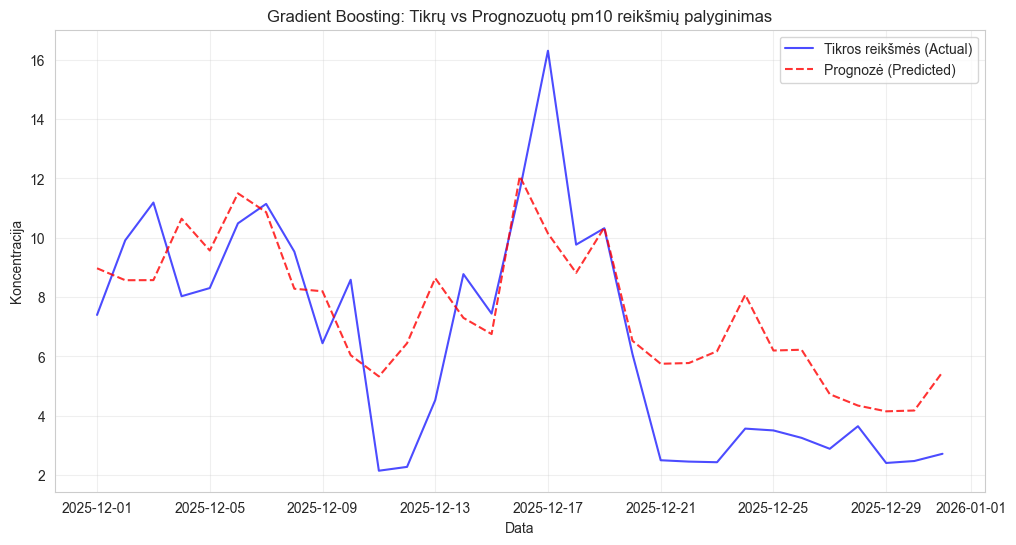

In [78]:
plt.figure(figsize=(12, 6))
plt.plot(test_data_rf_pm10.index, y_test_rf_pm10.values, label='Tikros reikšmės (Actual)', color='blue', alpha=0.7)
plt.plot(test_data_rf_pm10.index, y_pred_pm10_rf, label='Prognozė (Predicted)', color='red', linestyle='--', alpha=0.8)

plt.title(f'Gradient Boosting: Tikrų vs Prognozuotų {target} reikšmių palyginimas')
plt.xlabel('Data')
plt.ylabel('Koncentracija')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### NH3

In [79]:
forecasting_rf_nh3 = data_for_forecasting.copy()

test_cutoff = '2025-12-01'
others = ['dust', 'sia', 'pm2p5', 'pans', 'nmvoc', 'nh3', 'pm10']
target = 'nh3'

for col in others:
    forecasting_rf_nh3[f'{col}_lag_31'] = forecasting_rf_nh3[col].shift(31)
    forecasting_rf_nh3[f'{col}_lag_38'] = forecasting_rf_nh3[col].shift(38)
    forecasting_rf_nh3[f'{col}_roll_7_lag_31'] = (
        forecasting_rf_nh3[col].shift(31).rolling(window=7).mean()
    )

cols_to_remove = [c for c in others if c != target]
forecasting_rf_nh3.drop(columns=cols_to_remove, inplace=True)

forecasting_rf_nh3.dropna(inplace=True)
train_data_rf_nh3 = forecasting_rf_nh3[forecasting_rf_nh3.index < test_cutoff]
test_data_rf_nh3 = forecasting_rf_nh3[forecasting_rf_nh3.index >= test_cutoff]

X_train_rf_nh3 = train_data_rf_nh3.drop(columns=[target])
y_train_rf_nh3 = train_data_rf_nh3[target]

X_test_rf_nh3 = test_data_rf_nh3.drop(columns=[target])
y_test_rf_nh3 = test_data_rf_nh3[target]

In [80]:
tscv = TimeSeriesSplit(n_splits=3)

param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=2026),
    param_distributions=param_grid,
    n_iter=20,
    cv=tscv,
    random_state=8652,
    n_jobs=-1
)

rf_random.fit(X_train_rf_nh3, y_train_rf_nh3)
print(f"Geriausi parametrai: {rf_random.best_params_}")

best_model_rf_nh3 = rf_random.best_estimator_
y_pred_nh3_rf = best_model_rf_nh3.predict(X_test_rf_nh3)

r2 = r2_score(y_test_rf_nh3, y_pred_nh3_rf)
rmse = np.sqrt(mean_squared_error(y_test_rf_nh3 , y_pred_nh3_rf))

print(f"--- Modelio rezultatai ---")
print(f"R2 koeficientas: {r2:.4f}")
print(f"RMSE paklaida: {rmse:.4f}")

Geriausi parametrai: {'n_estimators': 200, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 30}
--- Modelio rezultatai ---
R2 koeficientas: -0.2657
RMSE paklaida: 0.0274


### nmvoc

In [81]:
forecasting_rf_nmvoc = data_for_forecasting.copy()

test_cutoff = '2025-12-01'
others = ['dust', 'sia', 'pm2p5', 'pans', 'nmvoc', 'nh3', 'pm10']
target = 'nmvoc'

for col in others:
    forecasting_rf_nmvoc[f'{col}_lag_31'] = forecasting_rf_nmvoc[col].shift(31)
forecasting_rf_nmvoc.dropna(inplace=True)

train_data_rf_nmvoc = forecasting_rf_nmvoc[forecasting_rf_nmvoc.index < test_cutoff]
test_data_rf_nmvoc = forecasting_rf_nmvoc[(forecasting_rf_nmvoc.index >= test_cutoff) &
                                 (forecasting_rf_nmvoc[target].notna())]

cols_to_drop = [target] + others

X_train_rf_nmvoc = train_data_rf_nmvoc.drop(columns=cols_to_drop)
y_train_rf_nmvoc = train_data_rf_nmvoc[target]

X_test_rf_nmvoc = test_data_rf_nmvoc.drop(columns=cols_to_drop)
y_test_rf_nmvoc = test_data_rf_nmvoc[target]

In [82]:
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=2026),
    param_distributions=param_grid,
    n_iter=20,
    cv=tscv,
    random_state=8479,
    n_jobs=-1
)

rf_random.fit(X_train_rf_nmvoc, y_train_rf_nmvoc)
print(f"Geriausi parametrai: {rf_random.best_params_}")

best_model_rf_nmvoc = rf_random.best_estimator_
y_pred_nmvoc_rf = best_model_rf_nmvoc.predict(X_test_rf_nmvoc)

r2 = r2_score(y_test_rf_nmvoc, y_pred_nmvoc_rf)
rmse = np.sqrt(mean_squared_error(y_test_rf_nmvoc , y_pred_nmvoc_rf))

print(f"--- Modelio rezultatai ---")
print(f"R2 koeficientas: {r2:.4f}")
print(f"RMSE paklaida: {rmse:.4f}")

Geriausi parametrai: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': None}
--- Modelio rezultatai ---
R2 koeficientas: 0.5285
RMSE paklaida: 2.2718


### PANS

In [83]:
forecasting_rf_pans = data_for_forecasting.copy()

test_cutoff = '2025-12-01'
others = ['dust', 'sia', 'pm2p5', 'pans', 'nmvoc', 'nh3', 'pm10']
target = 'pans'

forecasting_rf_pans.dropna(inplace=True)

train_data_rf_pans = forecasting_rf_pans[forecasting_rf_pans.index < test_cutoff]
test_data_rf_pans = forecasting_rf_pans[(forecasting_rf_pans.index >= test_cutoff) &
                                 (forecasting_rf_pans[target].notna())]

cols_to_drop = [target] + others

X_train_rf_pans = train_data_rf_pans.drop(columns=cols_to_drop)
y_train_rf_pans = train_data_rf_pans[target]

X_test_rf_pans = test_data_rf_pans.drop(columns=cols_to_drop)
y_test_rf_pans = test_data_rf_pans[target]

In [84]:
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=2026),
    param_distributions=param_grid,
    n_iter=20,
    cv=tscv,
    random_state=2026,
    n_jobs=-1
)

rf_random.fit(X_train_rf_pans, y_train_rf_pans)
print(f"Geriausi parametrai: {rf_random.best_params_}")

best_model_rf_pans = rf_random.best_estimator_
y_pred_pans_rf = best_model_rf_pans.predict(X_test_rf_pans)

r2 = r2_score(y_test_rf_pans, y_pred_pans_rf)
rmse = np.sqrt(mean_squared_error(y_test_rf_pans , y_pred_pans_rf))

print(f"--- Modelio rezultatai ---")
print(f"R2 koeficientas: {r2:.4f}")
print(f"RMSE paklaida: {rmse:.4f}")

Geriausi parametrai: {'n_estimators': 200, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 20}
--- Modelio rezultatai ---
R2 koeficientas: -0.4351
RMSE paklaida: 0.2428


### pm2p5

In [85]:
forecasting_rf_pm2p5 = data_for_forecasting.copy()

test_cutoff = '2025-12-01'
others = ['dust', 'sia', 'pm2p5', 'pans', 'nmvoc', 'nh3', 'pm10']
target = 'pm2p5'


for col in others:
    forecasting_rf_pm2p5[f'{col}_lag_31'] = forecasting_rf_pm2p5[col].shift(31)
forecasting_rf_pm2p5.dropna(inplace=True)

train_data_rf_pm2p5 = forecasting_rf_pm2p5[forecasting_rf_pm2p5.index < test_cutoff]
test_data_rf_pm2p5 = forecasting_rf_pm2p5[(forecasting_rf_pm2p5.index >= test_cutoff) &
                                 (forecasting_rf_pm2p5[target].notna())]

cols_to_drop = [target] + others

X_train_rf_pm2p5 = train_data_rf_pm2p5.drop(columns=cols_to_drop)
y_train_rf_pm2p5 = train_data_rf_pm2p5[target]

X_test_rf_pm2p5 = test_data_rf_pm2p5.drop(columns=cols_to_drop)
y_test_rf_pm2p5 = test_data_rf_pm2p5[target]

In [86]:
tscv = TimeSeriesSplit(n_splits=3)

param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=2026),
    param_distributions=param_grid,
    n_iter=10,
    cv=tscv,
    random_state=9834,
    n_jobs=-1
)

rf_random.fit(X_train_rf_pm2p5, y_train_rf_pm2p5)
print(f"Geriausi parametrai: {rf_random.best_params_}")

best_model_rf_pm2p5 = rf_random.best_estimator_
y_pred_pm2p5_rf = best_model_rf_pm2p5.predict(X_test_rf_pm2p5)

r2 = r2_score(y_test_rf_pm2p5, y_pred_pm2p5_rf)
rmse = np.sqrt(mean_squared_error(y_test_rf_pm2p5 , y_pred_pm2p5_rf))

print(f"--- Modelio rezultatai ---")
print(f"R2 koeficientas: {r2:.4f}")
print(f"RMSE paklaida: {rmse:.4f}")

Geriausi parametrai: {'n_estimators': 100, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': None}
--- Modelio rezultatai ---
R2 koeficientas: 0.4257
RMSE paklaida: 2.4065


### SIA

In [87]:
forecasting_rf_sia = data_for_forecasting.copy()

test_cutoff = '2025-12-01'
others = ['dust', 'sia', 'pm2p5', 'pans', 'nmvoc', 'nh3', 'pm10']
target = 'sia'

forecasting_rf_sia.dropna(inplace=True)

train_data_rf_sia = forecasting_rf_sia[forecasting_rf_sia.index < test_cutoff]
test_data_rf_sia = forecasting_rf_sia[(forecasting_rf_sia.index >= test_cutoff) &
                                 (forecasting_rf_sia[target].notna())]

cols_to_drop = [target] + others

X_train_rf_sia = train_data_rf_sia.drop(columns=cols_to_drop)
y_train_rf_sia = train_data_rf_sia[target]

X_test_rf_sia = test_data_rf_sia.drop(columns=cols_to_drop)
y_test_rf_sia = test_data_rf_sia[target]

In [88]:
tscv = TimeSeriesSplit(n_splits=3)

param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=2026),
    param_distributions=param_grid,
    n_iter=10,
    cv=tscv,
    random_state=2026,
    n_jobs=-1
)

rf_random.fit(X_train_rf_sia, y_train_rf_sia)
print(f"Geriausi parametrai: {rf_random.best_params_}")

best_model_rf_sia = rf_random.best_estimator_
y_pred_sia_rf = best_model_rf_sia.predict(X_test_rf_sia)

r2 = r2_score(y_test_rf_sia, y_pred_sia_rf)
rmse = np.sqrt(mean_squared_error(y_test_rf_sia , y_pred_sia_rf))

print(f"--- Modelio rezultatai ---")
print(f"R2 koeficientas: {r2:.4f}")
print(f"RMSE paklaida: {rmse:.4f}")

Geriausi parametrai: {'n_estimators': 500, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 20}
--- Modelio rezultatai ---
R2 koeficientas: 0.5909
RMSE paklaida: 1.0913


### DUST

In [89]:
forecasting_rf_dust = data_for_forecasting.copy()

test_cutoff = '2025-12-01'
others = ['dust', 'sia', 'pm2p5', 'pans', 'nmvoc', 'nh3', 'pm10']
target = 'dust'


for col in others:
    forecasting_rf_dust[f'{col}_lag_31'] = forecasting_rf_dust[col].shift(31)
forecasting_rf_dust.dropna(inplace=True)

train_data_rf_dust = forecasting_rf_dust[forecasting_rf_dust.index < test_cutoff]
test_data_rf_dust = forecasting_rf_dust[(forecasting_rf_dust.index >= test_cutoff) &
                                 (forecasting_rf_dust[target].notna())]

cols_to_drop = [target] + others

X_train_rf_dust = train_data_rf_dust.drop(columns=cols_to_drop)
y_train_rf_dust = train_data_rf_dust[target]

X_test_rf_dust = test_data_rf_dust.drop(columns=cols_to_drop)
y_test_rf_dust = test_data_rf_dust[target]

In [90]:
tscv = TimeSeriesSplit(n_splits=3)

param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=2026),
    param_distributions=param_grid,
    n_iter=10,
    cv=tscv,
    random_state=328,
    n_jobs=-1
)


rf_random.fit(X_train_rf_dust, y_train_rf_dust)
print(f"Geriausi parametrai: {rf_random.best_params_}")

best_model_rf_dust = rf_random.best_estimator_
y_pred_dust_rf = best_model_rf_dust.predict(X_test_rf_dust)

r2 = r2_score(y_test_rf_dust, y_pred_dust_rf)
rmse = np.sqrt(mean_squared_error(y_test_rf_dust , y_pred_dust_rf))

print(f"--- Modelio rezultatai ---")
print(f"R2 koeficientas: {r2:.4f}")
print(f"RMSE paklaida: {rmse:.4f}")

Geriausi parametrai: {'n_estimators': 500, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 20}
--- Modelio rezultatai ---
R2 koeficientas: 0.1853
RMSE paklaida: 0.7640


## Bazinis modelis

In [91]:
from statsmodels.tsa.stattools import kpss

def kpss_test(timeseries):
    stat, p_value, lags, critical_values = kpss(timeseries, regression='c', nlags="auto")
    
    print(f"--- KPSS Testo išvada ---")
    print(f"Statistika: {stat:.4f}")
    print(f"p-reikšmė: {p_value:.4f}")
    
    if p_value < 0.05:
        print("duomenys nestacionarus")
    else:
        print("duomenys stacionarus")

def kpss_test_trend(timeseries):
    stat, p_value, lags, critical_values = kpss(timeseries, regression='ct', nlags="auto")
    
    print(f"--- KPSS Testo išvada ---")
    print(f"Statistika: {stat:.4f}")
    print(f"p-reikšmė: {p_value:.4f}")
    
    if p_value < 0.05:
        print("duomenys nestacionarus")
    else:
        print("duomenys stacionarus")

### PM10

In [180]:
pm10 = pd.DataFrame(data_for_forecasting['pm10'].dropna())
pm10

,pm10
observationTime,
2018-07-01,1.338105
2018-07-02,1.752331
2018-07-03,1.789138
2018-07-04,4.323638
2018-07-05,3.718909
...,...
2025-12-27,2.881006
2025-12-28,3.642734
2025-12-29,2.402864


In [181]:
pm10_train = pm10.iloc[:-31]
pm10_test = pm10.iloc[-31:]

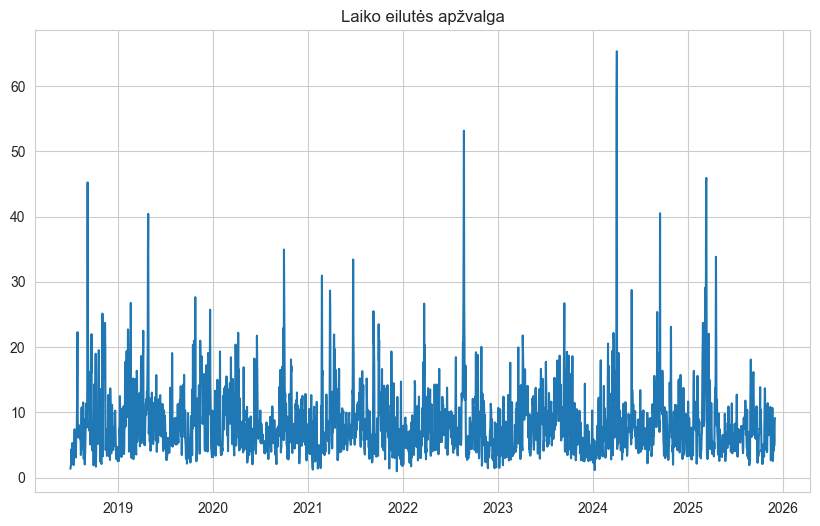

ADF Statistika: -15.342327424513035
p-reikšmė: 3.816369906100159e-28
--- KPSS Testo išvada ---
Statistika: 0.1907
p-reikšmė: 0.1000
duomenys stacionarus


C:\Users\rugil\AppData\Local\Temp\ipykernel_13308\1366889094.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p_value, lags, critical_values = kpss(timeseries, regression='c', nlags="auto")


In [182]:
from statsmodels.tsa.stattools import adfuller

plt.figure(figsize=(10, 6))
plt.plot(pm10_train)
plt.title('Laiko eilutės apžvalga')
plt.show()

# ADF Testas
result = adfuller(pm10_train)
print(f'ADF Statistika: {result[0]}')
print(f'p-reikšmė: {result[1]}')

kpss_test(pm10_train)

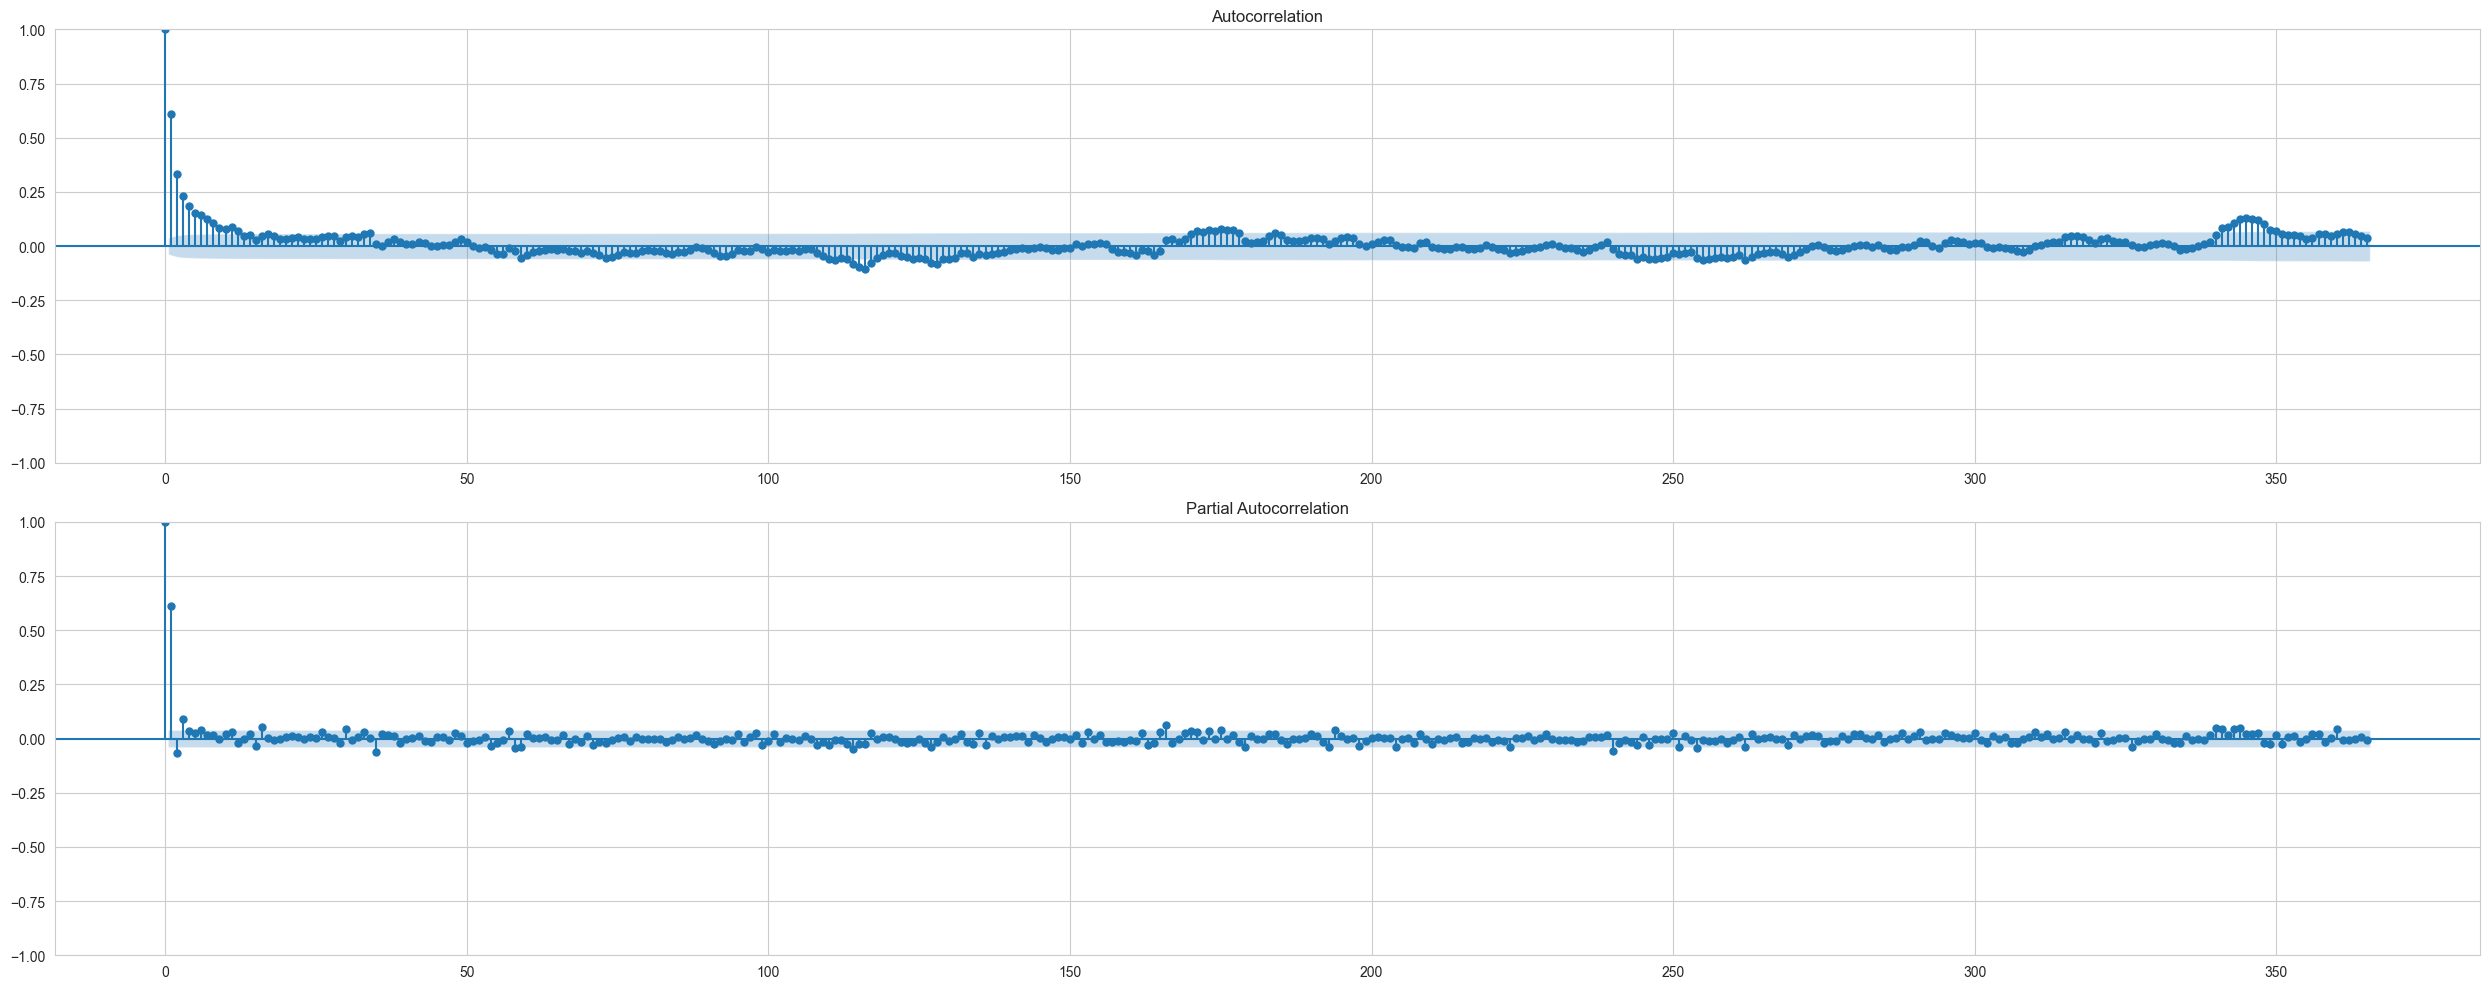

In [183]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(25, 10))
plot_acf(pm10_train, lags=365, ax=ax1)
plot_pacf(pm10_train, lags=365, ax=ax2)
plt.tight_layout()
plt.show()

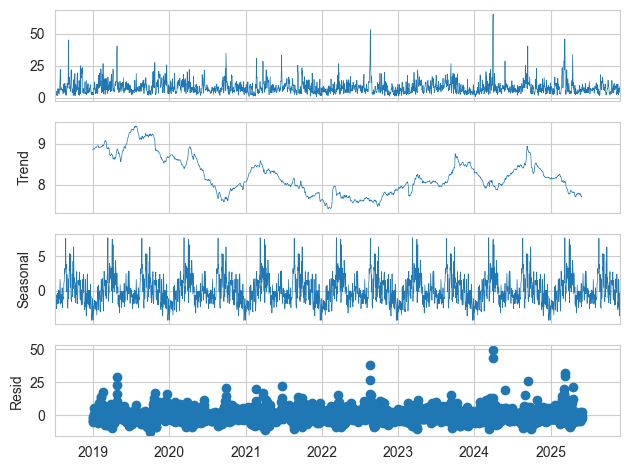

In [184]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(pm10_train, model='additive', period=365)

fig = decomposition.plot()

for ax in fig.axes:
    for line in ax.get_lines():
        line.set_linewidth(0.5)

plt.show()

C:\Users\rugil\AppData\Local\Temp\ipykernel_13308\3879045431.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pm10_train['pm10_Seasonal_Diff'] = pm10_train['pm10'] - pm10_train['pm10'].shift(365)


ADF Statistic after Differencing: -20.8055
p-value after Seasonal Differencing: 0.0


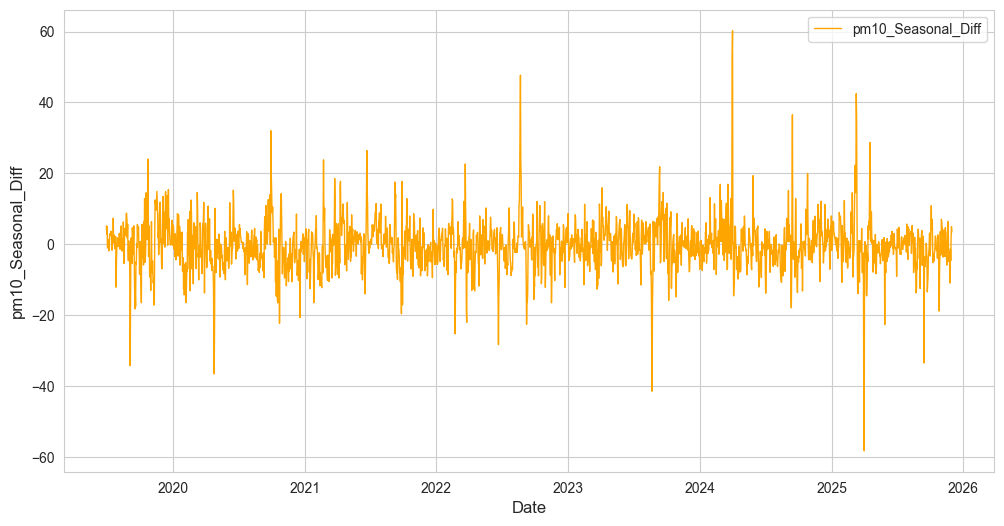

In [185]:
pm10_train['pm10_Seasonal_Diff'] = pm10_train['pm10'] - pm10_train['pm10'].shift(365) 

result_diff_seasonal = adfuller(pm10_train['pm10_Seasonal_Diff'].dropna())
print("ADF Statistic after Differencing:", result_diff_seasonal[0].round(4))
print("p-value after Seasonal Differencing:", result_diff_seasonal[1])

plt.figure(figsize=(12, 6))
plt.plot(pm10_train.index, pm10_train['pm10_Seasonal_Diff'], label='pm10_Seasonal_Diff', linewidth=1, color='orange')
plt.xlabel('Date', fontsize=12)
plt.ylabel('pm10_Seasonal_Diff', fontsize=12)
plt.grid(True)
plt.legend()
plt.show()

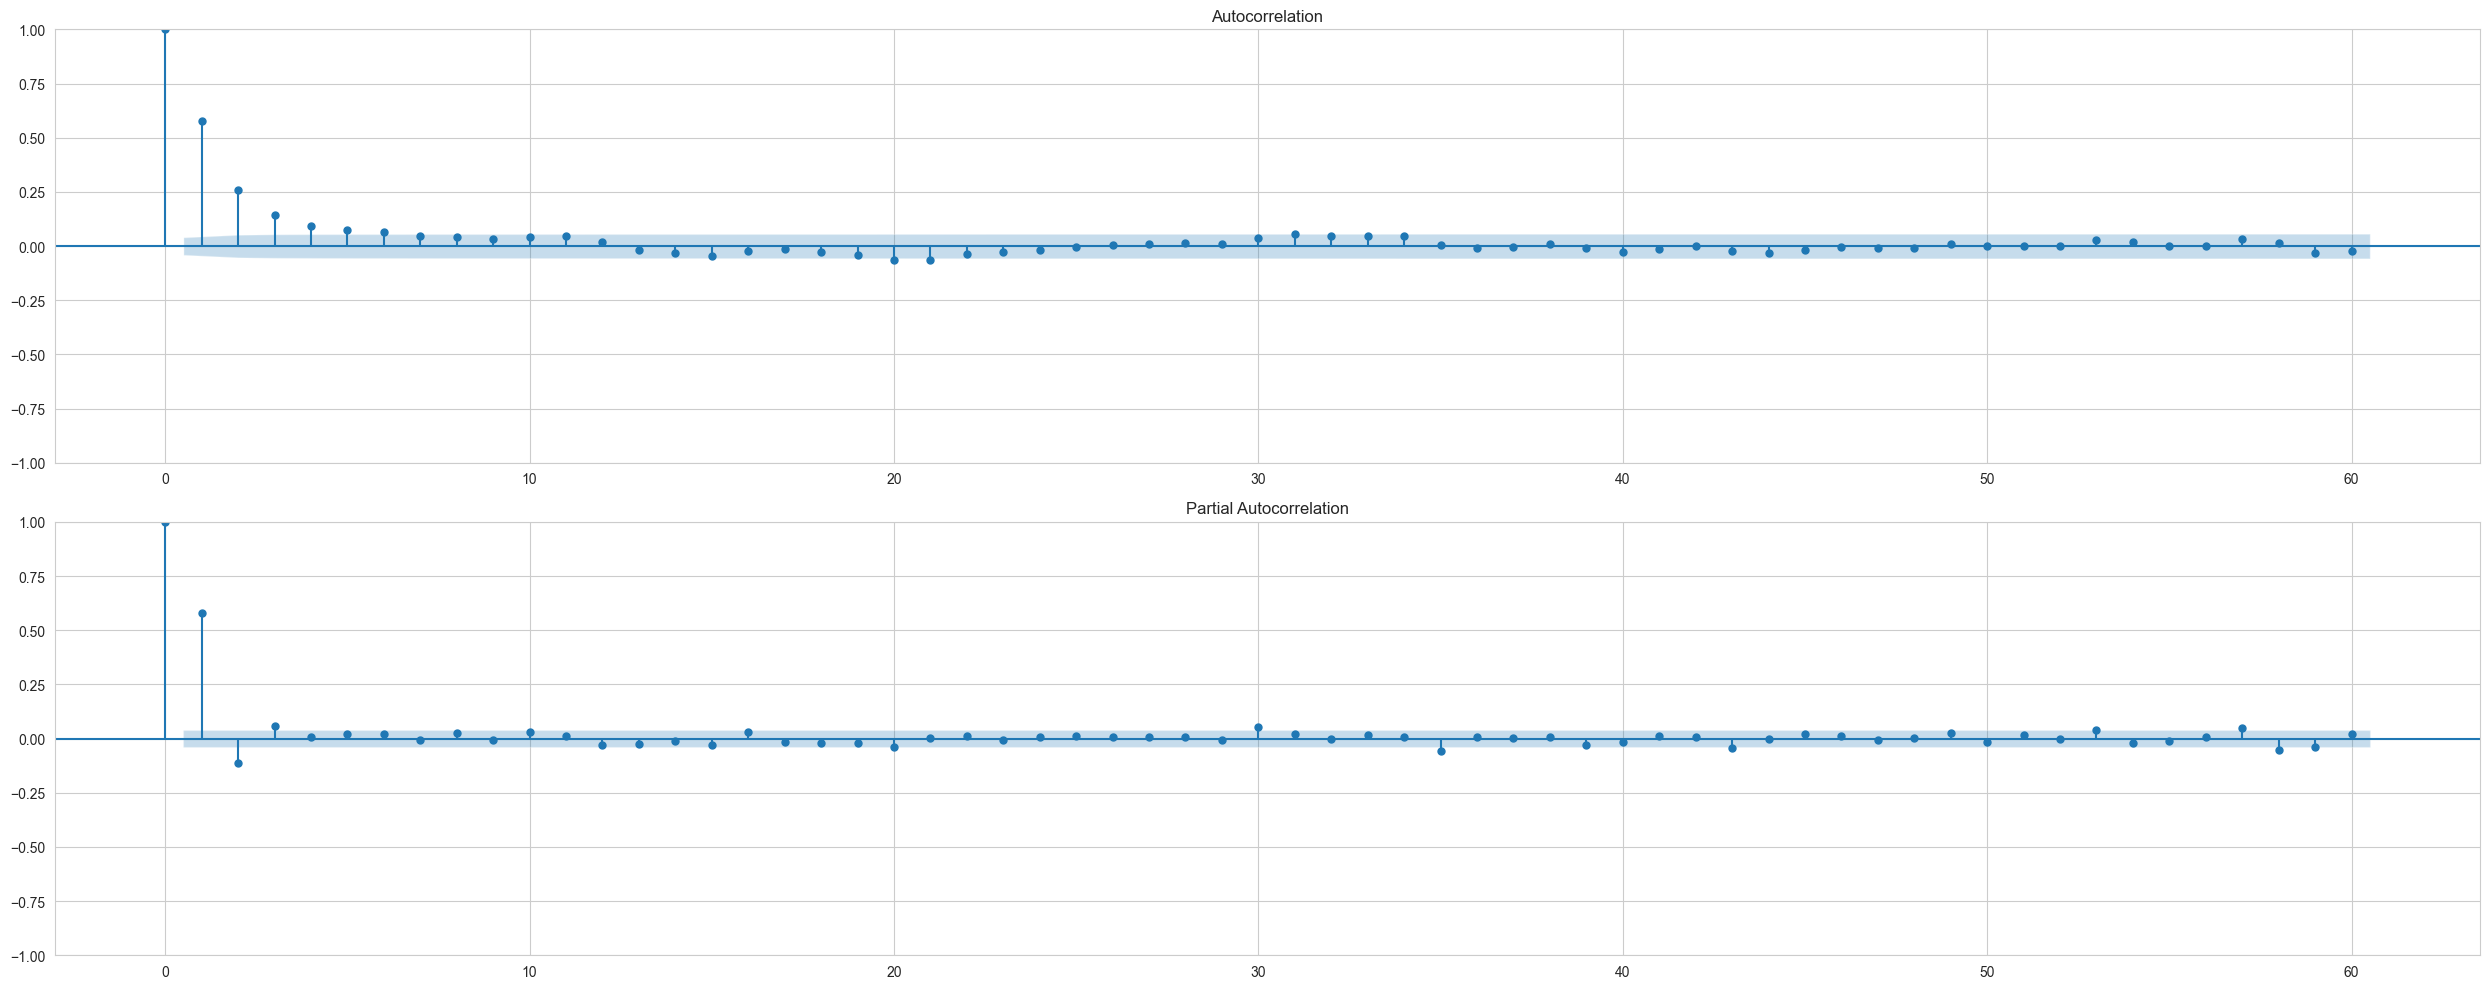

In [186]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(25, 10))
plot_acf(pm10_train['pm10_Seasonal_Diff'].dropna(), lags=60, ax=ax1)
plot_pacf(pm10_train['pm10_Seasonal_Diff'].dropna(), lags=60, ax=ax2)
plt.tight_layout()
plt.show()

In [187]:
from pmdarima import auto_arima

model = auto_arima(pm10_train['pm10_Seasonal_Diff'].dropna(), 
                   stepwise=True, 
                   suppress_warnings=True, 
                   error_action="ignore", 
                   trace=True)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=14760.346, Time=2.54 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=15750.291, Time=0.16 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=14794.167, Time=0.38 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=14904.990, Time=0.82 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=15749.781, Time=0.07 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=14760.961, Time=1.40 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=14761.842, Time=1.94 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=inf, Time=6.14 sec
 ARIMA(2,0,3)(0,0,0)[0] intercept   : AIC=14762.267, Time=2.90 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=14761.234, Time=0.75 sec
 ARIMA(1,0,3)(0,0,0)[0] intercept   : AIC=14760.876, Time=1.72 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=14761.297, Time=3.67 sec
 ARIMA(3,0,3)(0,0,0)[0] intercept   : AIC=14761.589, Time=6.57 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=14758.712, Time=1.28 sec
 ARIMA(1,0,2)(0,0,0)[0]  

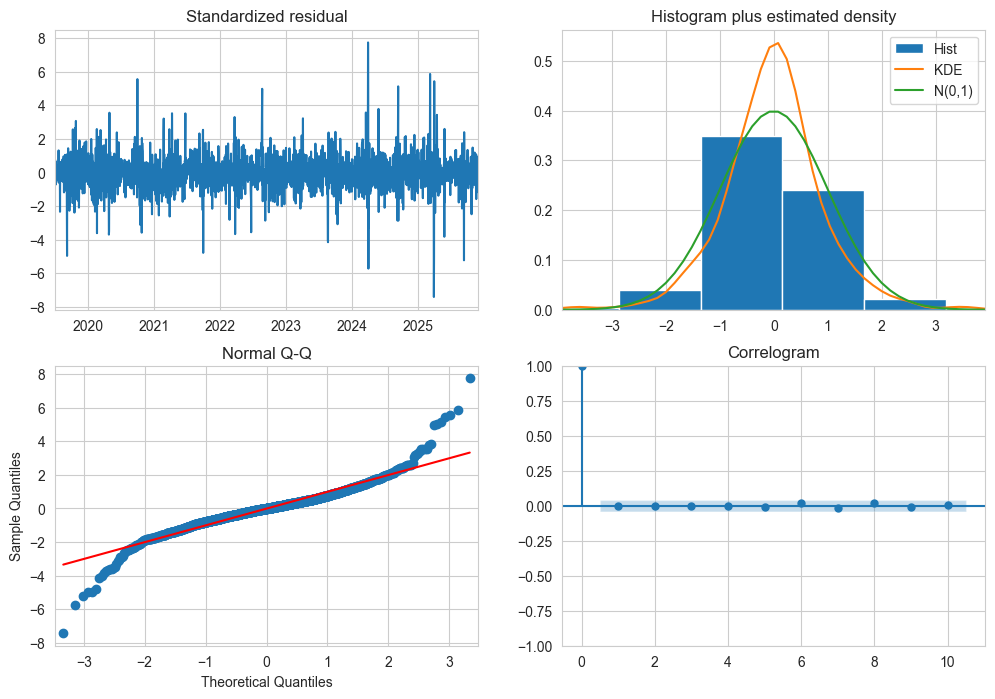

In [188]:
model.plot_diagnostics(figsize=(12, 8))
plt.show()

In [189]:
n = len(pm10_test)

# forecastingam diff erdveje
forecast_diff, conf_int = model.predict(n_periods=n, return_conf_int=True)

# atstatom tai ka pasalinom (y_t - y_{t-365}) + y_{t-365} = y_t
# base = pm10_train['pm10'].shift(366).iloc[-n:].values
base = pm10['pm10'].iloc[-365 - n : -365].values
forecast_real = forecast_diff + base

sarima_pm10 = pd.Series(forecast_real, index=pm10_test.index)
conf_int_real = conf_int + base.reshape(-1, 1)

In [190]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_true = pm10_test['pm10']
y_pred = sarima_pm10

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

MSE: 24.31
MAE: 3.97
RMSE: 4.93
R²: -0.7470


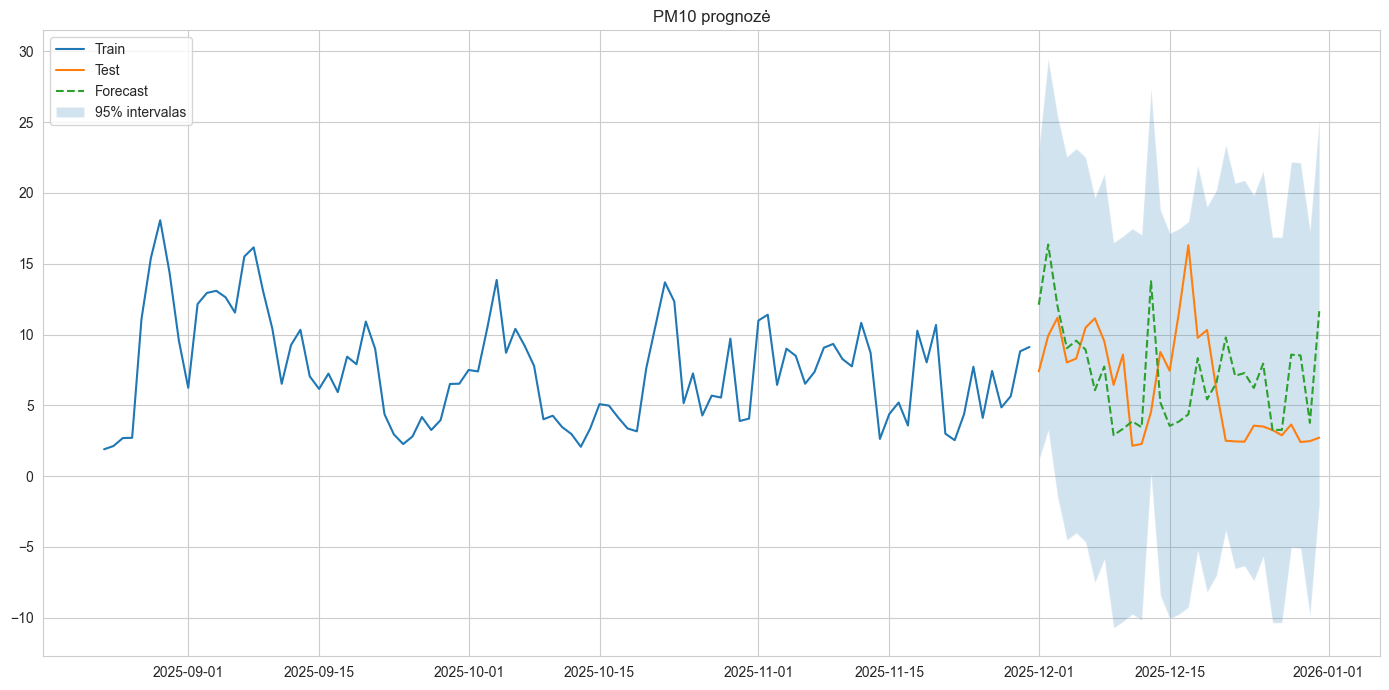

In [191]:
plt.figure(figsize=(14, 7))

plt.plot(pm10_train.tail(100).index, pm10_train.tail(100)['pm10'], label='Train')
plt.plot(pm10_test.index, pm10_test['pm10'], label='Test')
plt.plot(sarima_pm10.index, sarima_pm10, linestyle='--', label='Forecast')

plt.fill_between(pm10_test.index,
                 conf_int_real[:, 0],
                 conf_int_real[:, 1],
                 alpha=0.2,
                 label='95% intervalas')

plt.title('PM10 prognozė')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### NH3

In [192]:
nh3 = pd.DataFrame(data_for_forecasting['nh3'].dropna())
nh3_train = nh3.iloc[:-31]
nh3_test = nh3.iloc[-31:]

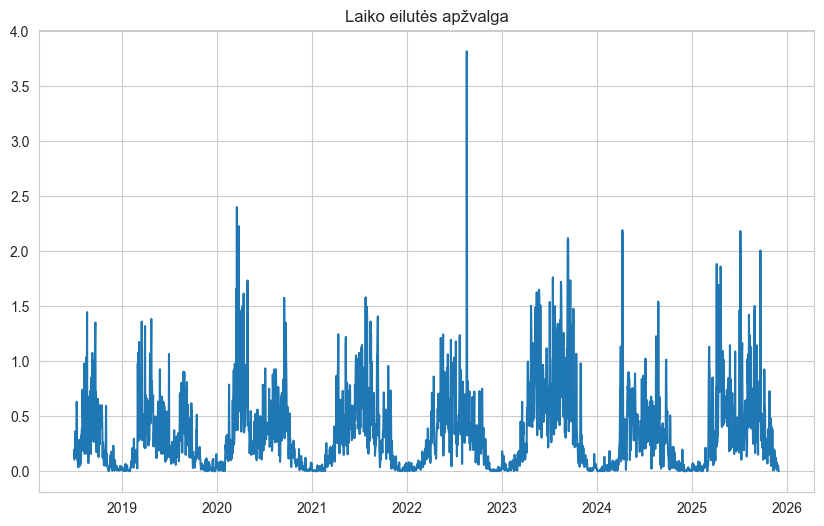

ADF Statistika: -4.295367508520816
p-reikšmė: 0.0004524895173033109
--- KPSS Testo išvada ---
Statistika: 0.1711
p-reikšmė: 0.1000
duomenys stacionarus


C:\Users\rugil\AppData\Local\Temp\ipykernel_13308\1366889094.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p_value, lags, critical_values = kpss(timeseries, regression='c', nlags="auto")


In [193]:
plt.figure(figsize=(10, 6))
plt.plot(nh3_train)
plt.title('Laiko eilutės apžvalga')
plt.show()

# ADF Testas
result = adfuller(nh3_train)
print(f'ADF Statistika: {result[0]}')
print(f'p-reikšmė: {result[1]}')

kpss_test(nh3_train)

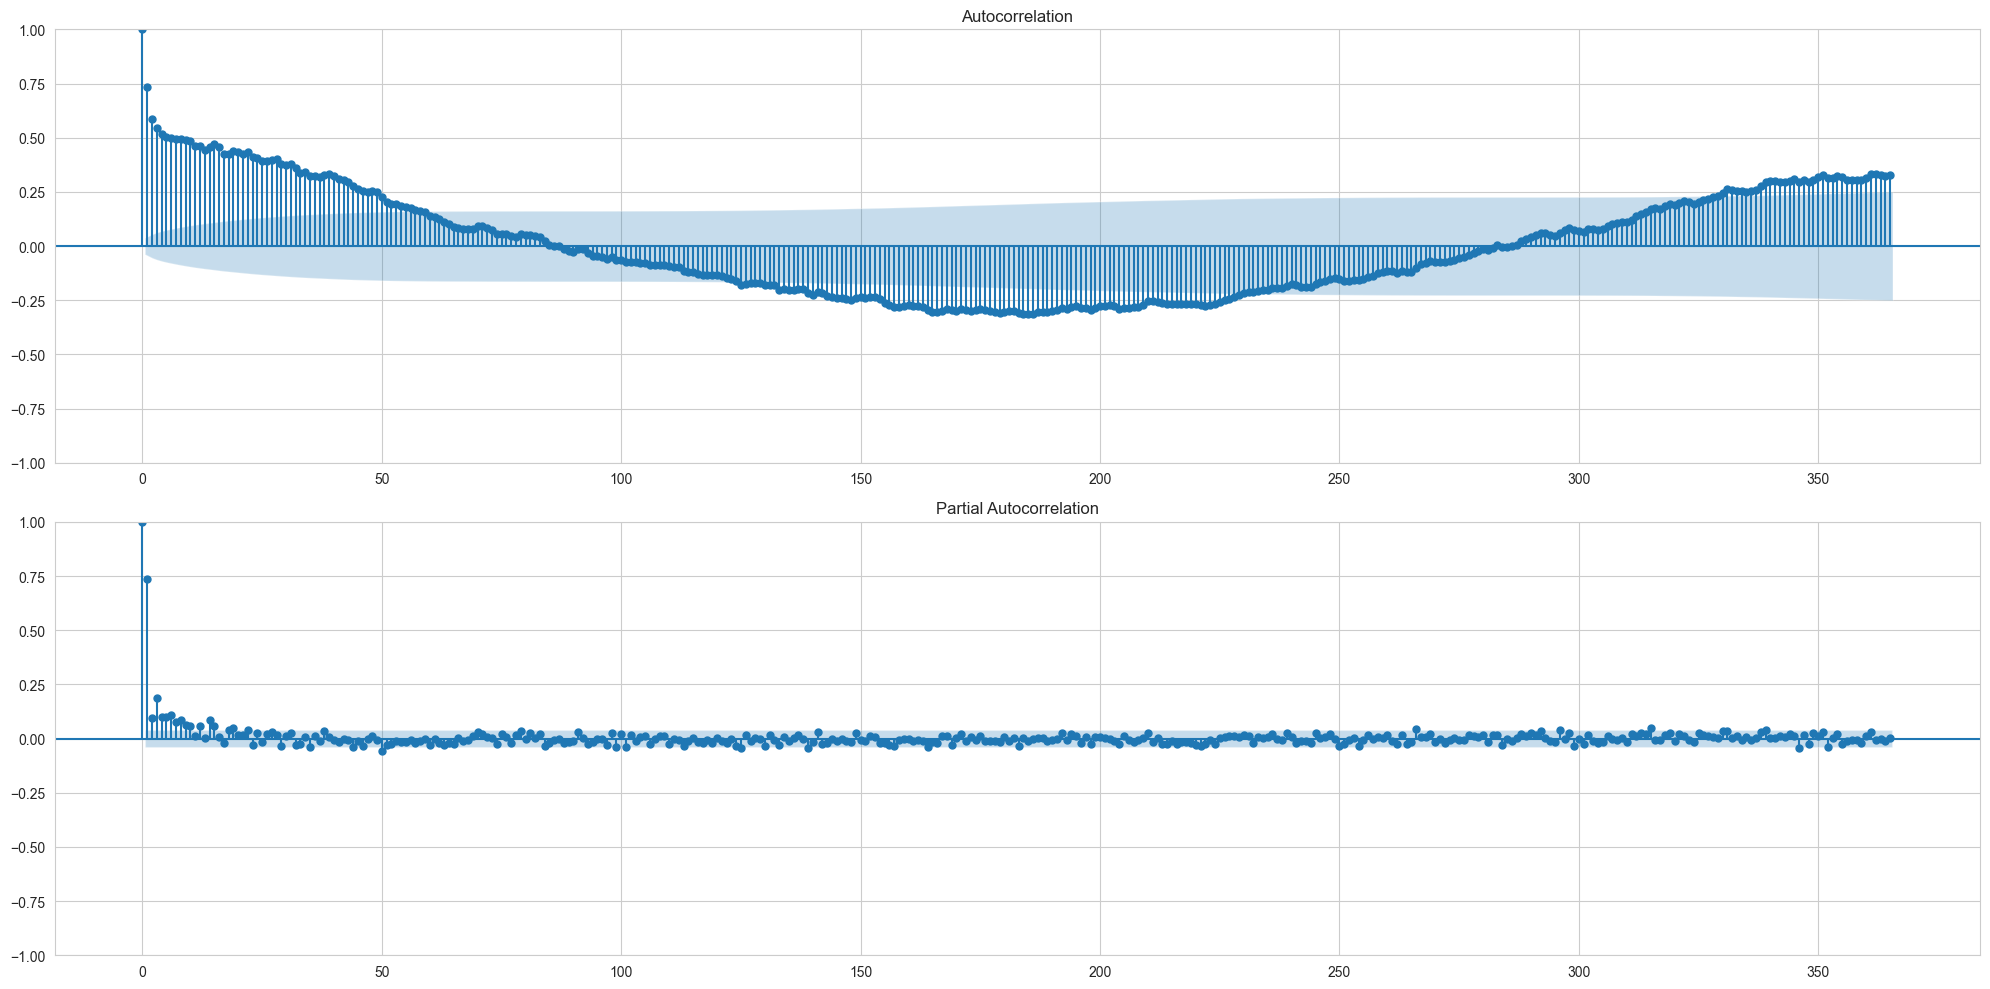

In [194]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10))
plot_acf(nh3_train, lags=365, ax=ax1)
plot_pacf(nh3_train, lags=365, ax=ax2)
plt.tight_layout()
plt.show()

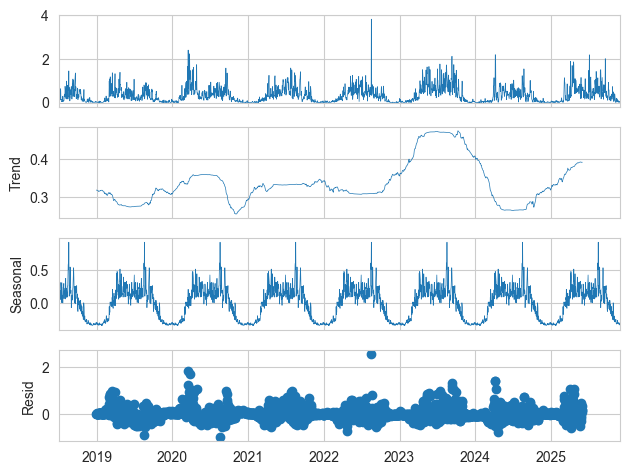

In [195]:
decomposition = seasonal_decompose(nh3_train, model='additive', period=365)

fig = decomposition.plot()

for ax in fig.axes:
    for line in ax.get_lines():
        line.set_linewidth(0.5)

plt.show()

C:\Users\rugil\AppData\Local\Temp\ipykernel_13308\4102958824.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nh3_train['nh3_Seasonal_Diff'] = nh3_train['nh3'] - nh3_train['nh3'].shift(365)


ADF Statistic after Differencing: -5.0582
p-value after Seasonal Differencing: 0.0


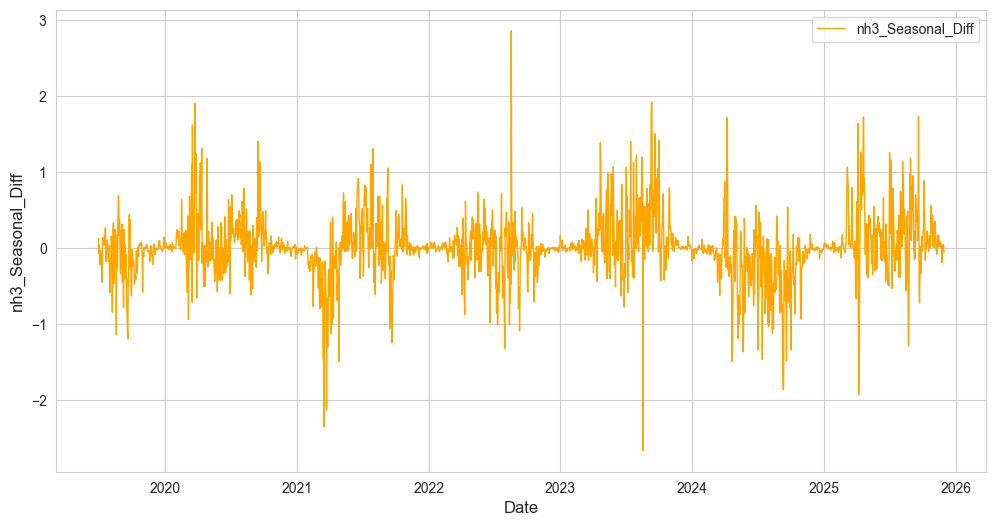

In [196]:
nh3_train['nh3_Seasonal_Diff'] = nh3_train['nh3'] - nh3_train['nh3'].shift(365) 

result_diff_seasonal = adfuller(nh3_train['nh3_Seasonal_Diff'].dropna())
print("ADF Statistic after Differencing:", result_diff_seasonal[0].round(4))
print("p-value after Seasonal Differencing:", result_diff_seasonal[1].round(4))


plt.figure(figsize=(12, 6))
plt.plot(nh3_train.index, nh3_train['nh3_Seasonal_Diff'], label='nh3_Seasonal_Diff', linewidth=1, color='orange')
plt.xlabel('Date', fontsize=12)
plt.ylabel('nh3_Seasonal_Diff', fontsize=12)
plt.grid(True)
plt.legend()
plt.show()

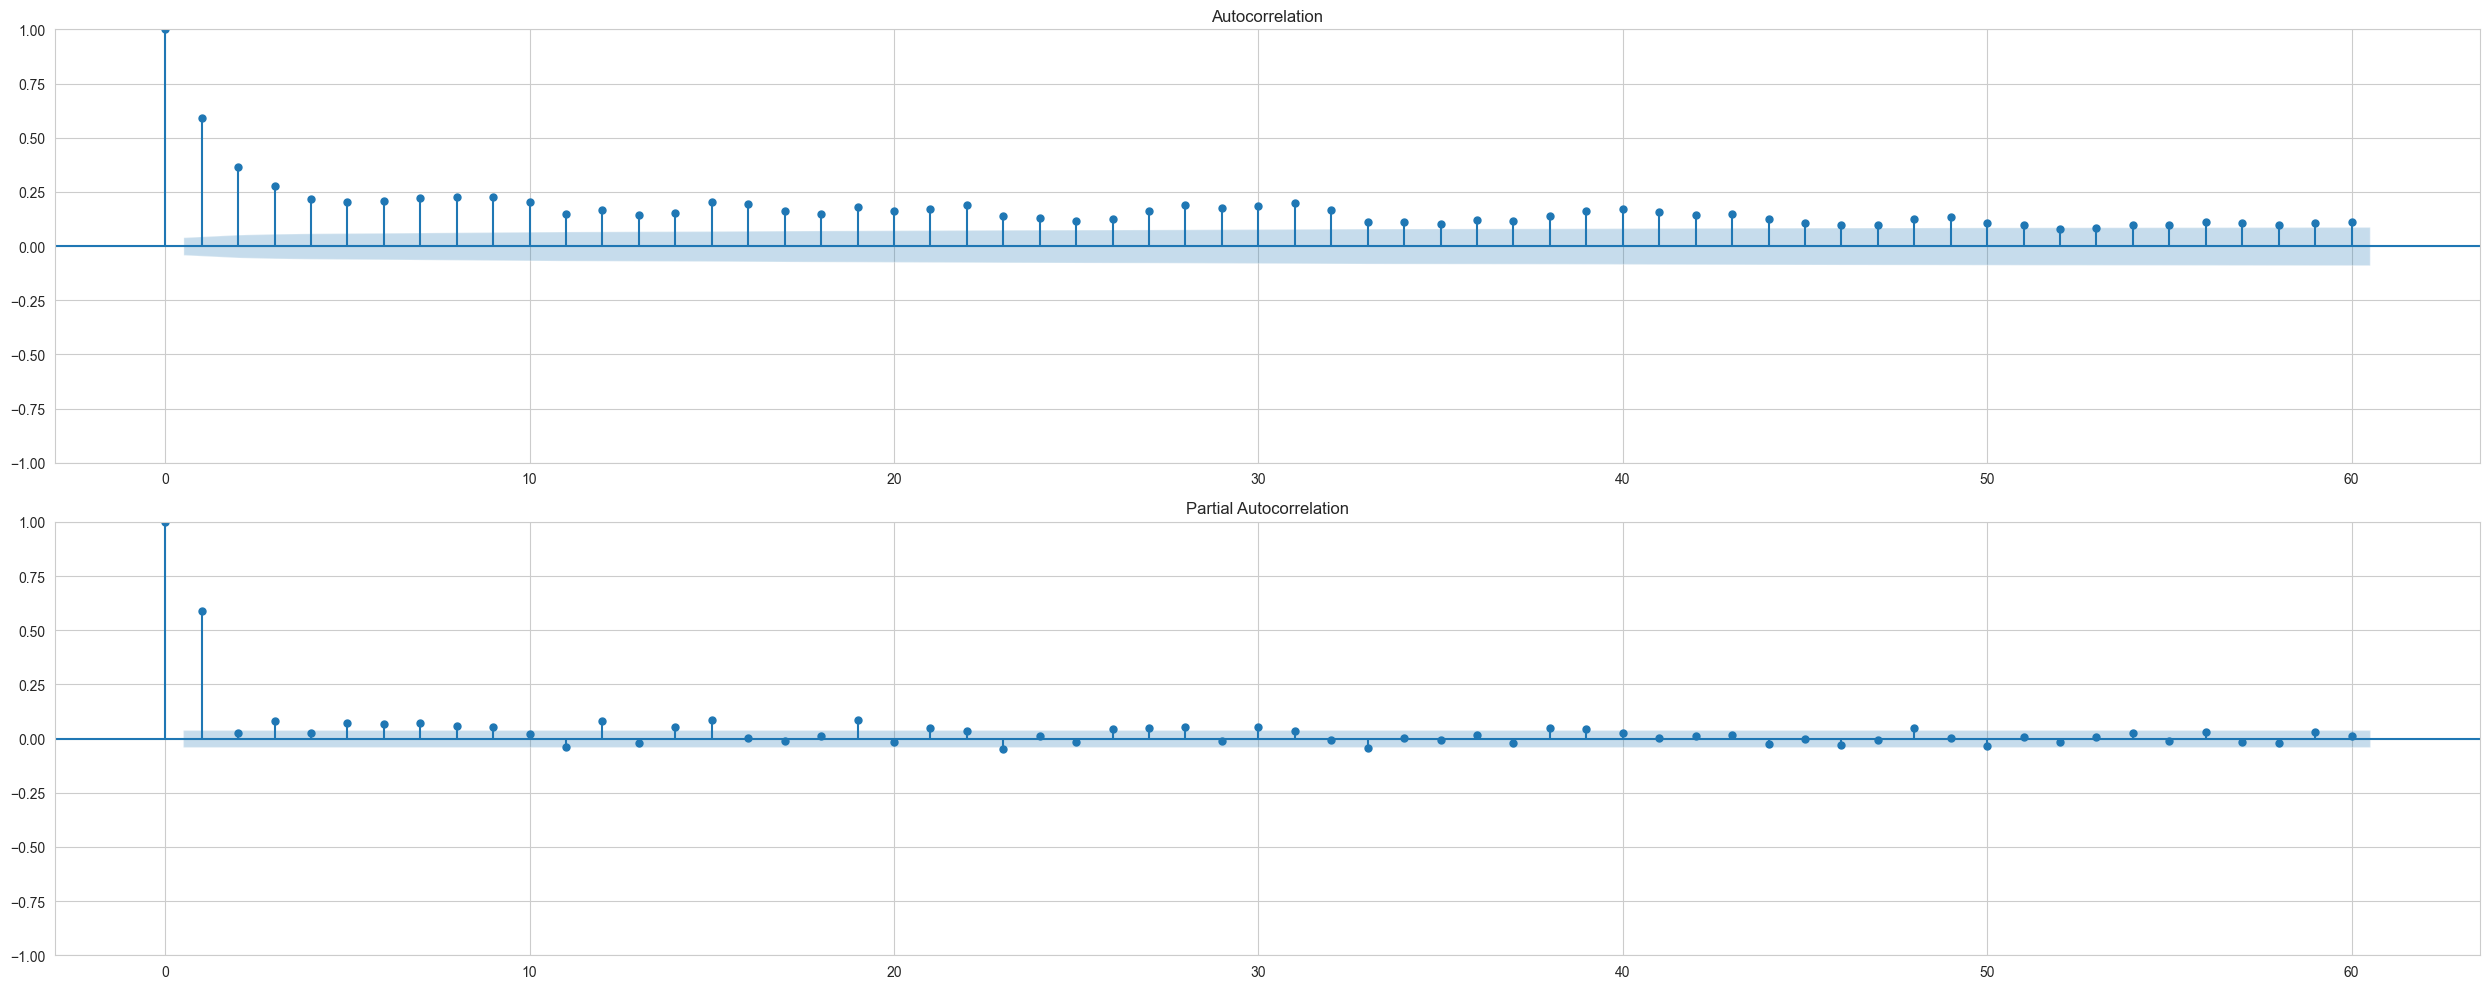

In [197]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(25, 10))
plot_acf(nh3_train['nh3_Seasonal_Diff'].dropna(), lags=60, ax=ax1)
plot_pacf(nh3_train['nh3_Seasonal_Diff'].dropna(), lags=60, ax=ax2)
plt.tight_layout()
plt.show()

In [198]:
model = auto_arima(nh3_train['nh3_Seasonal_Diff'].dropna(), 
                   stepwise=True, 
                   seasonal=True,
                   m=7,
                   suppress_warnings=True, 
                   error_action="ignore", 
                   trace=True)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[7] intercept   : AIC=1363.727, Time=9.83 sec
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=2431.078, Time=0.53 sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=1423.923, Time=1.12 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=1634.983, Time=2.79 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=2430.954, Time=0.21 sec
 ARIMA(2,0,2)(0,0,1)[7] intercept   : AIC=1357.495, Time=9.28 sec
 ARIMA(2,0,2)(0,0,0)[7] intercept   : AIC=1355.622, Time=5.14 sec
 ARIMA(2,0,2)(1,0,0)[7] intercept   : AIC=1364.644, Time=8.87 sec
 ARIMA(1,0,2)(0,0,0)[7] intercept   : AIC=1395.602, Time=3.03 sec
 ARIMA(2,0,1)(0,0,0)[7] intercept   : AIC=1436.047, Time=1.36 sec
 ARIMA(3,0,2)(0,0,0)[7] intercept   : AIC=1362.457, Time=6.16 sec
 ARIMA(2,0,3)(0,0,0)[7] intercept   : AIC=1360.219, Time=5.64 sec
 ARIMA(1,0,1)(0,0,0)[7] intercept   : AIC=1431.992, Time=0.97 sec
 ARIMA(1,0,3)(0,0,0)[7] intercept   : AIC=1368.943, Time=4.33 sec
 ARIMA(3,0,1)(0,0,0)[7] intercept

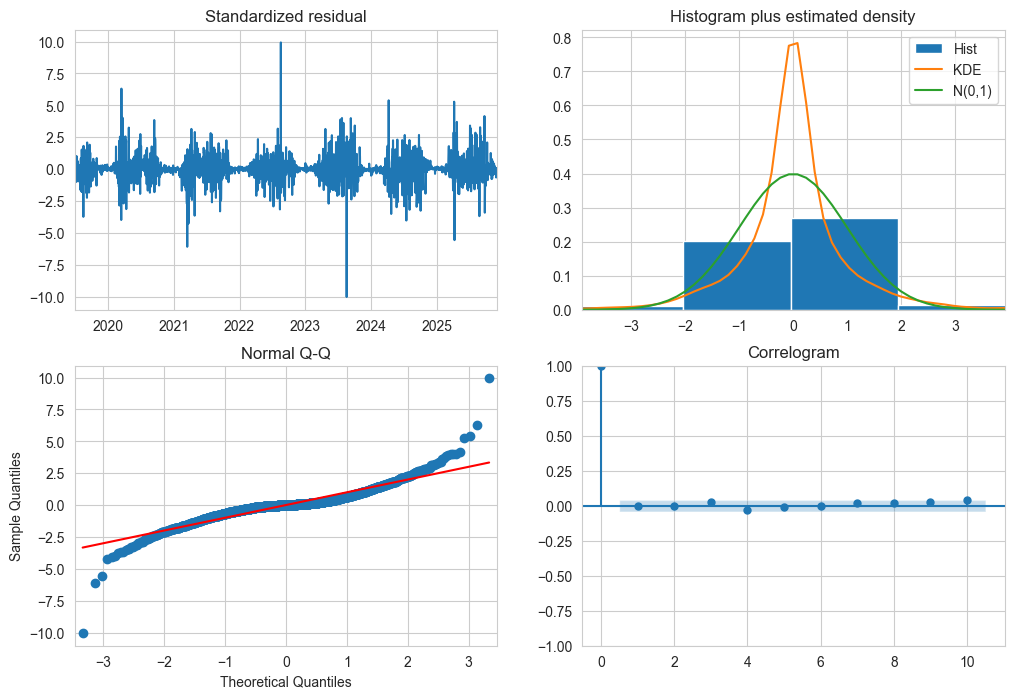

In [199]:
model.plot_diagnostics(figsize=(12, 8))
plt.show()

In [200]:
n = len(nh3_test)

# forecastingam diff erdveje
forecast_diff, conf_int = model.predict(n_periods=n, return_conf_int=True)

# atstatom tai ka pasalinom (y_t - y_{t-365}) + y_{t-365} = y_t
# base = nh3_train['nh3'].shift(365).iloc[-n:].values
base = nh3['nh3'].iloc[-365 - n : -365].values
forecast_real = forecast_diff + base

sarima_nh3 = pd.Series(forecast_real, index=nh3_test.index)
conf_int_real = conf_int + base.reshape(-1, 1)

In [201]:
y_true = nh3_test['nh3']
y_pred = sarima_nh3 

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

MSE: 0.00
MAE: 0.02
RMSE: 0.03
R²: -0.1895


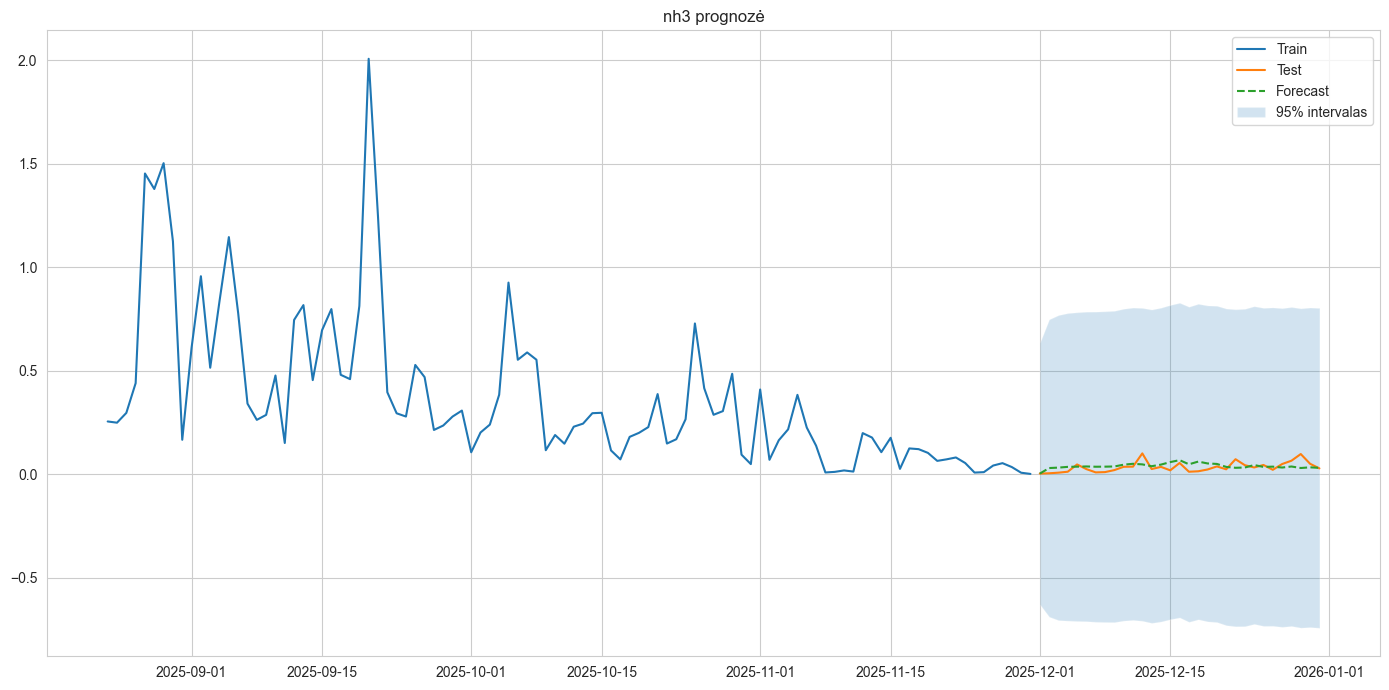

In [202]:
plt.figure(figsize=(14, 7))

plt.plot(nh3_train.tail(100).index, nh3_train.tail(100)['nh3'], label='Train')
plt.plot(nh3_test.index, nh3_test['nh3'], label='Test')
plt.plot(sarima_nh3 .index, sarima_nh3 , linestyle='--', label='Forecast')

plt.fill_between(nh3_test.index,
                 conf_int_real[:, 0],
                 conf_int_real[:, 1],
                 alpha=0.2,
                 label='95% intervalas')

plt.title('nh3 prognozė')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### NMVOC

In [203]:
nmvoc = pd.DataFrame(data_for_forecasting['nmvoc'].dropna())
nmvoc_train = nmvoc.iloc[:-31]
nmvoc_test = nmvoc.iloc[-31:]

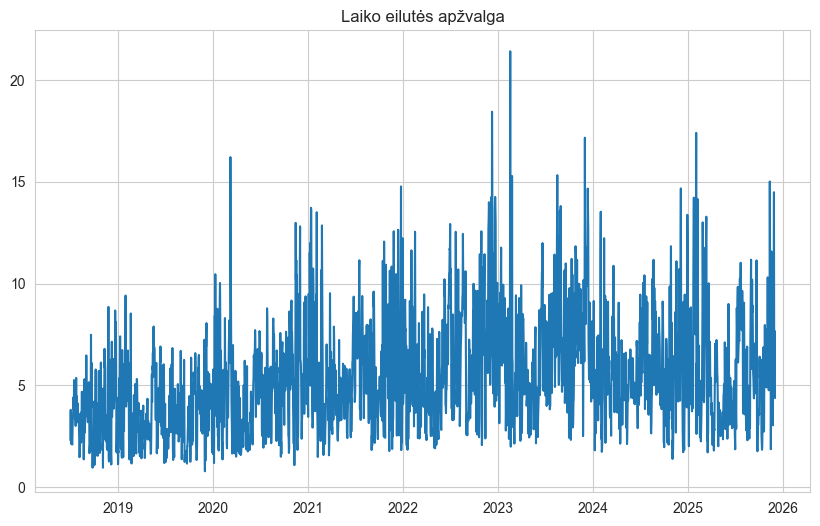

ADF Statistika: -6.355407939203517
p-reikšmė: 2.5500806129556712e-08
--- KPSS Testo išvada ---
Statistika: 0.6297
p-reikšmė: 0.0100
duomenys nestacionarus


C:\Users\rugil\AppData\Local\Temp\ipykernel_13308\1366889094.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, p_value, lags, critical_values = kpss(timeseries, regression='ct', nlags="auto")


In [204]:
plt.figure(figsize=(10, 6))
plt.plot(nmvoc_train)
plt.title('Laiko eilutės apžvalga')
plt.show()

# ADF Testas
result = adfuller(nmvoc_train)
print(f'ADF Statistika: {result[0]}')
print(f'p-reikšmė: {result[1]}')

kpss_test_trend(nmvoc_train)

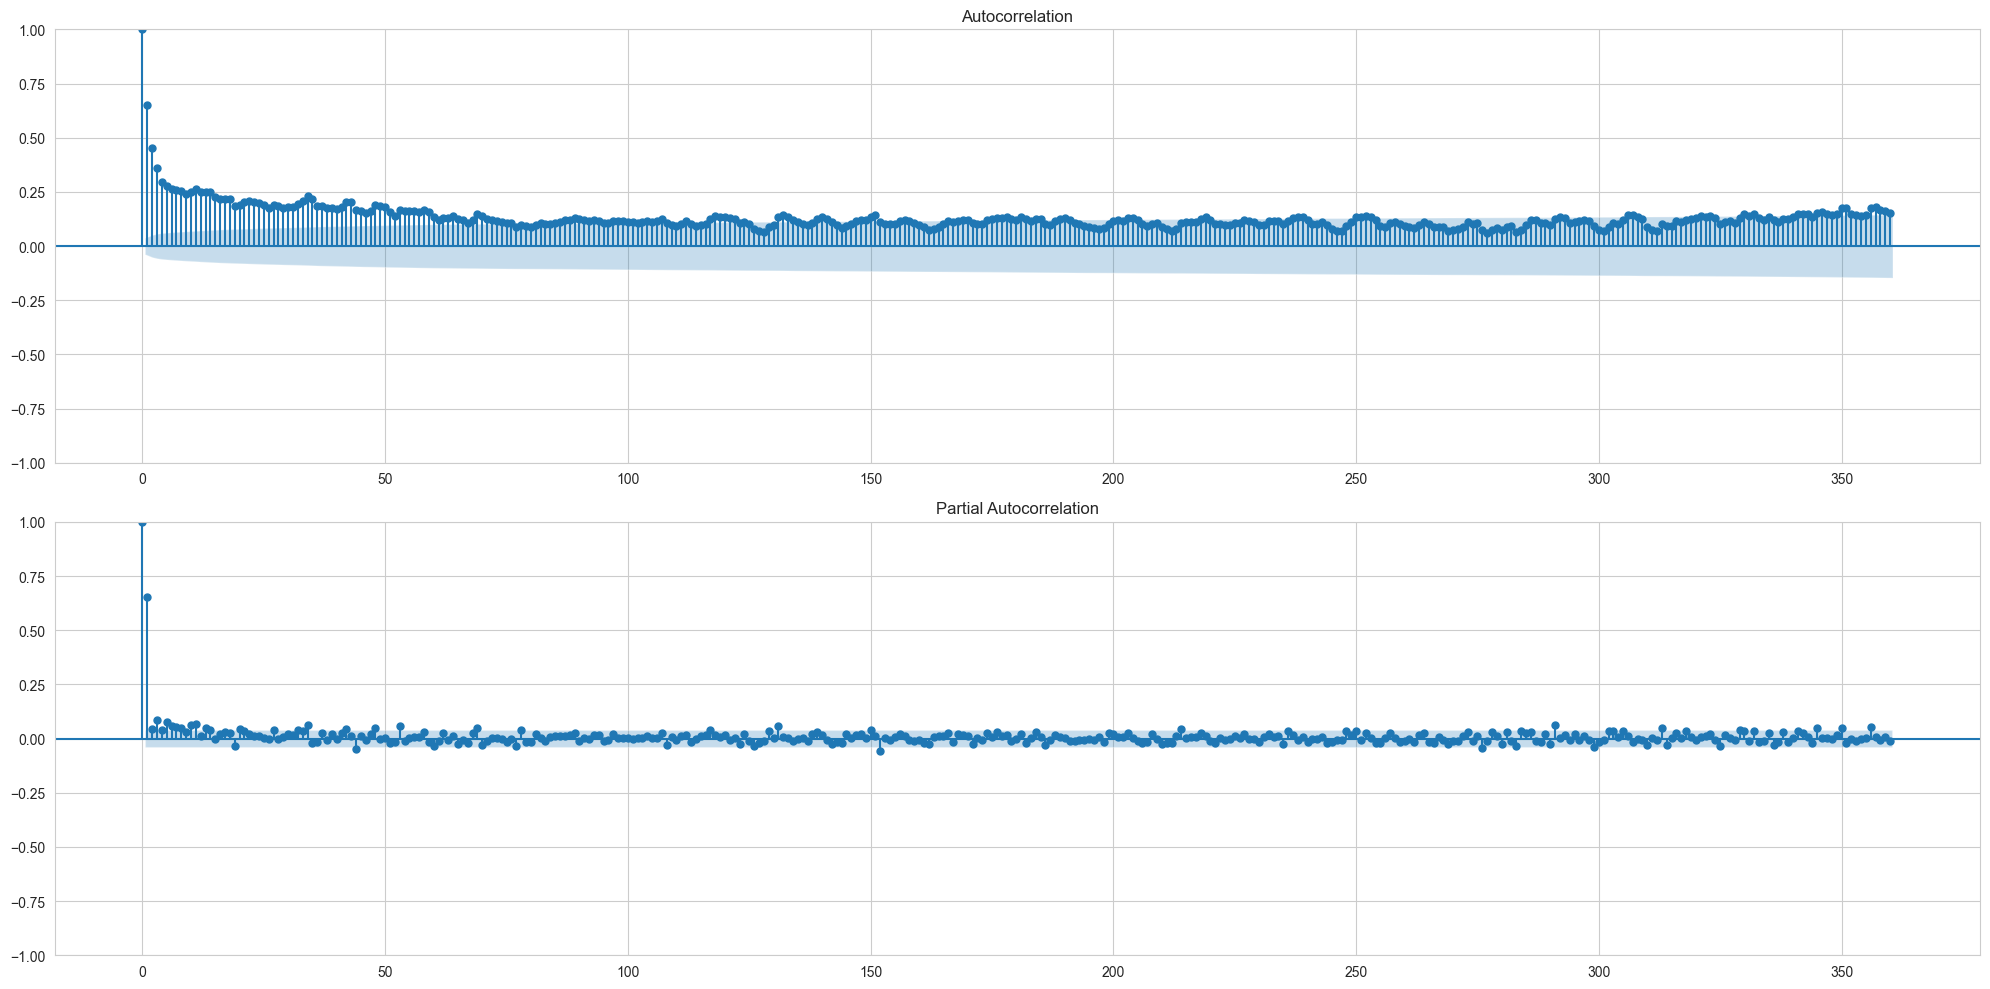

In [205]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10))
plot_acf(nmvoc_train, lags=360, ax=ax1)
plot_pacf(nmvoc_train, lags=360, ax=ax2)
plt.tight_layout()
plt.show()

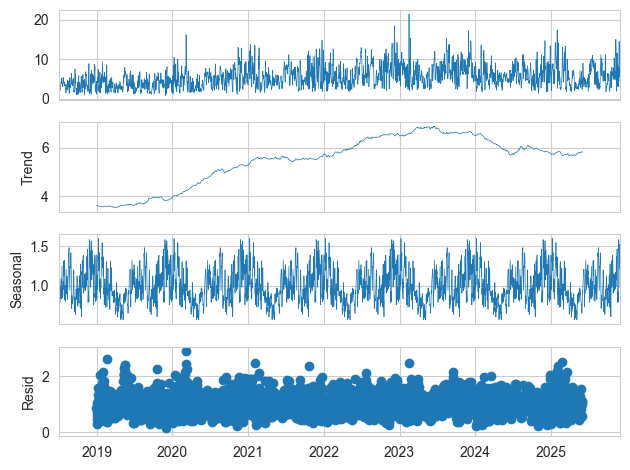

In [206]:
decomposition = seasonal_decompose(nmvoc_train, model='multiplicative', period=365)

fig = decomposition.plot()

for ax in fig.axes:
    for line in ax.get_lines():
        line.set_linewidth(0.5)

plt.show()

C:\Users\rugil\AppData\Local\Temp\ipykernel_13308\512341864.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nmvoc_train['nmvoc_Seasonal_Diff'] = nmvoc_train['nmvoc'] - nmvoc_train['nmvoc'].shift(365)


ADF Statistic after Differencing: -8.304
p-value after Seasonal Differencing: 3.9483818585883764e-13


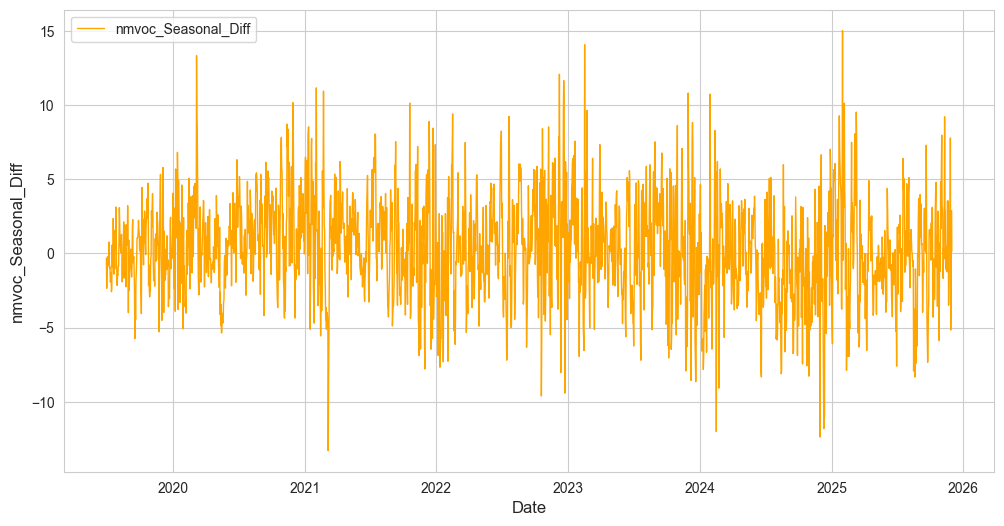

In [207]:
nmvoc_train['nmvoc_Seasonal_Diff'] = nmvoc_train['nmvoc'] - nmvoc_train['nmvoc'].shift(365) 

result_diff_seasonal = adfuller(nmvoc_train['nmvoc_Seasonal_Diff'].dropna())
print("ADF Statistic after Differencing:", result_diff_seasonal[0].round(4))
print("p-value after Seasonal Differencing:", result_diff_seasonal[1])


plt.figure(figsize=(12, 6))
plt.plot(nmvoc_train.index, nmvoc_train['nmvoc_Seasonal_Diff'], label='nmvoc_Seasonal_Diff', linewidth=1, color='orange')
plt.title('', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('nmvoc_Seasonal_Diff', fontsize=12)
plt.grid(True)
plt.legend()
plt.show()

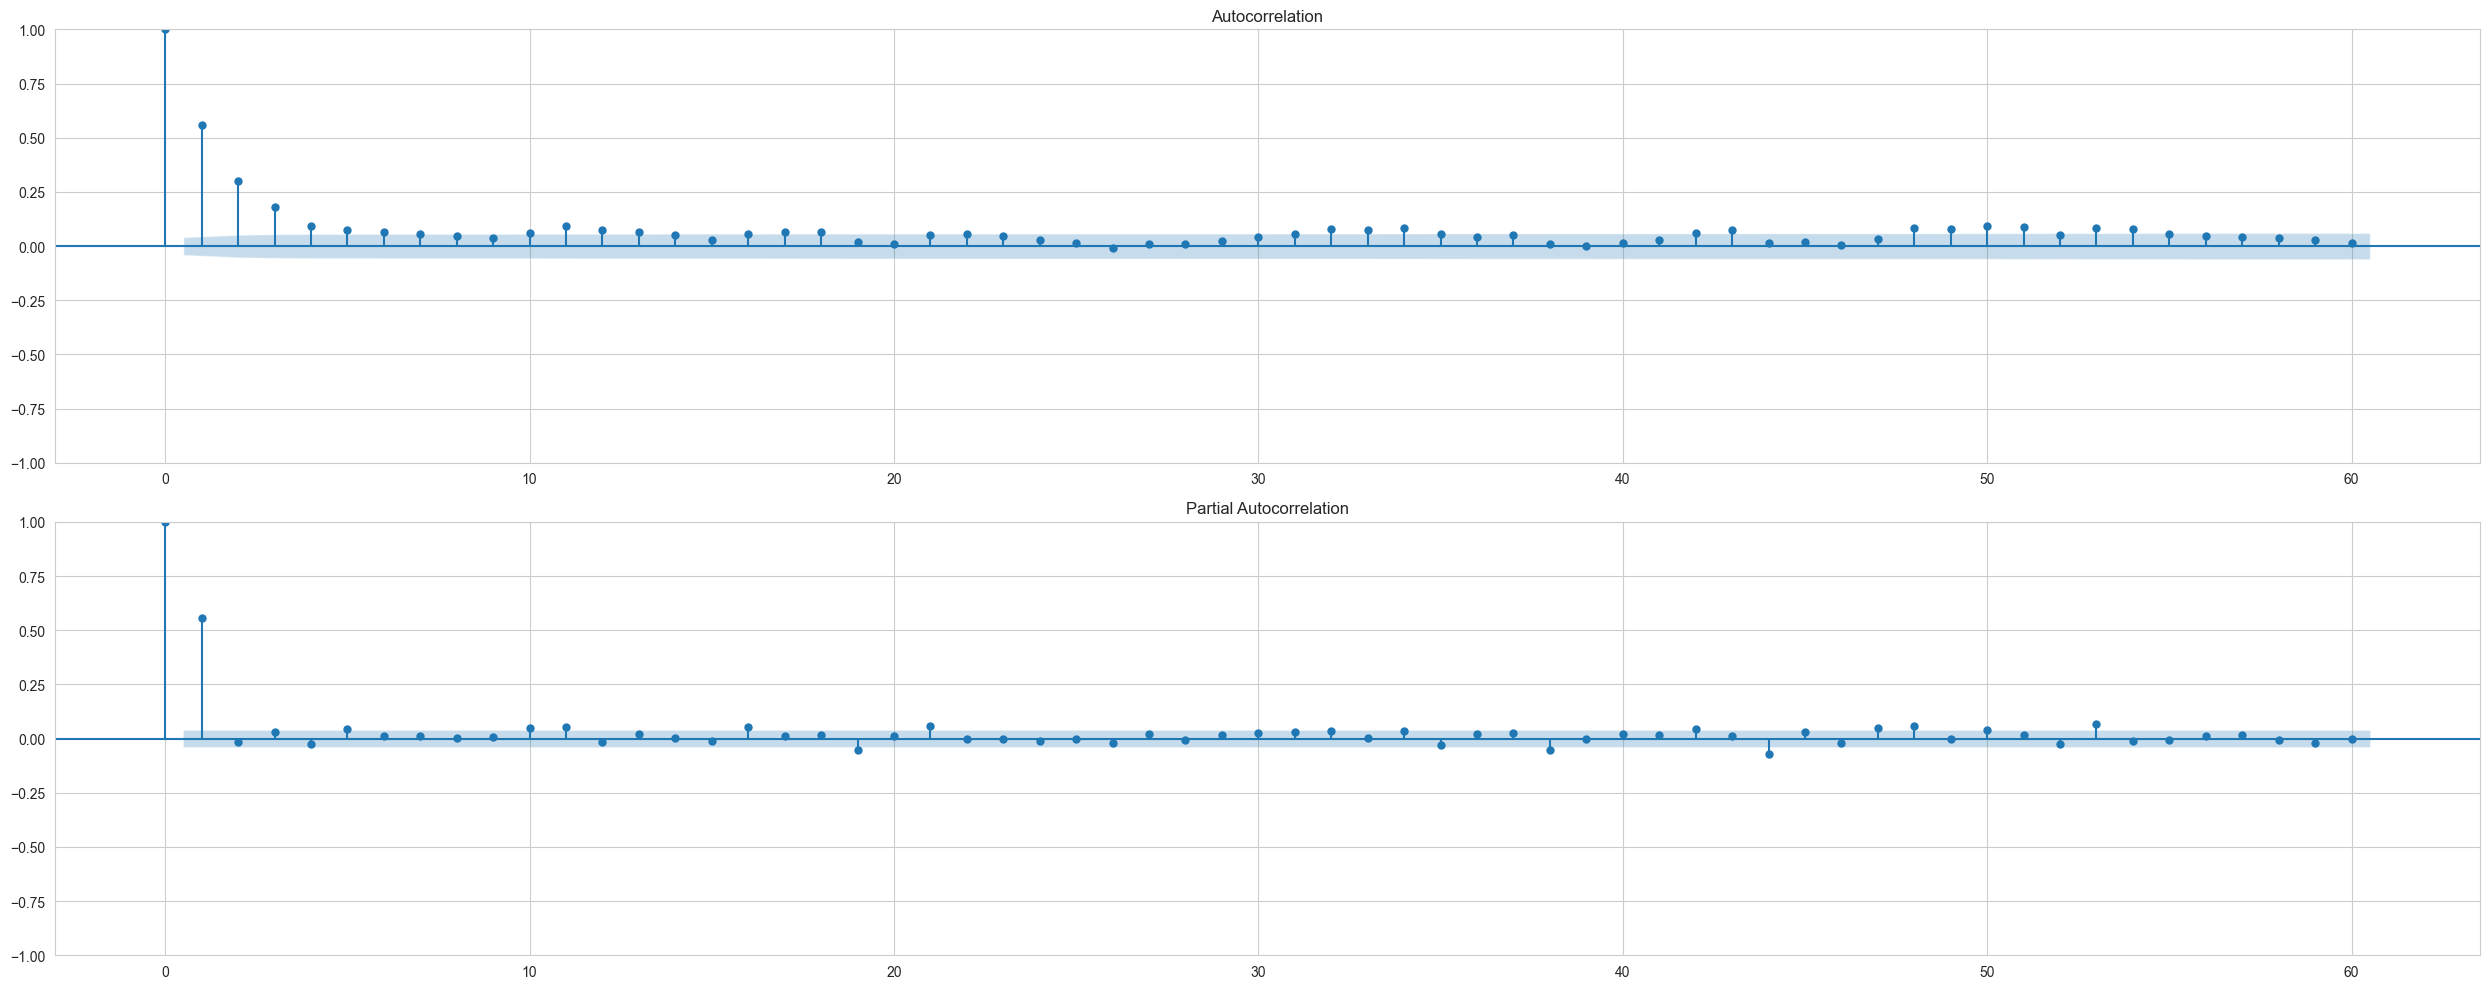

In [208]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(25, 10))
plot_acf(nmvoc_train['nmvoc_Seasonal_Diff'].dropna(), lags=60, ax=ax1)
plot_pacf(nmvoc_train['nmvoc_Seasonal_Diff'].dropna(), lags=60, ax=ax2)
plt.tight_layout()
plt.show()

In [209]:
model = auto_arima(nmvoc_train['nmvoc_Seasonal_Diff'].dropna(), 
                   stepwise=True, 
                   suppress_warnings=True, 
                   error_action="ignore", 
                   trace=True)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=5.25 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=12041.882, Time=0.15 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=11937.786, Time=0.37 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=11848.814, Time=0.40 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=12039.882, Time=0.13 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=1.38 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=11569.968, Time=1.13 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=2.47 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=11493.307, Time=1.86 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=4.76 sec
 ARIMA(0,1,4)(0,0,0)[0] intercept   : AIC=11451.113, Time=2.81 sec
 ARIMA(1,1,4)(0,0,0)[0] intercept   : AIC=inf, Time=6.06 sec
 ARIMA(0,1,5)(0,0,0)[0] intercept   : AIC=inf, Time=3.31 sec
 ARIMA(1,1,5)(0,0,0)[0] intercept   : AIC=11454.287, Time=3.63 sec
 ARIMA(0,1,4)(0,0,0)[0]             : AIC=11449.116, Ti

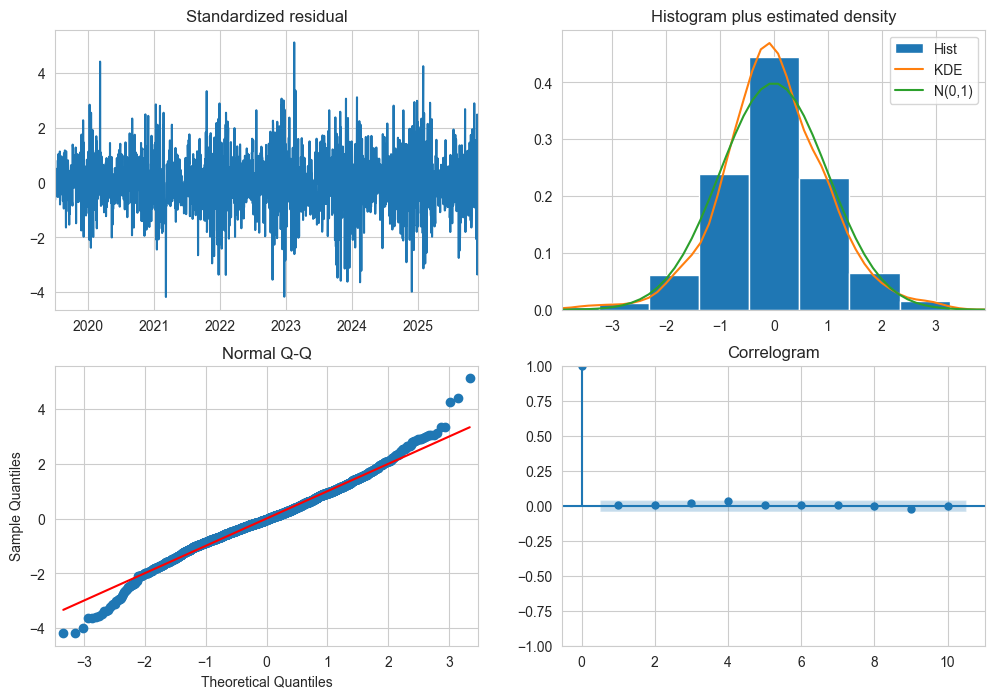

In [210]:
model.plot_diagnostics(figsize=(12, 8))
plt.show()

In [211]:
n = len(nmvoc_test)

# forecastingam diff erdveje
forecast_diff, conf_int = model.predict(n_periods=n, return_conf_int=True)

# atstatom tai ka pasalinom (y_t - y_{t-365}) + y_{t-365} = y_t
# base = nmvoc_train['nmvoc'].shift(365).iloc[-n:].values
base = nmvoc['nmvoc'].iloc[-365 - n : -365].values
forecast_real = forecast_diff + base

sarima_nmvoc = pd.Series(forecast_real, index=nmvoc_test.index)
conf_int_real = conf_int + base.reshape(-1, 1)

In [212]:
y_true = nmvoc_test['nmvoc']
y_pred = sarima_nmvoc

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

MSE: 25.08
MAE: 4.06
RMSE: 5.01
R²: -1.2912


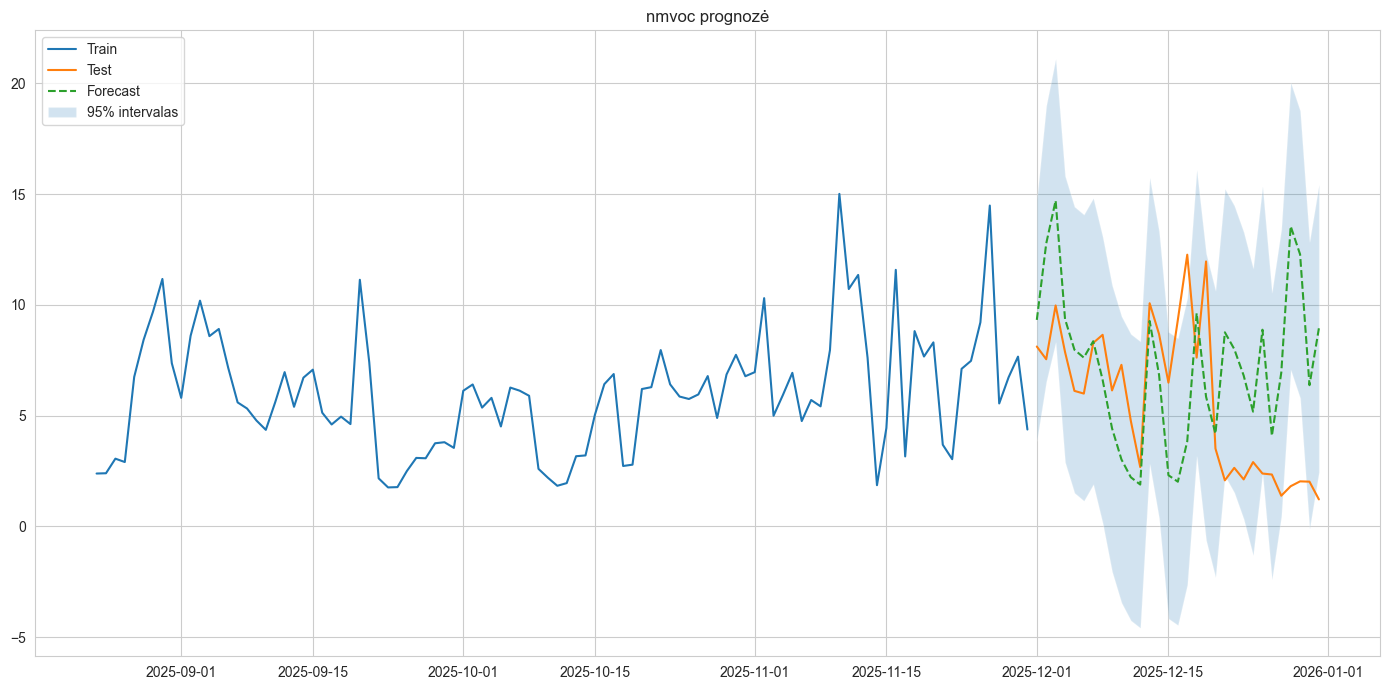

In [213]:
plt.figure(figsize=(14, 7))

plt.plot(nmvoc_train.tail(100).index, nmvoc_train.tail(100)['nmvoc'], label='Train')
plt.plot(nmvoc_test.index, nmvoc_test['nmvoc'], label='Test')
plt.plot(sarima_nmvoc.index, sarima_nmvoc, linestyle='--', label='Forecast')

plt.fill_between(nmvoc_test.index,
                 conf_int_real[:, 0],
                 conf_int_real[:, 1],
                 alpha=0.2,
                 label='95% intervalas')

plt.title('nmvoc prognozė')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### PANS

In [214]:
pans = pd.DataFrame(data_for_forecasting['pans'].dropna())
pans_train = pans.iloc[:-31]
pans_test = pans.iloc[-31:]

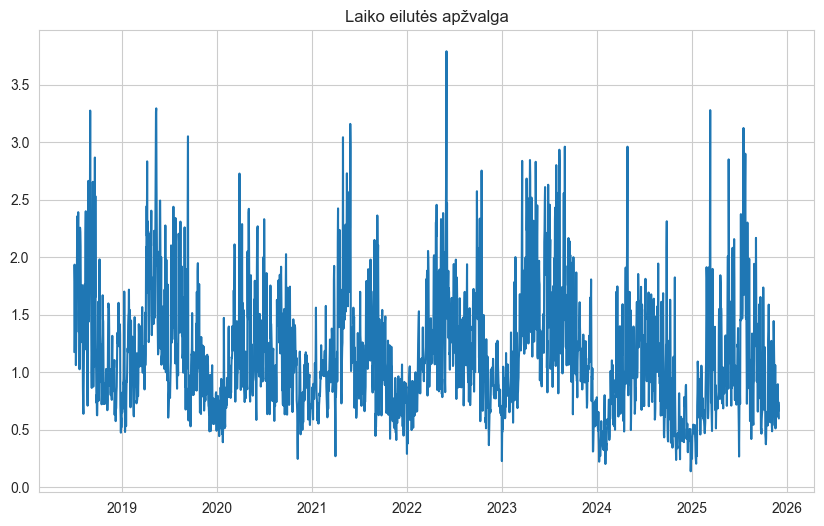

ADF Statistika: -5.29252220955296
p-reikšmė: 5.674364608090869e-06
--- KPSS Testo išvada ---
Statistika: 0.4074
p-reikšmė: 0.0740
duomenys stacionarus


In [215]:
plt.figure(figsize=(10, 6))
plt.plot(pans_train)
plt.title('Laiko eilutės apžvalga')
plt.show()

# ADF Testas
result = adfuller(pans_train)
print(f'ADF Statistika: {result[0]}')
print(f'p-reikšmė: {result[1]}')

kpss_test(pans_train)

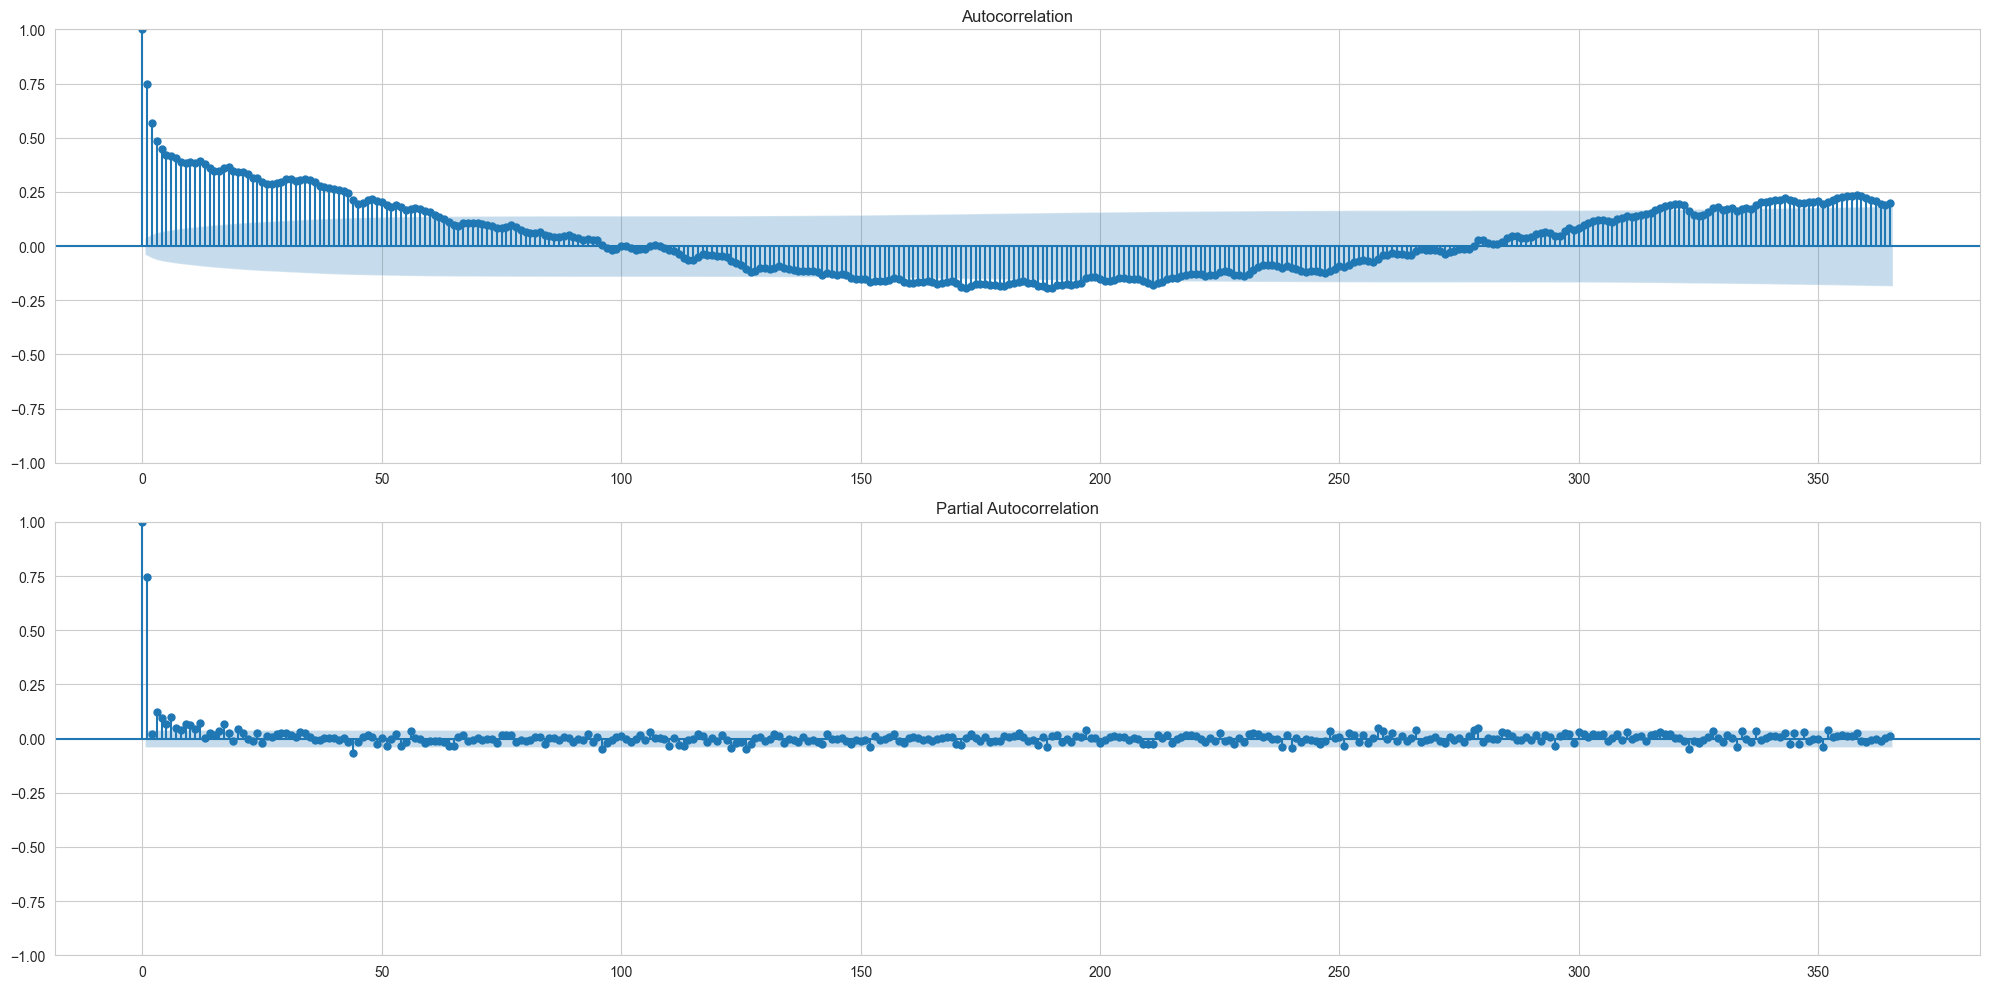

In [216]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10))
plot_acf(pans_train, lags=365, ax=ax1)
plot_pacf(pans_train, lags=365, ax=ax2)
plt.tight_layout()
plt.show()

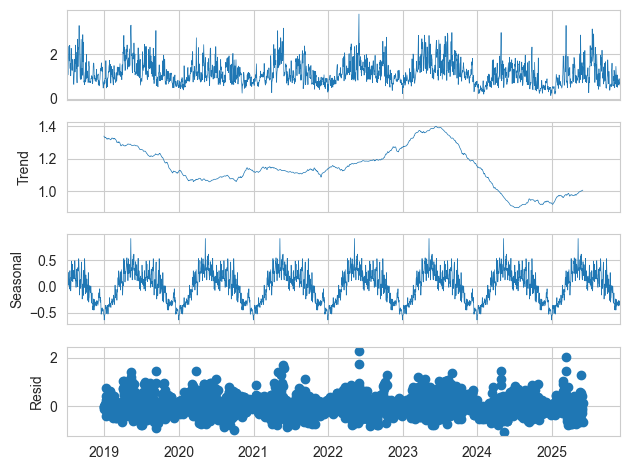

In [217]:
decomposition = seasonal_decompose(pans_train, model='additive', period=365)

fig = decomposition.plot()

for ax in fig.axes:
    for line in ax.get_lines():
        line.set_linewidth(0.5)

plt.show()

C:\Users\rugil\AppData\Local\Temp\ipykernel_13308\2822932444.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pans_train['pans_Seasonal_Diff'] = pans_train['pans'] - pans_train['pans'].shift(365)


ADF Statistic after Differencing: -7.4535
p-value after Seasonal Differencing: 0.0


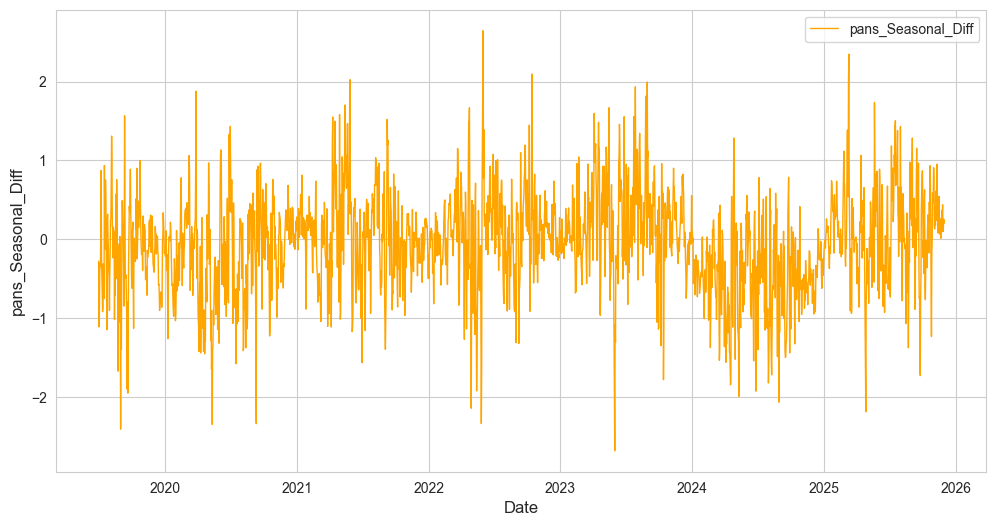

In [218]:
pans_train['pans_Seasonal_Diff'] = pans_train['pans'] - pans_train['pans'].shift(365) 

result_diff_seasonal = adfuller(pans_train['pans_Seasonal_Diff'].dropna())
print("ADF Statistic after Differencing:", result_diff_seasonal[0].round(4))
print("p-value after Seasonal Differencing:", result_diff_seasonal[1].round(4))


plt.figure(figsize=(12, 6))
plt.plot(pans_train.index, pans_train['pans_Seasonal_Diff'], label='pans_Seasonal_Diff', linewidth=1, color='orange')
plt.title('', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('pans_Seasonal_Diff', fontsize=12)
plt.grid(True)
plt.legend()
plt.show()

In [219]:
model = auto_arima(pans_train['pans_Seasonal_Diff'].dropna(), 
                   stepwise=True, 
                   suppress_warnings=True, 
                   error_action="ignore", 
                   trace=True)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=2996.316, Time=4.13 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=3460.358, Time=0.74 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=3413.697, Time=0.45 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=3374.807, Time=1.19 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=3458.358, Time=0.21 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=2986.362, Time=3.17 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=3136.636, Time=1.17 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=2995.027, Time=3.95 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=2988.268, Time=4.63 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=3025.086, Time=2.24 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=2986.797, Time=3.22 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=2986.551, Time=6.70 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=2984.493, Time=0.82 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=3134.654, Time=0.45 sec
 ARIMA(1,1,1)(0,0,0)[0]          

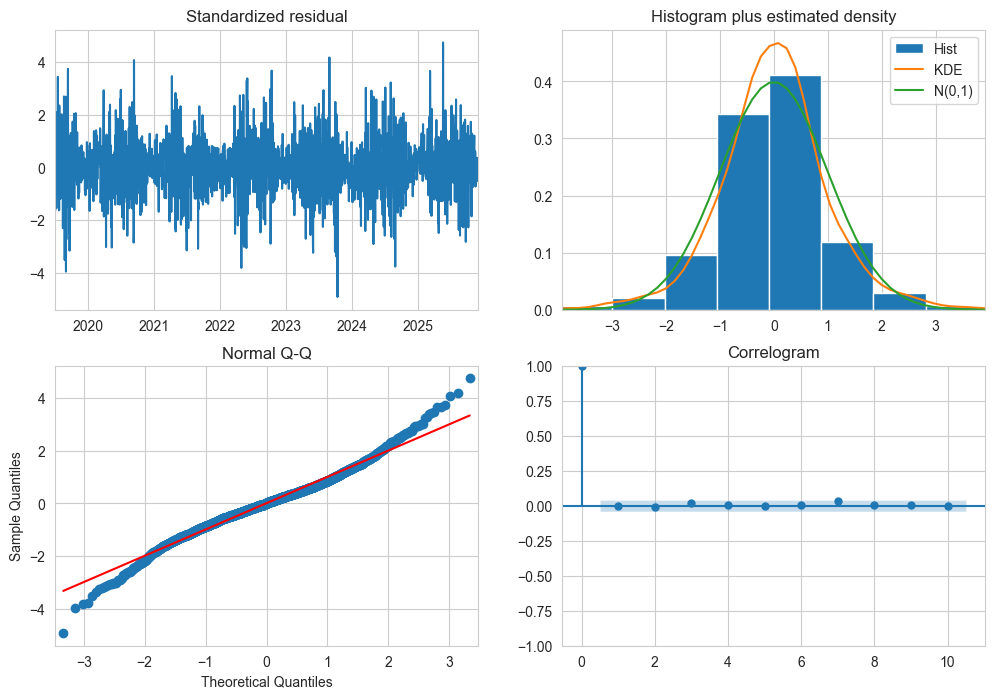

In [220]:
model.plot_diagnostics(figsize=(12, 8))
plt.show()

In [221]:
n = len(pans_test)

# forecastingam diff erdveje
forecast_diff, conf_int = model.predict(n_periods=n, return_conf_int=True)

# atstatom tai ka pasalinom (y_t - y_{t-365}) + y_{t-365} = y_t
# base = pans_train['pans'].shift(365).iloc[-n:].values
base = pans['pans'].iloc[-365 - n : -365].values
forecast_real = forecast_diff + base

sarima_pans = pd.Series(forecast_real, index=pans_test.index)
conf_int_real = conf_int + base.reshape(-1, 1)

In [222]:
y_true = pans_test['pans']
y_pred = sarima_pans

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:}")
print(f"R²: {r2:.4f}")

MSE: 0.06
MAE: 0.20
RMSE: 0.24335616525469542
R²: -0.4422


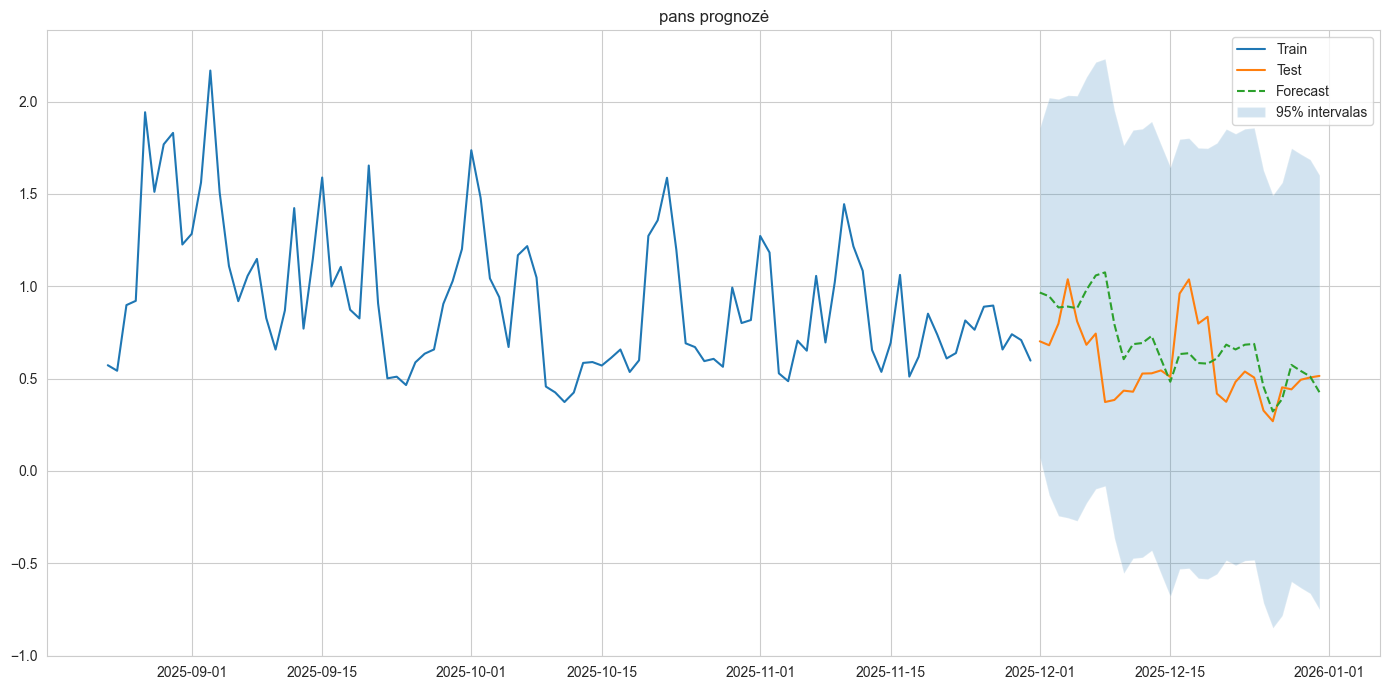

In [223]:
plt.figure(figsize=(14, 7))

plt.plot(pans_train.tail(100).index, pans_train.tail(100)['pans'], label='Train')
plt.plot(pans_test.index, pans_test['pans'], label='Test')
plt.plot(sarima_pans.index, sarima_pans, linestyle='--', label='Forecast')

plt.fill_between(pans_test.index,
                 conf_int_real[:, 0],
                 conf_int_real[:, 1],
                 alpha=0.2,
                 label='95% intervalas')

plt.title('pans prognozė')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### PM2P5

In [224]:
pm2p5 = pd.DataFrame(data_for_forecasting['pm2p5'].dropna())
pm2p5_train = pm2p5.iloc[:-31]
pm2p5_test = pm2p5.iloc[-31:]

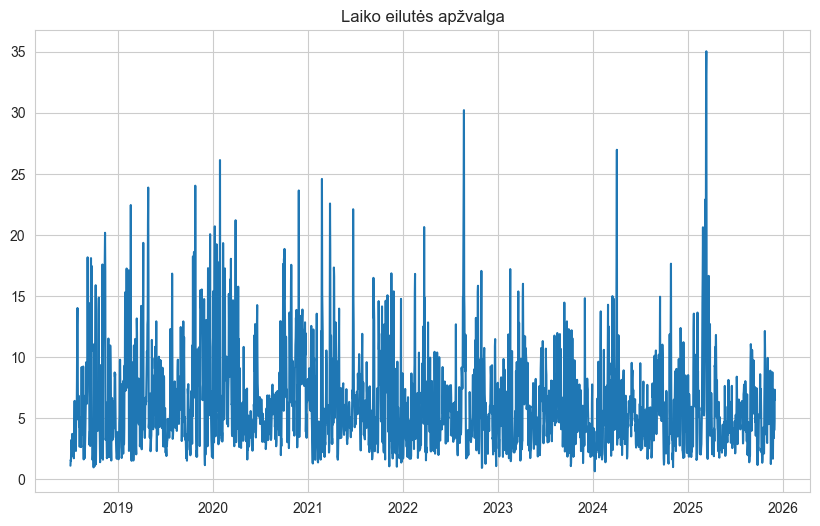

ADF Statistika: -11.79774609106479
p-reikšmė: 9.49001220908754e-22
--- KPSS Testo išvada ---
Statistika: 1.2080
p-reikšmė: 0.0100
duomenys nestacionarus


C:\Users\rugil\AppData\Local\Temp\ipykernel_13308\1366889094.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, p_value, lags, critical_values = kpss(timeseries, regression='c', nlags="auto")


In [225]:
plt.figure(figsize=(10, 6))
plt.plot(pm2p5_train)
plt.title('Laiko eilutės apžvalga')
plt.show()

# ADF Testas
result = adfuller(pm2p5_train)
print(f'ADF Statistika: {result[0]}')
print(f'p-reikšmė: {result[1]}')

kpss_test(pm2p5_train)

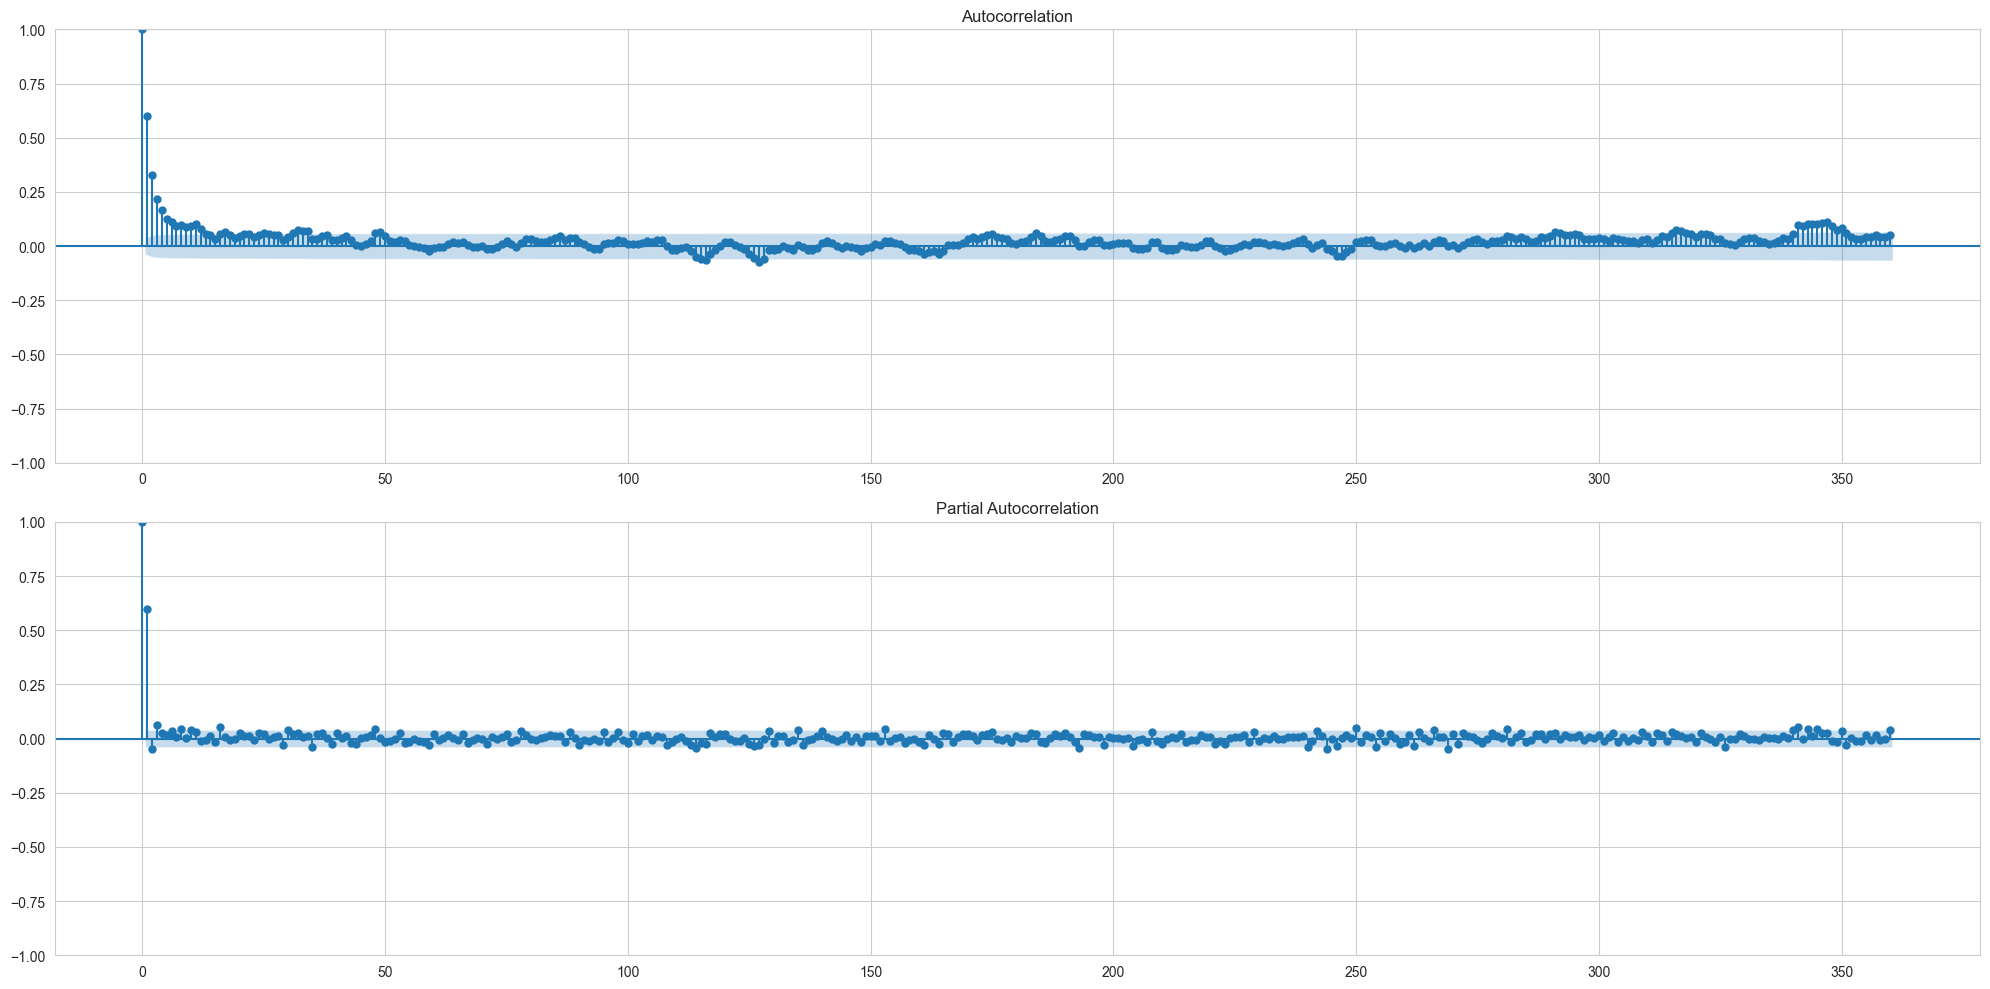

In [226]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10))
plot_acf(pm2p5_train, lags=360, ax=ax1)
plot_pacf(pm2p5_train, lags=360, ax=ax2)
plt.tight_layout()
plt.show()

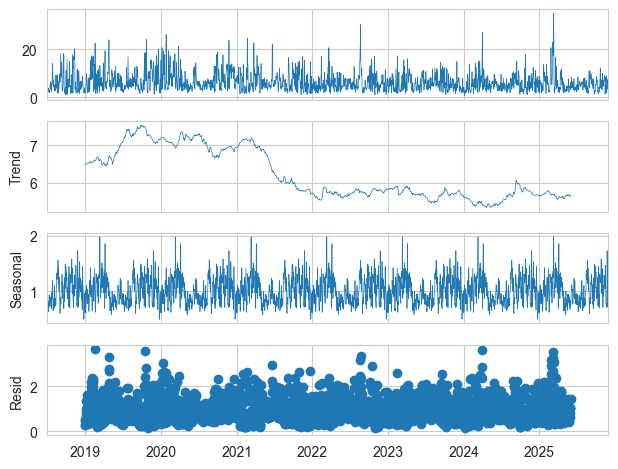

In [227]:
decomposition = seasonal_decompose(pm2p5_train, model='multiplicative', period=365)

fig = decomposition.plot()

for ax in fig.axes:
    for line in ax.get_lines():
        line.set_linewidth(0.5)

plt.show()

C:\Users\rugil\AppData\Local\Temp\ipykernel_13308\1521195918.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pm2p5_train['pm2p5_Seasonal_Diff'] = pm2p5_train['pm2p5'] - pm2p5_train['pm2p5'].shift(365)


ADF Statistic after Differencing: -20.9521
p-value after Seasonal Differencing: 0.0


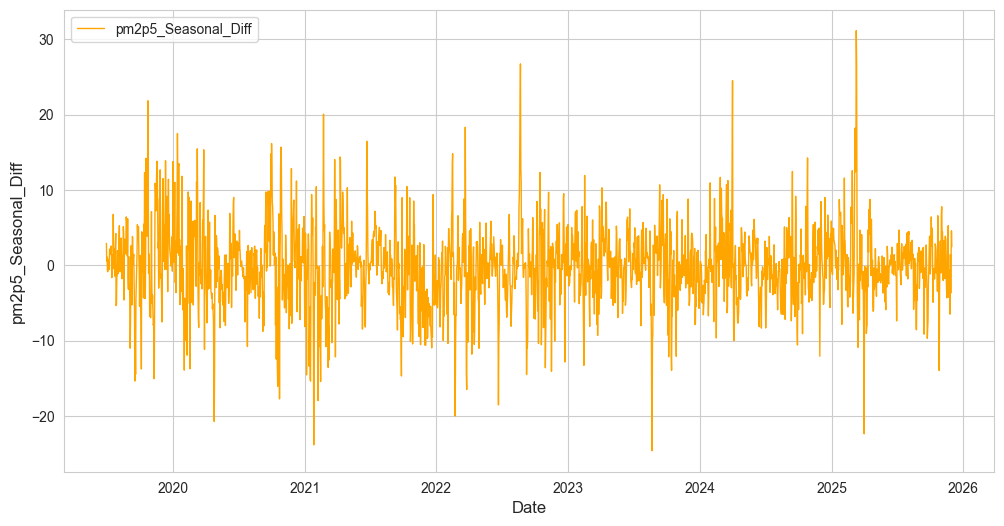

In [228]:
pm2p5_train['pm2p5_Seasonal_Diff'] = pm2p5_train['pm2p5'] - pm2p5_train['pm2p5'].shift(365) 

result_diff_seasonal = adfuller(pm2p5_train['pm2p5_Seasonal_Diff'].dropna())
print("ADF Statistic after Differencing:", result_diff_seasonal[0].round(4))
print("p-value after Seasonal Differencing:", result_diff_seasonal[1])


plt.figure(figsize=(12, 6))
plt.plot(pm2p5_train.index, pm2p5_train['pm2p5_Seasonal_Diff'], label='pm2p5_Seasonal_Diff', linewidth=1, color='orange')
plt.xlabel('Date', fontsize=12)
plt.ylabel('pm2p5_Seasonal_Diff', fontsize=12)
plt.grid(True)
plt.legend()
plt.show()

In [229]:
model = auto_arima(pm2p5_train['pm2p5_Seasonal_Diff'].dropna(), 
                   stepwise=True, 
                   suppress_warnings=True, 
                   error_action="ignore", 
                   trace=True)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=13445.336, Time=2.94 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=14385.175, Time=0.11 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=13466.225, Time=0.27 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=13588.795, Time=0.74 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=14384.601, Time=0.09 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=13445.084, Time=1.16 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=13476.415, Time=0.94 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=13444.684, Time=0.64 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=13445.639, Time=1.19 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=13447.632, Time=0.50 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=13443.133, Time=0.22 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=13587.644, Time=0.24 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=13464.597, Time=0.12 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=13444.074, Time=0.49 sec
 ARIMA(1,0,2)(0,0,0

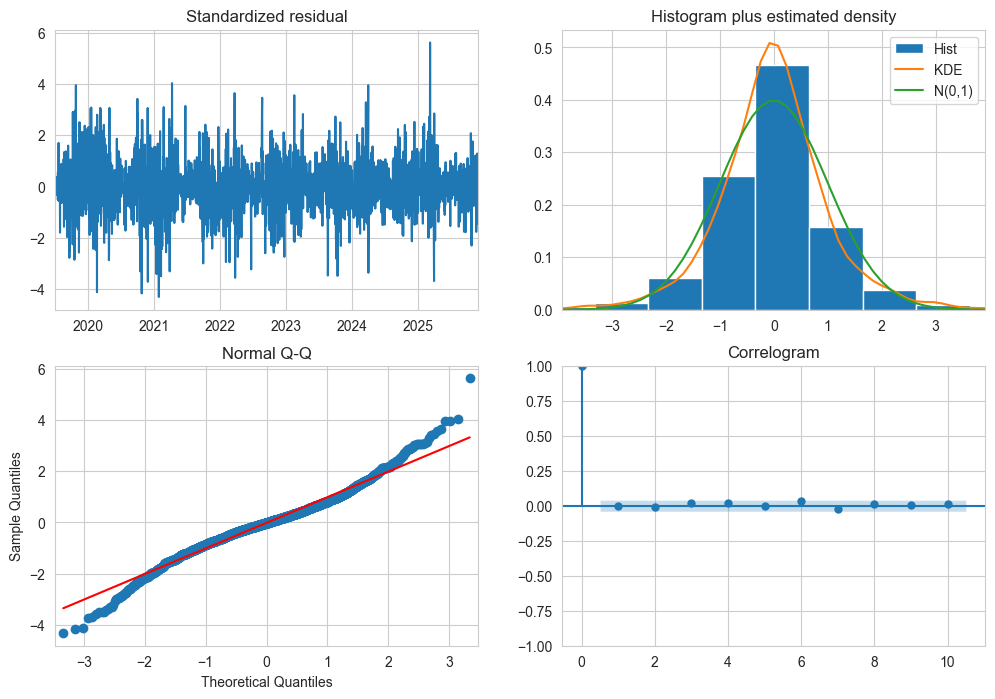

In [230]:
model.plot_diagnostics(figsize=(12, 8))
plt.show()

In [231]:
n = len(pm2p5_test)

# forecastingam diff erdveje
forecast_diff, conf_int = model.predict(n_periods=n, return_conf_int=True)

# atstatom tai ka pasalinom (y_t - y_{t-365}) + y_{t-365} = y_t
# base = pm2p5_train['pm2p5'].shift(365).iloc[-n:].values
base = pm2p5['pm2p5'].iloc[-365 - n : -365].values
forecast_real = forecast_diff + base

sarima_pm2p5 = pd.Series(forecast_real, index=pm2p5_test.index)
conf_int_real = conf_int + base.reshape(-1, 1)

In [232]:
y_true = pm2p5_test['pm2p5']
y_pred = sarima_pm2p5

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:}")
print(f"R²: {r2:.4f}")

MSE: 18.52
MAE: 3.40
RMSE: 4.303163705056684
R²: -0.8362


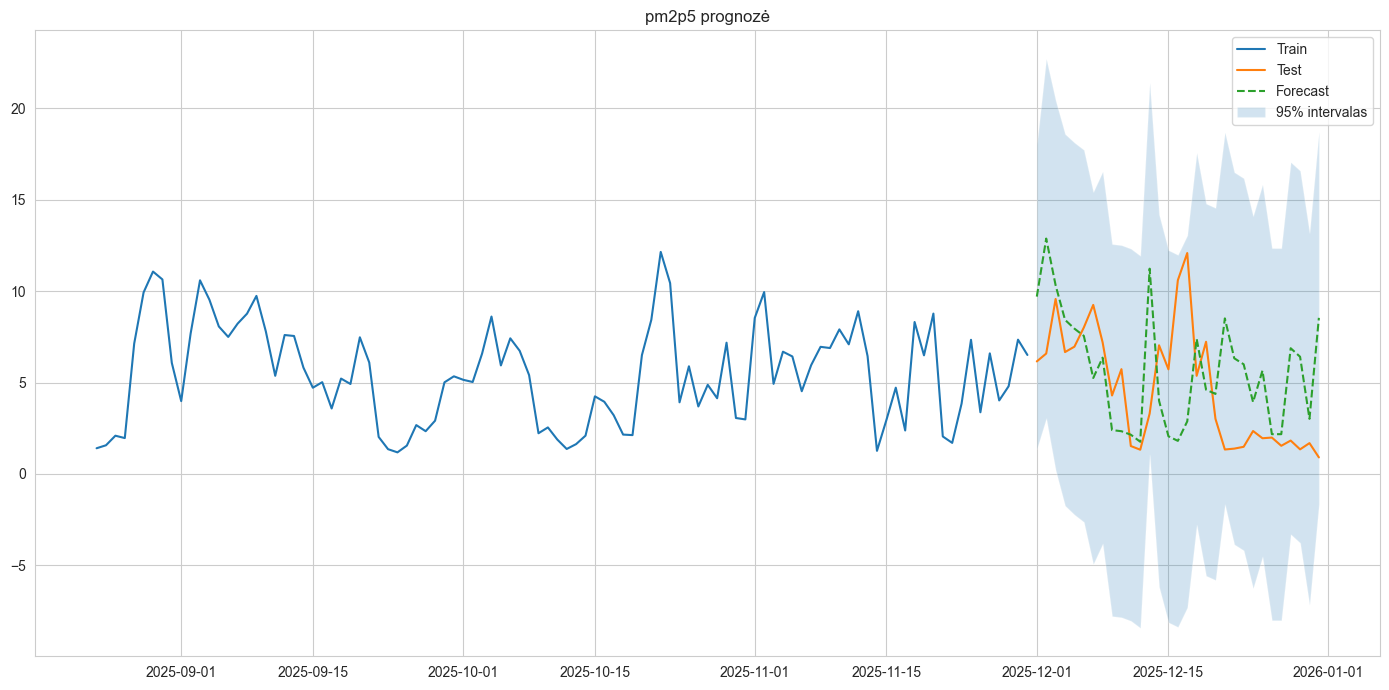

In [233]:
plt.figure(figsize=(14, 7))

plt.plot(pm2p5_train.tail(100).index, pm2p5_train.tail(100)['pm2p5'], label='Train')
plt.plot(pm2p5_test.index, pm2p5_test['pm2p5'], label='Test')
plt.plot(sarima_pm2p5.index, sarima_pm2p5, linestyle='--', label='Forecast')

plt.fill_between(pm2p5_test.index,
                 conf_int_real[:, 0],
                 conf_int_real[:, 1],
                 alpha=0.2,
                 label='95% intervalas')

plt.title('pm2p5 prognozė')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### SIA

In [234]:
sia = pd.DataFrame(data_for_forecasting['sia'].dropna())
sia_train = sia.iloc[:-31]
sia_test = sia.iloc[-31:]

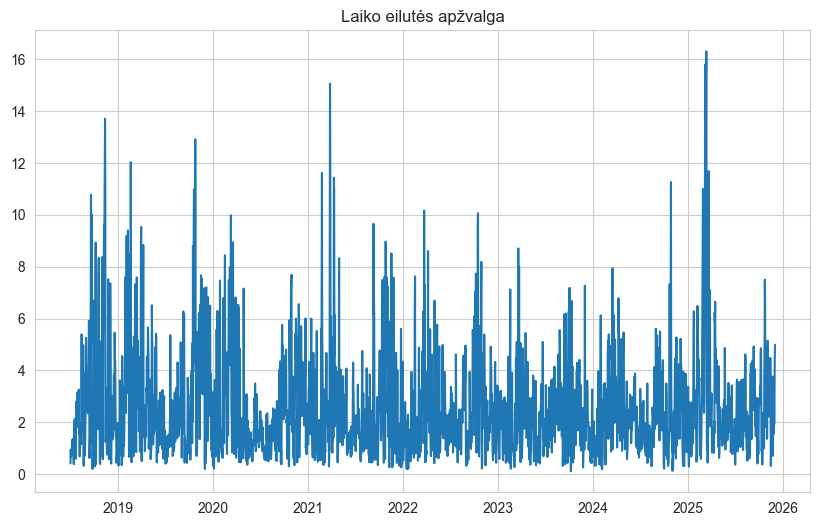

ADF Statistika: -8.992722566459156
p-reikšmė: 6.822839401973413e-15
--- KPSS Testo išvada ---
Statistika: 0.3258
p-reikšmė: 0.1000
duomenys stacionarus


C:\Users\rugil\AppData\Local\Temp\ipykernel_13308\1366889094.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p_value, lags, critical_values = kpss(timeseries, regression='c', nlags="auto")


In [235]:
plt.figure(figsize=(10, 6))
plt.plot(sia_train)
plt.title('Laiko eilutės apžvalga')
plt.show()

# ADF Testas
result = adfuller(sia_train)
print(f'ADF Statistika: {result[0]}')
print(f'p-reikšmė: {result[1]}')

kpss_test(sia_train)

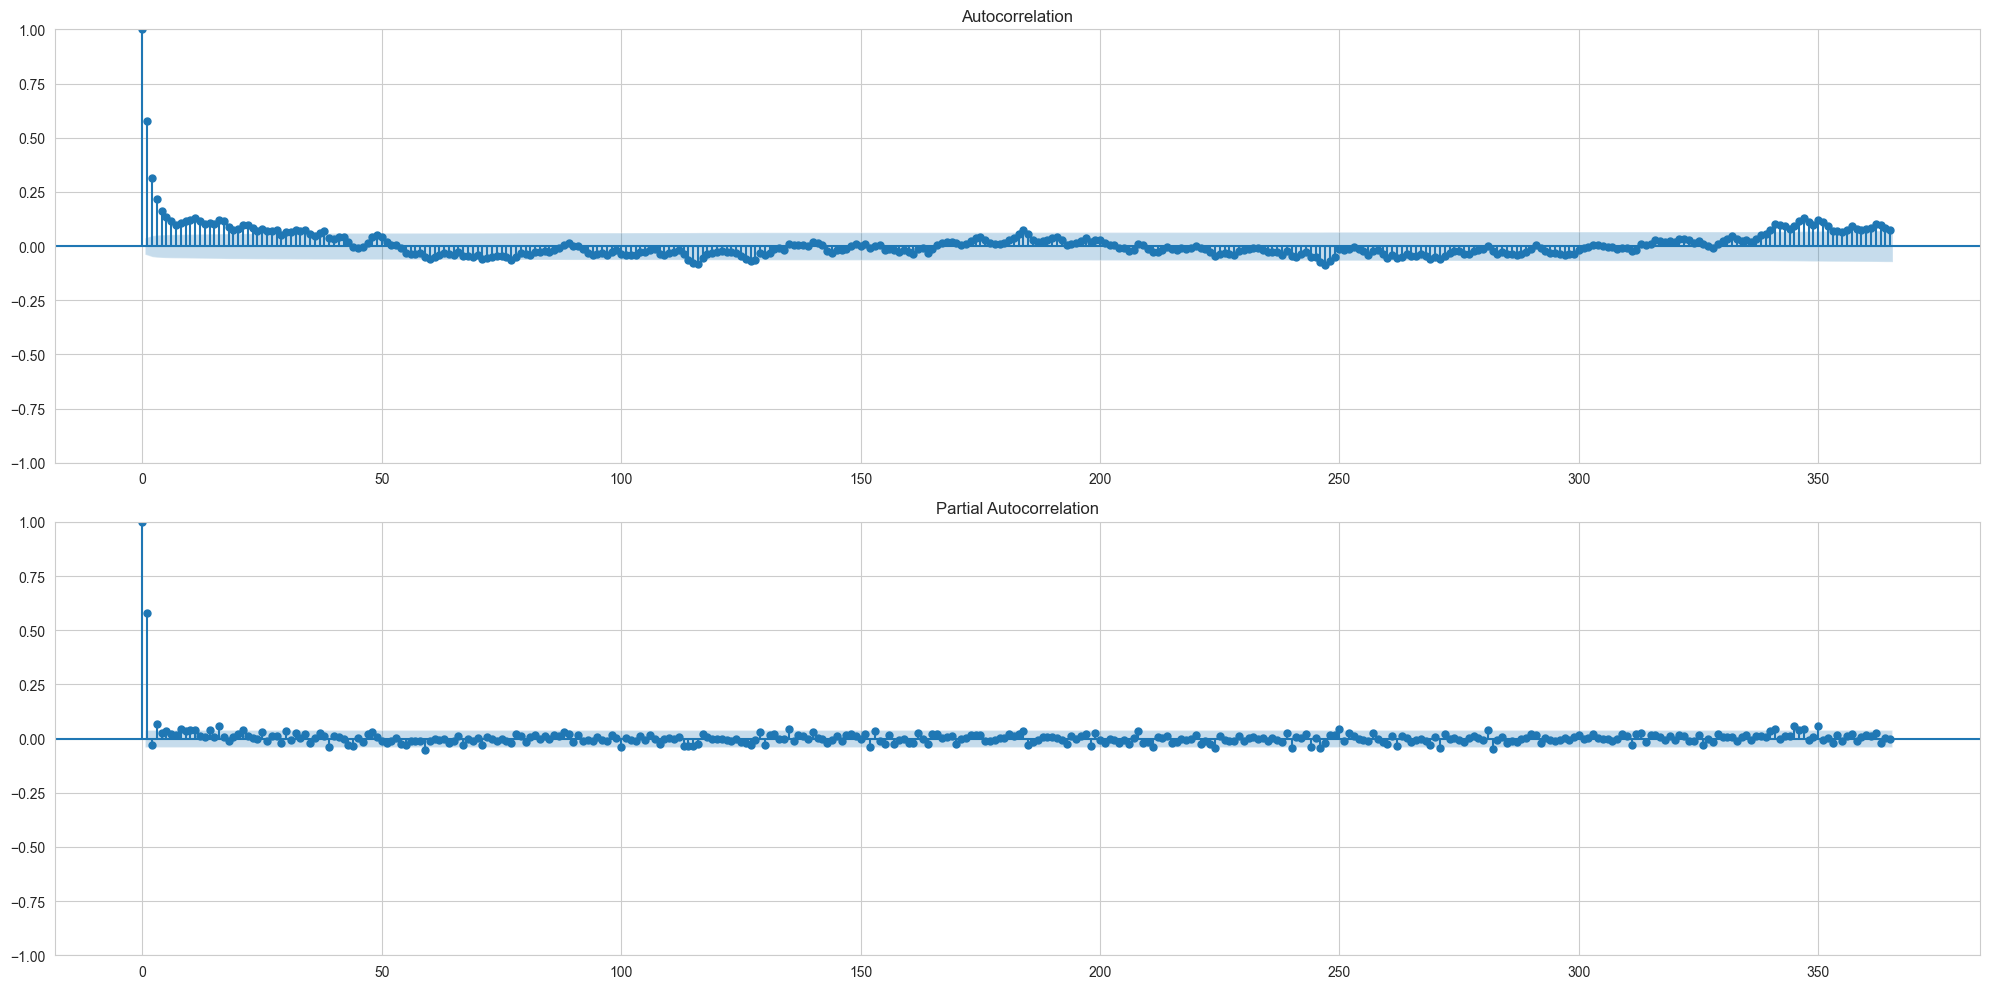

In [236]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10))
plot_acf(sia_train, lags=365, ax=ax1)
plot_pacf(sia_train, lags=365, ax=ax2)
plt.tight_layout()
plt.show()

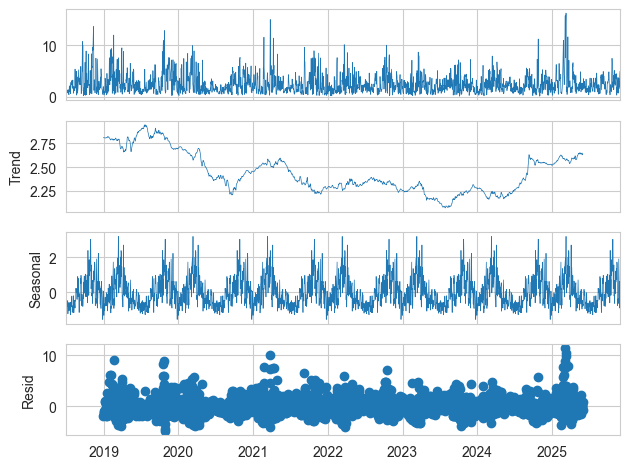

In [237]:
decomposition = seasonal_decompose(sia_train, model='additive', period=365)

fig = decomposition.plot()

for ax in fig.axes:
    for line in ax.get_lines():
        line.set_linewidth(0.5)

plt.show()

C:\Users\rugil\AppData\Local\Temp\ipykernel_13308\2150229463.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sia_train['sia_Seasonal_Diff'] = sia_train['sia'] - sia_train['sia'].shift(365)


ADF Statistic after Differencing: -25.9984
p-value after Seasonal Differencing: 0.0


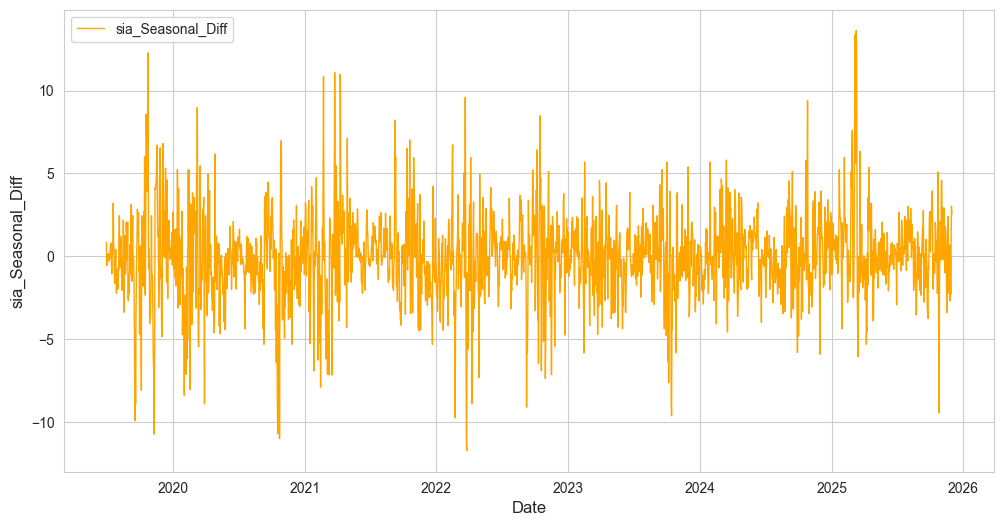

In [238]:
sia_train['sia_Seasonal_Diff'] = sia_train['sia'] - sia_train['sia'].shift(365) 

result_diff_seasonal = adfuller(sia_train['sia_Seasonal_Diff'].dropna())
print("ADF Statistic after Differencing:", result_diff_seasonal[0].round(4))
print("p-value after Seasonal Differencing:", result_diff_seasonal[1])


plt.figure(figsize=(12, 6))
plt.plot(sia_train.index, sia_train['sia_Seasonal_Diff'], label='sia_Seasonal_Diff', linewidth=1, color='orange')
plt.title('', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('sia_Seasonal_Diff', fontsize=12)
plt.grid(True)
plt.legend()
plt.show()

In [239]:
model = auto_arima(sia_train['sia_Seasonal_Diff'].dropna(), 
                   stepwise=True, 
                   suppress_warnings=True, 
                   error_action="ignore", 
                   trace=True)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=10256.610, Time=1.16 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=11016.768, Time=0.11 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=10273.812, Time=0.35 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=10342.117, Time=0.56 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=11014.995, Time=0.07 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=10254.610, Time=0.82 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=10268.371, Time=0.70 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=10252.900, Time=0.52 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=10254.617, Time=1.19 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=10254.649, Time=0.48 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=10250.977, Time=0.28 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=10340.247, Time=0.22 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=10271.875, Time=0.12 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=10252.691, Time=0.52 sec
 ARIMA(1,0,2)(0,0,0

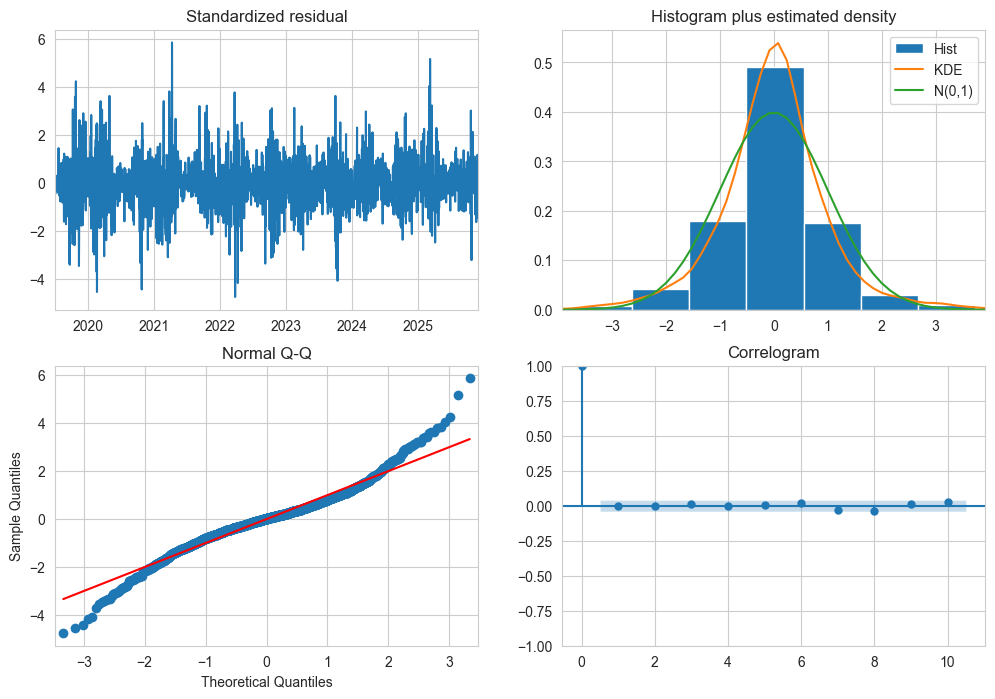

In [240]:
model.plot_diagnostics(figsize=(12, 8))
plt.show()

In [241]:
n = len(sia_test)

# forecastingam diff erdveje
forecast_diff, conf_int = model.predict(n_periods=n, return_conf_int=True)

# atstatom tai ka pasalinom (y_t - y_{t-365}) + y_{t-365} = y_t
# base = pans_train['pans'].shift(365).iloc[-n:].values
base = sia['sia'].iloc[-365 - n : -365].values
forecast_real = forecast_diff + base

sarima_sia = pd.Series(forecast_real, index=sia_test.index)
conf_int_real = conf_int + base.reshape(-1, 1)

In [242]:
y_true = sia_test['sia']
y_pred = sarima_sia 

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:}")
print(f"R²: {r2:.4f}")

MSE: 3.73
MAE: 1.51
RMSE: 1.9310132727797353
R²: -0.2810


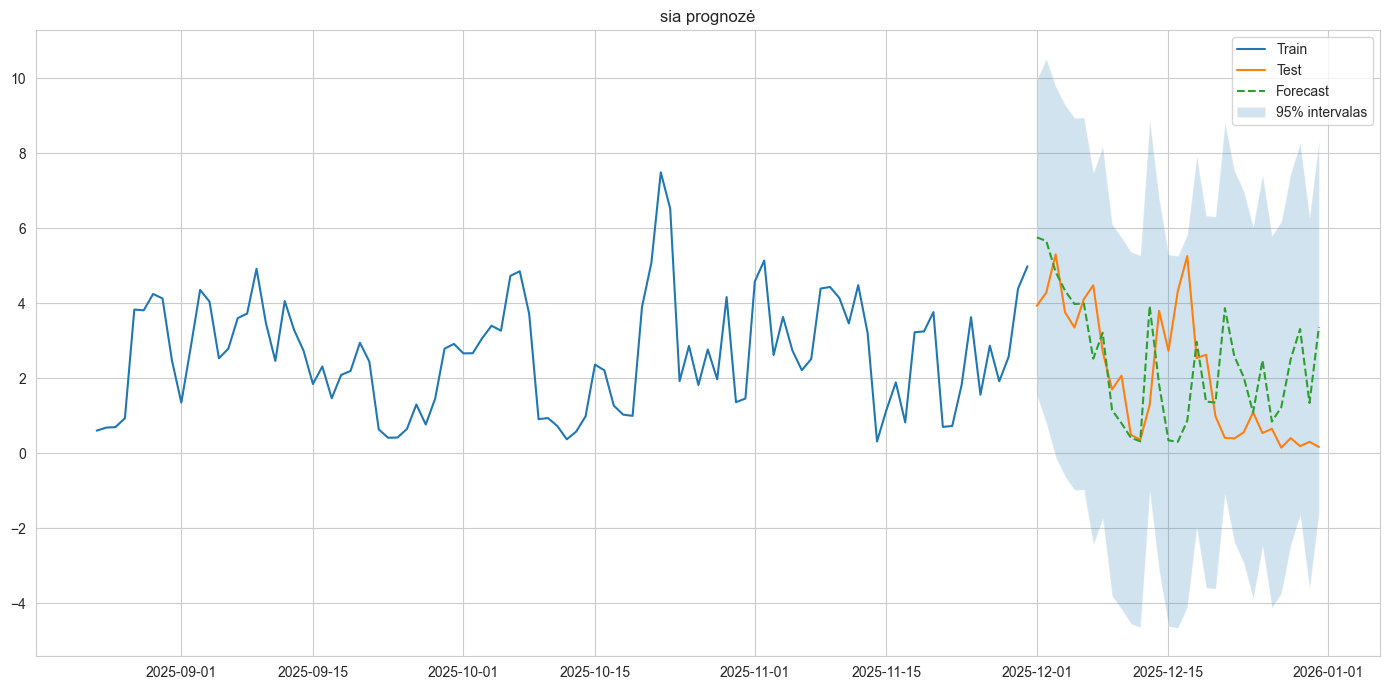

In [243]:
plt.figure(figsize=(14, 7))

plt.plot(sia_train.tail(100).index, sia_train.tail(100)['sia'], label='Train')
plt.plot(sia_test.index, sia_test['sia'], label='Test')
plt.plot(sarima_sia.index, sarima_sia , linestyle='--', label='Forecast')

plt.fill_between(sia_test.index,
                 conf_int_real[:, 0],
                 conf_int_real[:, 1],
                 alpha=0.2,
                 label='95% intervalas')

plt.title('sia prognozė')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### DUST

In [244]:
dust = pd.DataFrame(data_for_forecasting['dust'].dropna())
dust_train = dust.iloc[:-31]
dust_test = dust.iloc[-31:]

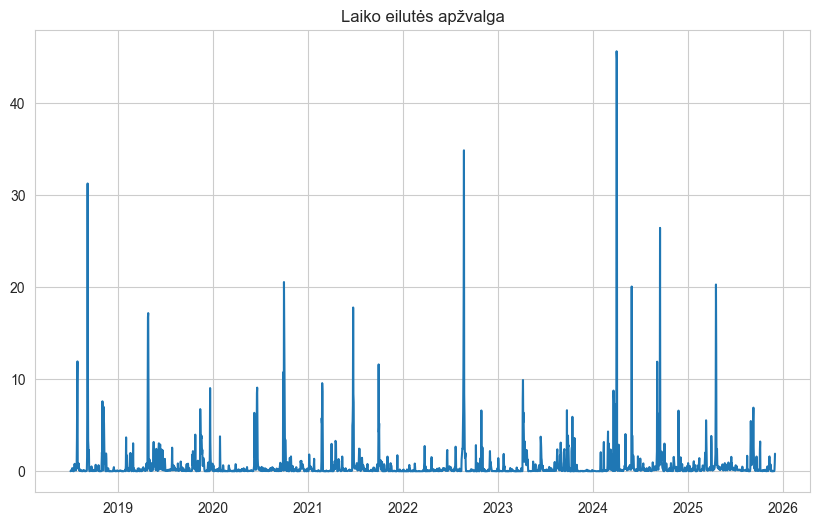

ADF Statistika: -22.00047920189739
p-reikšmė: 0.0
--- KPSS Testo išvada ---
Statistika: 0.0534
p-reikšmė: 0.1000
duomenys stacionarus


C:\Users\rugil\AppData\Local\Temp\ipykernel_13308\1366889094.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p_value, lags, critical_values = kpss(timeseries, regression='c', nlags="auto")


In [245]:
plt.figure(figsize=(10, 6))
plt.plot(dust_train)
plt.title('Laiko eilutės apžvalga')
plt.show()

# ADF Testas
result = adfuller(dust_train)
print(f'ADF Statistika: {result[0]}')
print(f'p-reikšmė: {result[1]}')

kpss_test(dust_train)

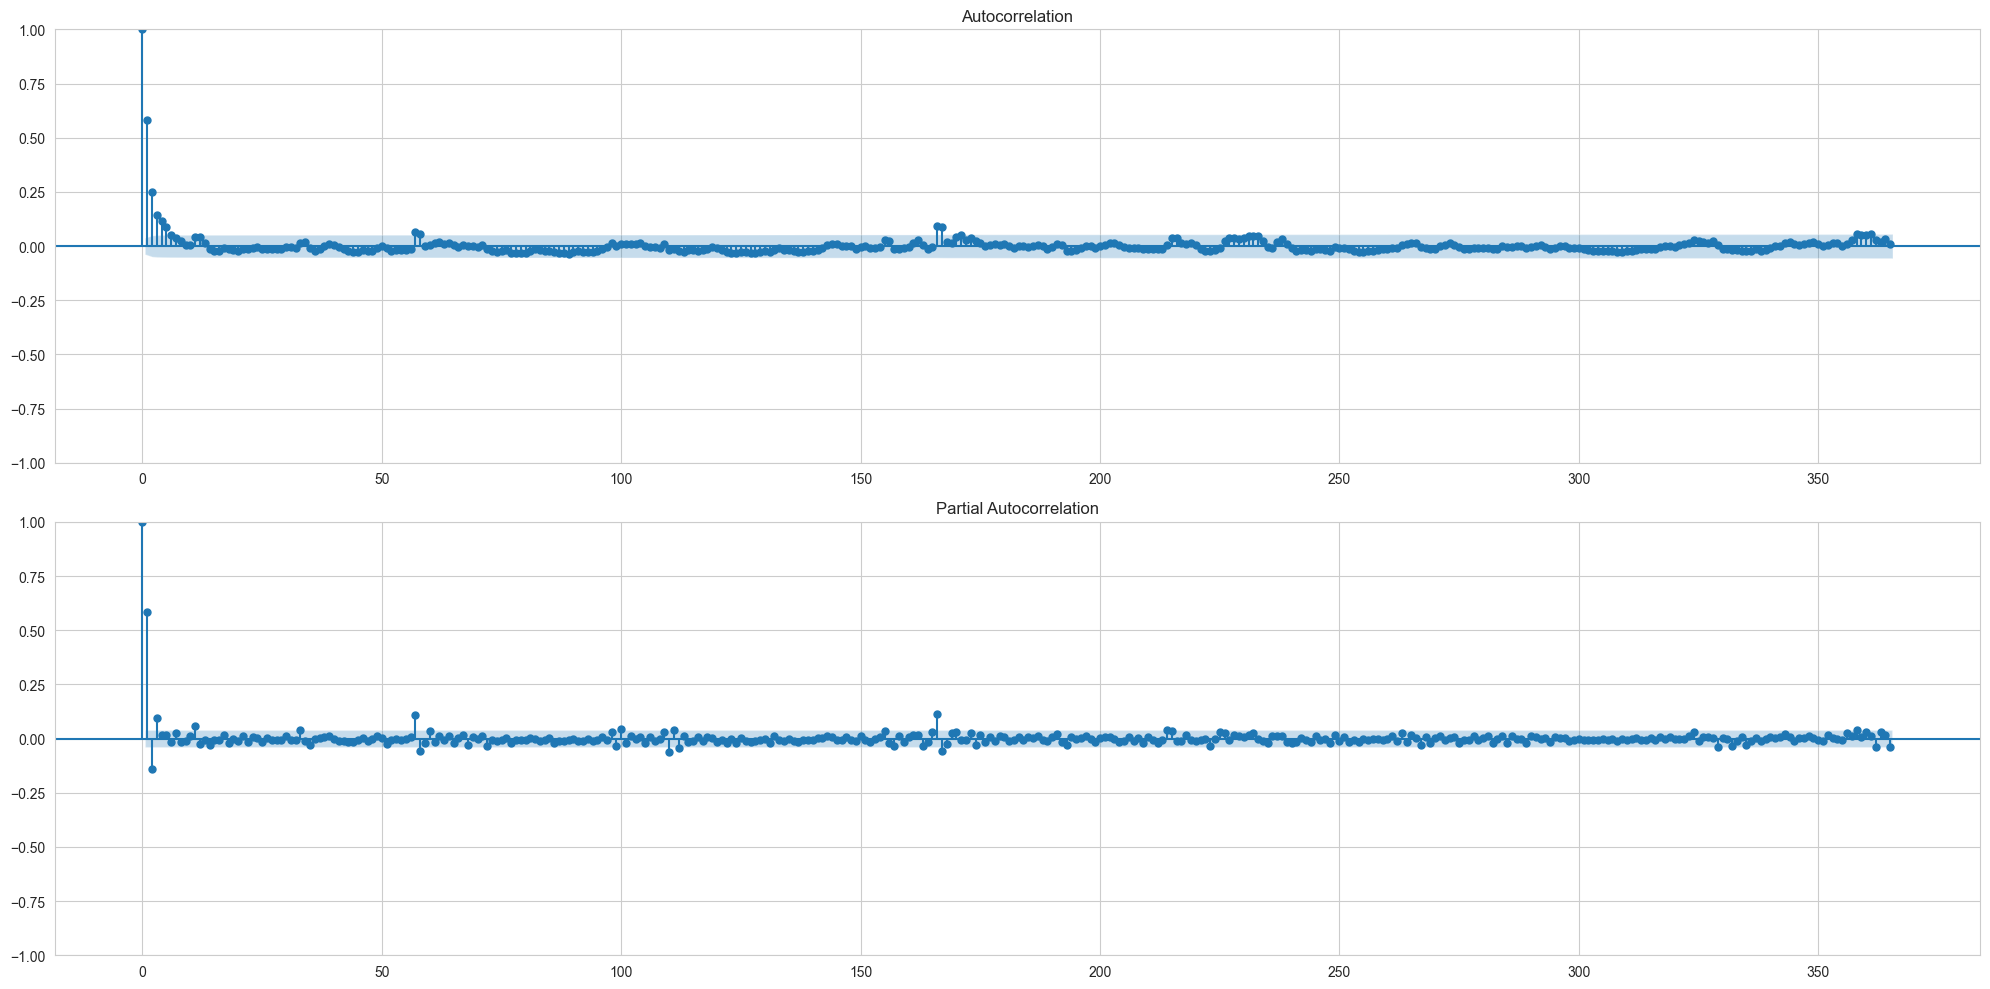

In [246]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10))
plot_acf(dust_train, lags=365, ax=ax1)
plot_pacf(dust_train, lags=365, ax=ax2)
plt.tight_layout()
plt.show()

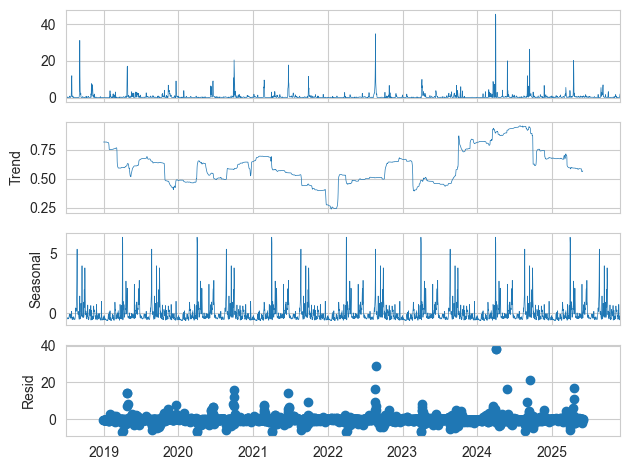

In [247]:
decomposition = seasonal_decompose(dust_train, model='additive', period=365)

fig = decomposition.plot()

for ax in fig.axes:
    for line in ax.get_lines():
        line.set_linewidth(0.5)

plt.show()

C:\Users\rugil\AppData\Local\Temp\ipykernel_13308\4080210242.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dust_train['dust_Seasonal_Diff'] = dust_train['dust'] - dust_train['dust'].shift(365)


ADF Statistic after Differencing: -21.1138
p-value after Seasonal Differencing: 0.0


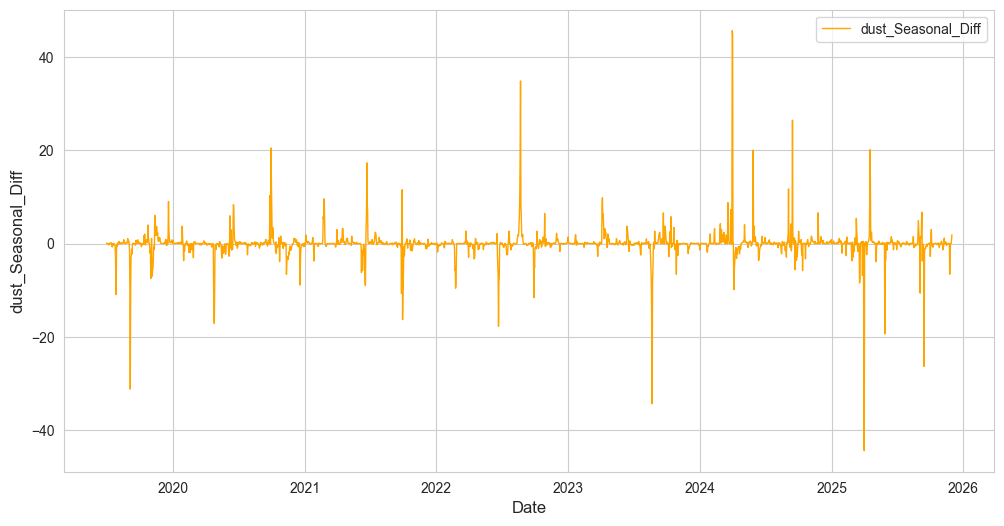

In [248]:
dust_train['dust_Seasonal_Diff'] = dust_train['dust'] - dust_train['dust'].shift(365) 

result_diff_seasonal = adfuller(dust_train['dust_Seasonal_Diff'].dropna())
print("ADF Statistic after Differencing:", result_diff_seasonal[0].round(4))
print("p-value after Seasonal Differencing:", result_diff_seasonal[1])


plt.figure(figsize=(12, 6))
plt.plot(dust_train.index, dust_train['dust_Seasonal_Diff'], label='dust_Seasonal_Diff', linewidth=1, color='orange')
plt.title('', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('dust_Seasonal_Diff', fontsize=12)
plt.grid(True)
plt.legend()
plt.show()

In [249]:
model = auto_arima(dust_train['dust_Seasonal_Diff'].dropna(), 
                   stepwise=True, 
                   suppress_warnings=True, 
                   error_action="ignore", 
                   trace=True)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=11186.179, Time=5.34 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=12102.126, Time=0.10 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=11226.324, Time=0.23 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=11287.755, Time=0.52 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=12100.470, Time=0.06 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=11184.880, Time=0.81 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=11212.550, Time=0.68 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=11187.182, Time=0.60 sec
 ARIMA(1,0,3)(0,0,0)[0] intercept   : AIC=11186.865, Time=1.40 sec
 ARIMA(0,0,3)(0,0,0)[0] intercept   : AIC=11190.635, Time=1.14 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=11184.711, Time=1.04 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=11195.162, Time=0.39 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=11186.670, Time=2.08 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=11186.231, Time=0.65 sec
 ARIMA(3,0,2)(0,0,0

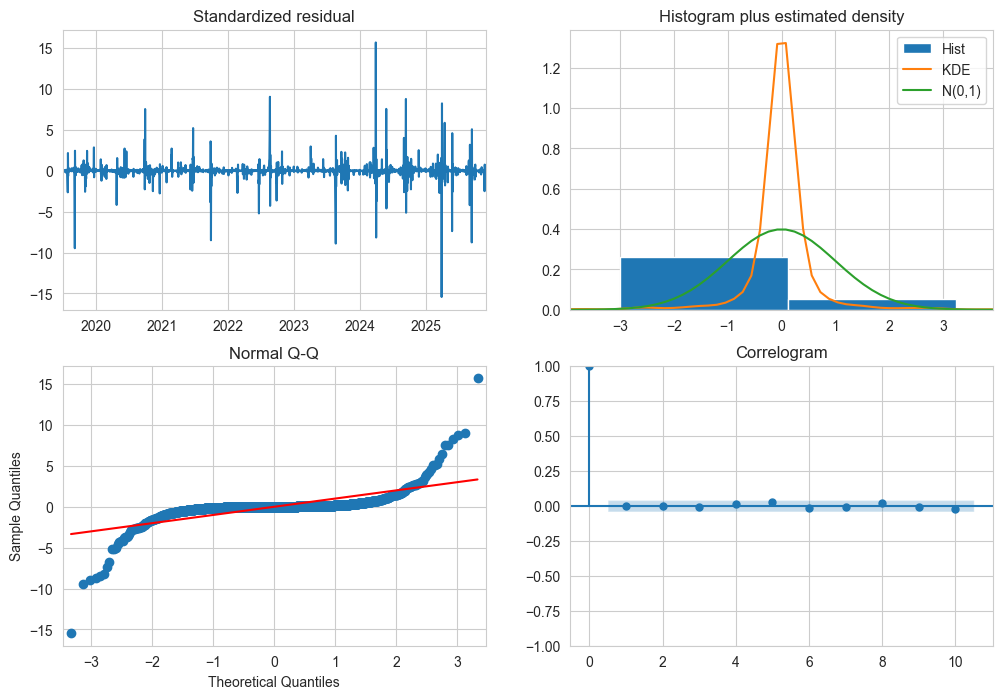

In [250]:
model.plot_diagnostics(figsize=(12, 8))
plt.show()

In [251]:
n = len(dust_test)

# forecastingam diff erdveje
forecast_diff, conf_int = model.predict(n_periods=n, return_conf_int=True)

# atstatom tai ka pasalinom (y_t - y_{t-365}) + y_{t-365} = y_t
# base = pans_train['pans'].shift(365).iloc[-n:].values
base = dust['dust'].iloc[-365 - n : -365].values
forecast_real = forecast_diff + base

sarima_dust = pd.Series(forecast_real, index=dust_test.index)
conf_int_real = conf_int + base.reshape(-1, 1)

In [252]:
y_true = dust_test['dust']
y_pred = sarima_dust

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

MSE: 0.78
MAE: 0.53
RMSE: 0.88
R²: -0.0868


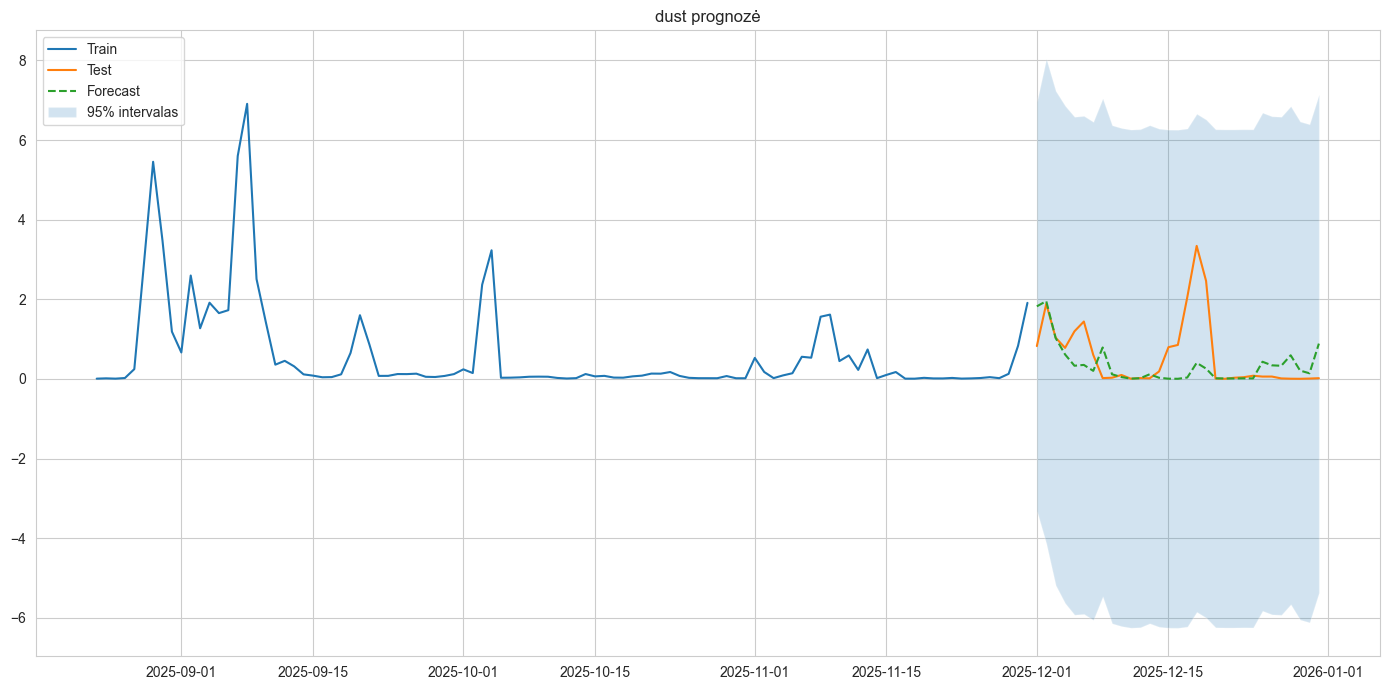

In [253]:
plt.figure(figsize=(14, 7))

plt.plot(dust_train.tail(100).index, dust_train.tail(100)['dust'], label='Train')
plt.plot(dust_test.index, dust_test['dust'], label='Test')
plt.plot(sarima_dust.index, sarima_dust, linestyle='--', label='Forecast')

plt.fill_between(dust_test.index,
                 conf_int_real[:, 0],
                 conf_int_real[:, 1],
                 alpha=0.2,
                 label='95% intervalas')

plt.title('dust prognozė')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Palyginimas

In [288]:
def plot_all_forecasts(history, actual, forecasts_dict, title="Modelių palyginimas"):
    plt.figure(figsize=(14, 7))

    last_history_point = history.tail(1)
    
    history_to_plot = history.tail(365) 
    plt.plot(history_to_plot.index, history_to_plot.values, color='red', linewidth=1)
    
    actual_joined = pd.concat([last_history_point, actual])
    plt.plot(actual_joined.index, actual_joined.values, label='Tikros reikšmės', color='red', linewidth=1)
    
    for name, values in forecasts_dict.items():
        if not isinstance(values, pd.Series):
            values = pd.Series(values, index=actual.index)
        
        forecast_joined = pd.concat([last_history_point, values])
        
        plt.plot(forecast_joined.index, forecast_joined.values, label=name, linestyle='--')

    
    plt.title(title)
    plt.xlabel('Data')
    plt.ylabel('Koncentracija')
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()


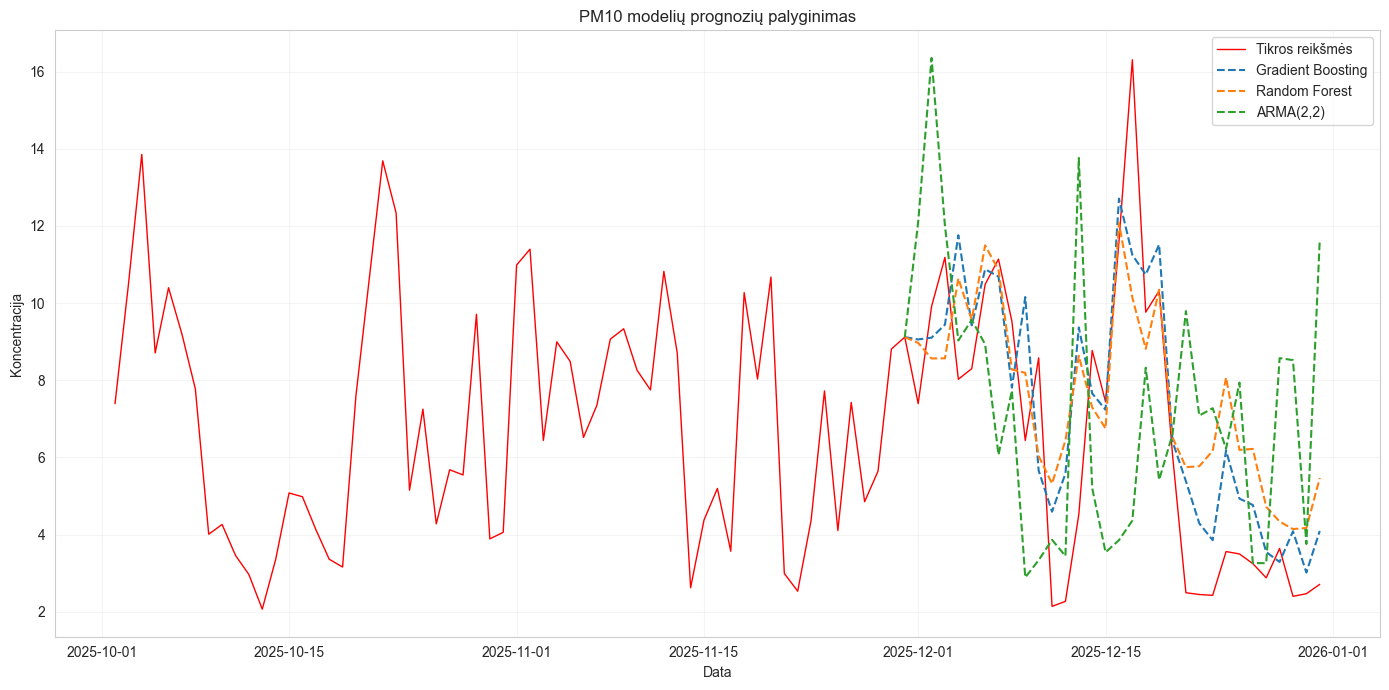

In [273]:
pm10_results = {
    'Gradient Boosting': pd.Series(y_pred_pm10_gbr, index=y_test_pm10.index),
    'Random Forest': pd.Series(y_pred_pm10_rf, index=y_test_pm10.index),
    'ARMA(2,2)': pd.Series(sarima_pm10, index=y_test_pm10.index)
}

plot_all_forecasts(y_train_pm10, y_test_pm10, pm10_results, title="PM10 modelių prognozių palyginimas")

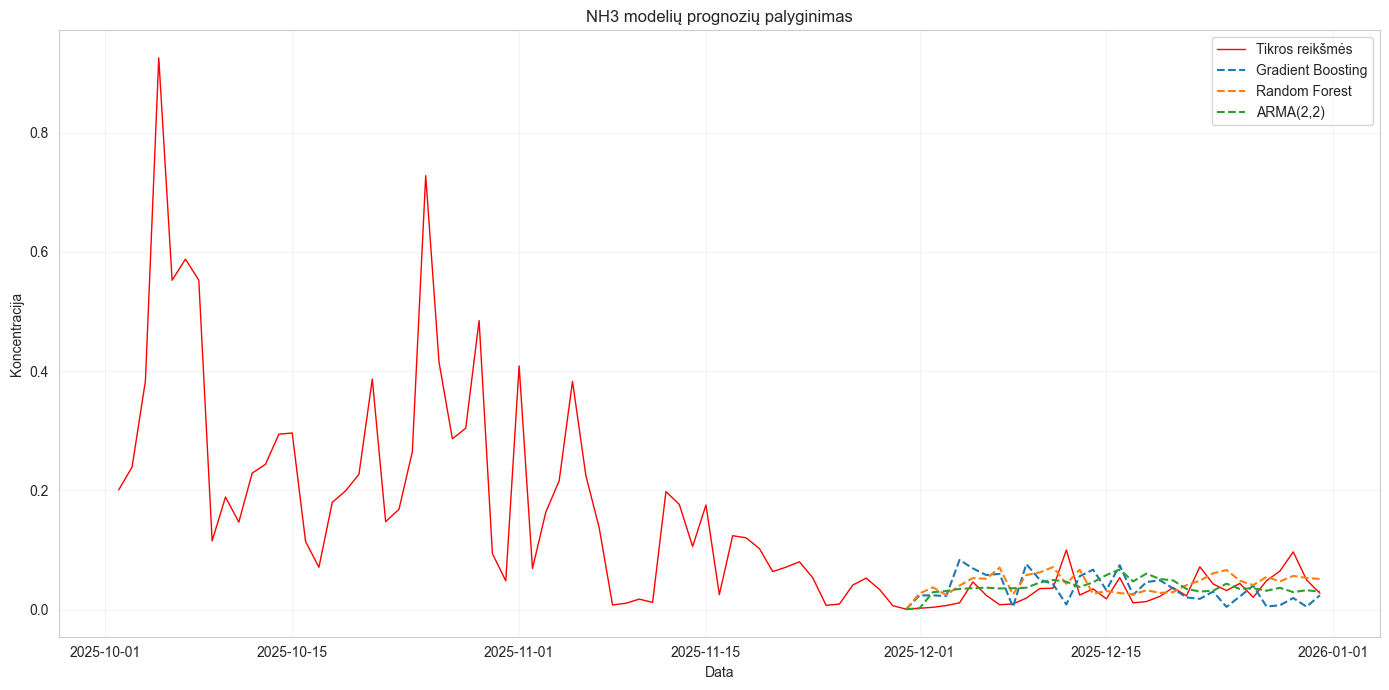

In [274]:
nh3_results = {
    'Gradient Boosting': pd.Series(y_pred_nh3_gbr, index=y_test_nh3.index),
    'Random Forest': pd.Series(y_pred_nh3_rf, index=y_test_nh3.index),
    'ARMA(2,2)': pd.Series(sarima_nh3, index=y_test_nh3.index)
}

plot_all_forecasts(y_train_nh3, y_test_nh3, nh3_results, title="NH3 modelių prognozių palyginimas")

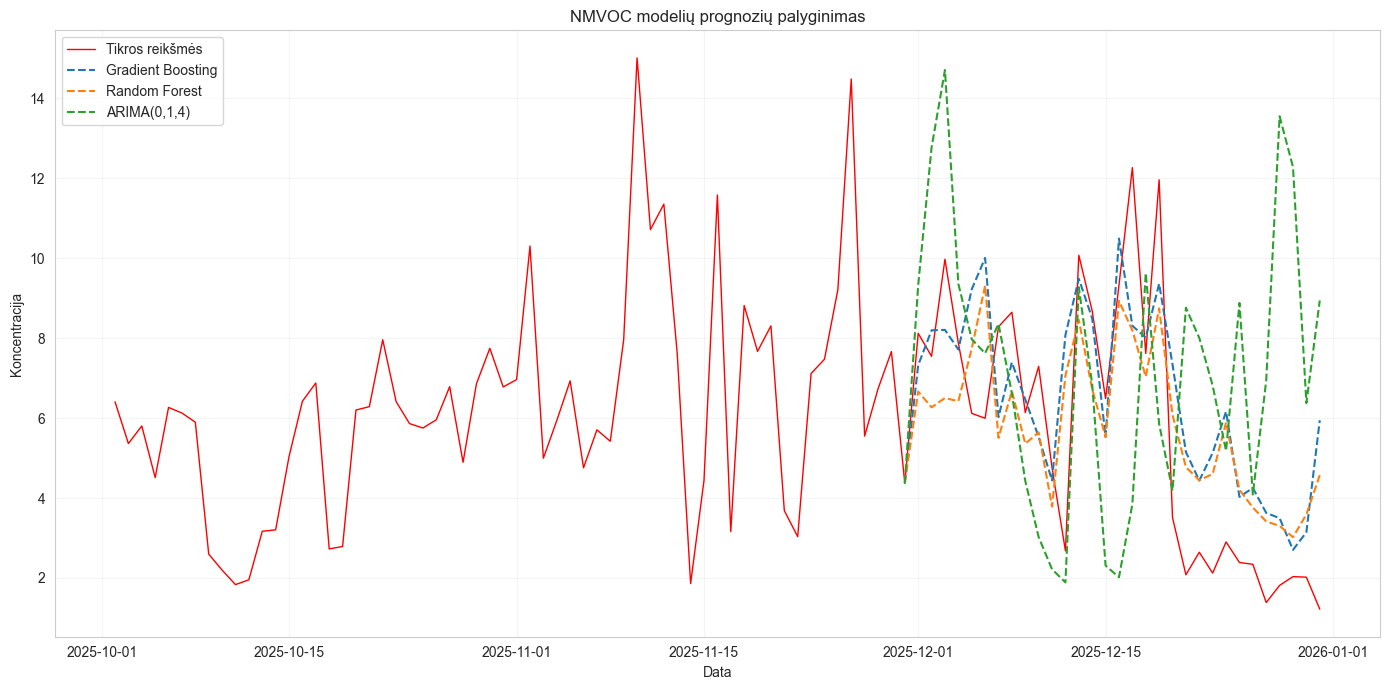

In [275]:
nmvoc_results = {
    'Gradient Boosting': pd.Series(y_pred_nmvoc_gbr, index=y_test_nmvoc.index),
    'Random Forest': pd.Series(y_pred_nmvoc_rf, index=y_test_nmvoc.index),
    'ARIMA(0,1,4)': pd.Series(sarima_nmvoc, index=y_test_nmvoc.index)
}

plot_all_forecasts(y_train_nmvoc, y_test_nmvoc, nmvoc_results, title="NMVOC modelių prognozių palyginimas")

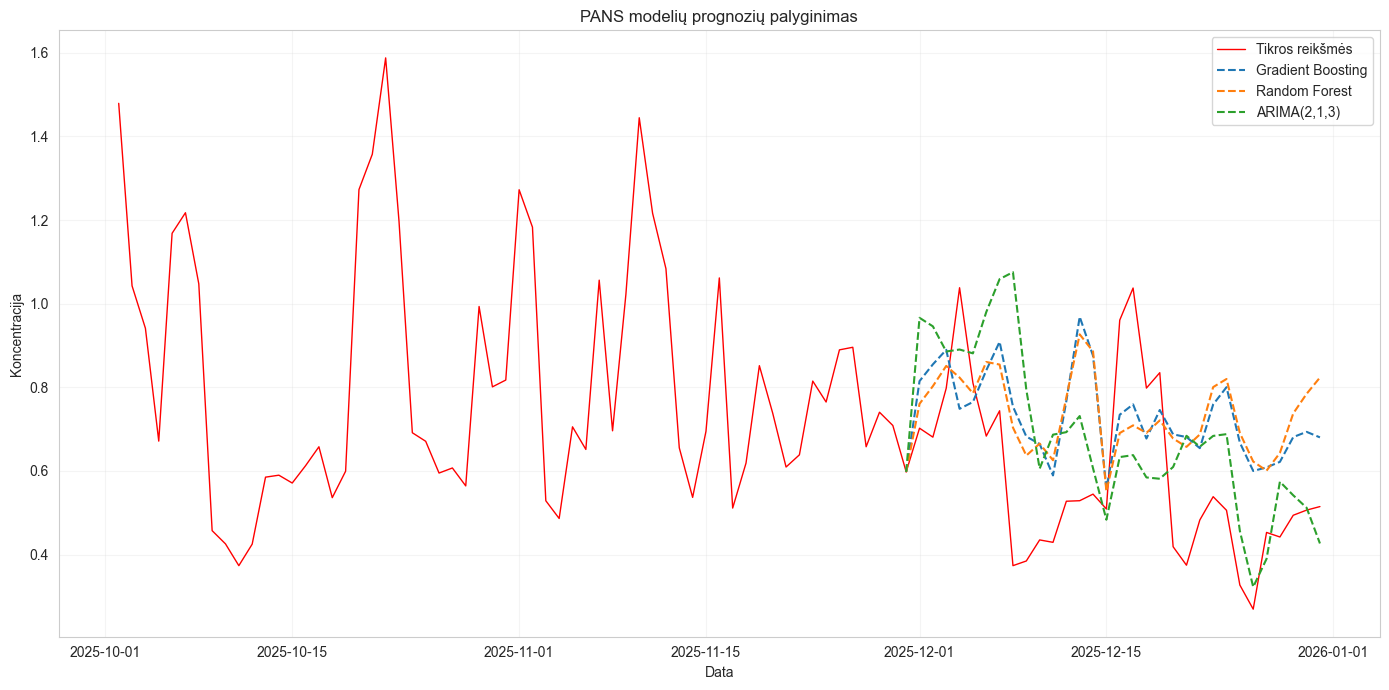

In [276]:
pans_results = {
    'Gradient Boosting': pd.Series(y_pred_pans_gbr, index=y_test_pans.index),
    'Random Forest': pd.Series(y_pred_pans_rf, index=y_test_pans.index),
    'ARIMA(2,1,3)': pd.Series(sarima_pans, index=y_test_pans.index)
}

plot_all_forecasts(y_train_pans, y_test_pans, pans_results, title="PANS modelių prognozių palyginimas")

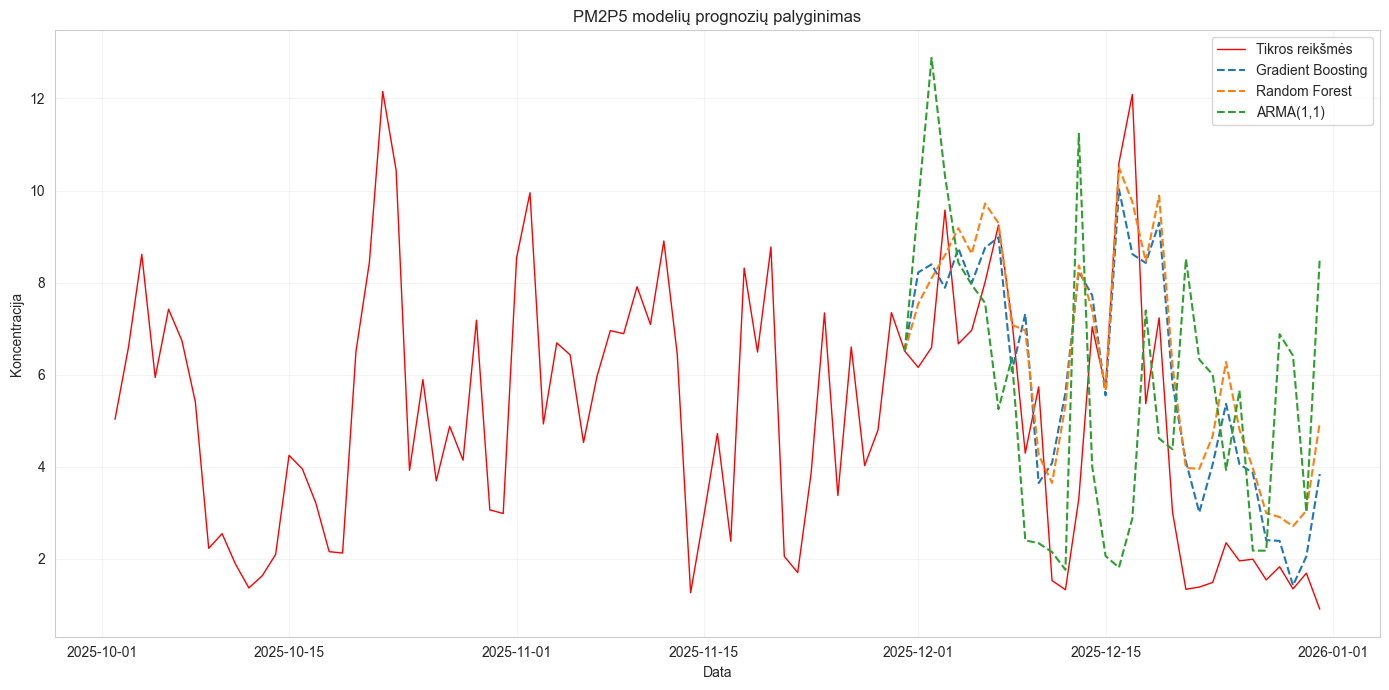

In [277]:
pm2p5_results = {
    'Gradient Boosting': pd.Series(y_pred_pm2p5_gbr, index=y_test_pm2p5.index),
    'Random Forest': pd.Series(y_pred_pm2p5_rf, index=y_test_pm2p5.index),
    'ARMA(1,1)': pd.Series(sarima_pm2p5, index=y_test_pm2p5.index)
}

plot_all_forecasts(y_train_pm2p5, y_test_pm2p5, pm2p5_results, title="PM2P5 modelių prognozių palyginimas")

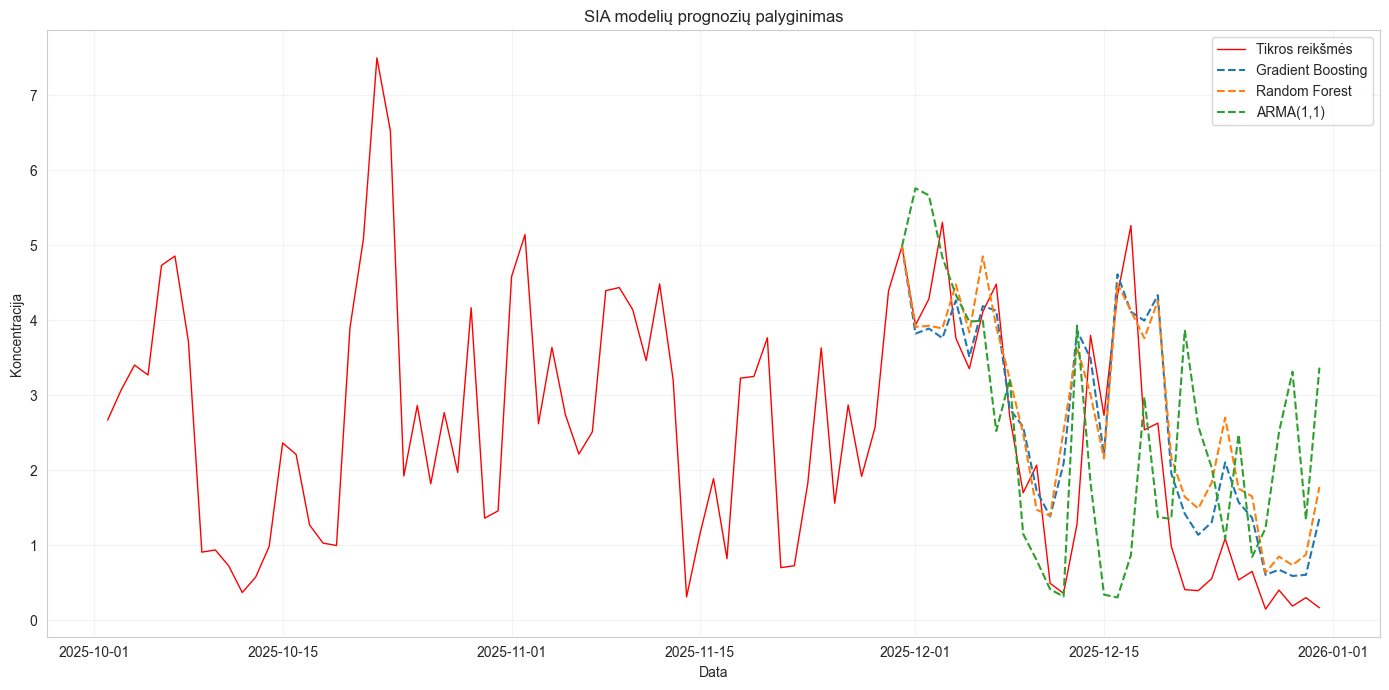

In [278]:
sia_results = {
    'Gradient Boosting': pd.Series(y_pred_sia_gbr, index=y_test_sia.index),
    'Random Forest': pd.Series(y_pred_sia_rf, index=y_test_sia.index),
    'ARMA(1,1)': pd.Series(sarima_sia, index=y_test_sia.index)
}

plot_all_forecasts(y_train_sia, y_test_sia, sia_results, title="SIA modelių prognozių palyginimas")

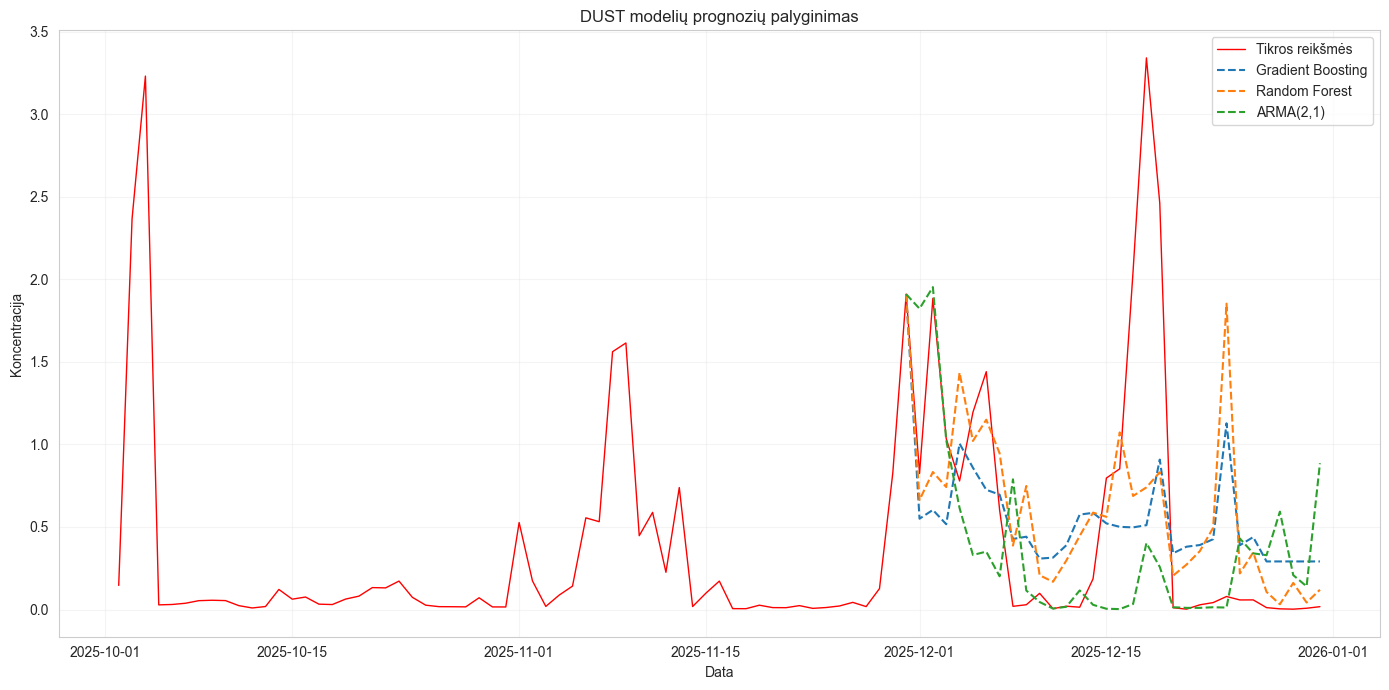

In [279]:
dust_results = {
    'Gradient Boosting': pd.Series(y_pred_dust_gbr, index=y_test_dust.index),
    'Random Forest': pd.Series(y_pred_dust_rf, index=y_test_dust.index),
    'ARMA(2,1)': pd.Series(sarima_dust, index=y_test_dust.index)
}

plot_all_forecasts(y_train_dust, y_test_dust, dust_results, title="DUST modelių prognozių palyginimas")

# Galutinis prognozavimas

## Gradent Boosting

### PM10

Mokymo rinkinio stulpeliai: ['absorbing_aerosol_index', 'NO2_column_number_density', 'stratospheric_NO2_column_number_density', 'NO2_slant_column_number_density', 'tropopause_pressure', 'H2O_column_number_density', 'BrO', 'NO2', 'O3', 'airTemperature', 'seaLevelPressure', 'relativeHumidity', 'missforest_precipitation', 'xgb_cloudCover', 'feelsLikeTemperature_fixed', 'windSpeed_fixed', 'windGust_fixed', 'windDirection_fixed', 'day_of_year', 'month', 'dust_lag_31', 'sia_lag_31', 'pm2p5_lag_31', 'pans_lag_31', 'nmvoc_lag_31', 'nh3_lag_31', 'pm10_lag_31']
X_train eilučių: 2710, X_to_predict eilučių: 31

--- Sausio mėnesio prognozės fragmentas ---
observationTime
2026-01-01    6.586185
2026-01-02    5.258616
2026-01-03    5.528557
2026-01-04    6.916999
2026-01-05    8.114452
2026-01-06    7.764056
2026-01-07    8.910037
2026-01-08    7.338350
2026-01-09    4.592320
2026-01-10    4.189254
dtype: float64


C:\Users\rugil\AppData\Local\Temp\ipykernel_13308\3743464361.py:9: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  actual_joined = pd.concat([last_history_point, actual])


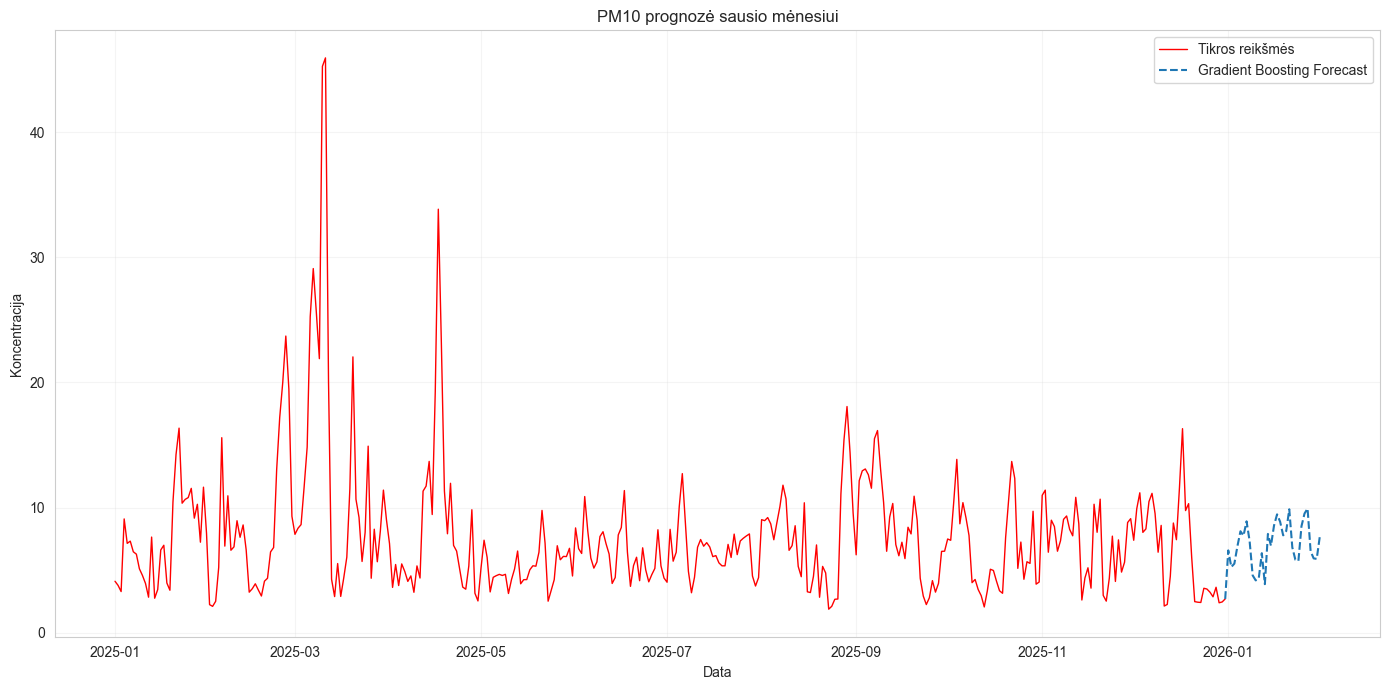

In [289]:
pollution_others = ['dust', 'sia', 'pm2p5', 'pans', 'nmvoc', 'nh3', 'pm10']
target = 'pm10'

forecasting_pm10 = data_for_forecasting.copy()
for col in pollution_others:
    forecasting_pm10[f'{col}_lag_31'] = forecasting_pm10[col].shift(31)

# forecasting_pm10['day_of_year'] = forecasting_pm10.index.dayofyear
# forecasting_pm10['month'] = forecasting_pm10.index.month

cols_to_drop_now = [c for c in pollution_others if c != target]
forecasting_pm10.drop(columns=cols_to_drop_now, inplace=True)

train_mask = (forecasting_pm10.index < '2026-01-01') & (forecasting_pm10[target].notna())
train_data = forecasting_pm10[train_mask].dropna()

predict_mask = (forecasting_pm10.index >= '2026-01-01') & (forecasting_pm10.index < '2026-02-01')
predict_data = forecasting_pm10[predict_mask]

X_train = train_data.drop(columns=[target])
y_train = train_data[target]

X_to_predict = predict_data.drop(columns=[target])

print(f"Mokymo rinkinio stulpeliai: {X_train.columns.tolist()}")
print(f"X_train eilučių: {len(X_train)}, X_to_predict eilučių: {len(X_to_predict)}")

january_predictions = best_model_pm10.predict(X_to_predict)
january_forecast_series = pd.Series(january_predictions, index=X_to_predict.index)

print("\n--- Sausio mėnesio prognozės fragmentas ---")
print(january_forecast_series.head(10))

forecasts_dict = {'Gradient Boosting Forecast': january_forecast_series}
plot_all_forecasts(y_train, pd.Series(dtype=float), forecasts_dict, title="PM10 prognozė sausio mėnesiui")

### PM2P5

### SIA

## Random forest

### NMVOC

### DUST

## SARIMA

### NH3

### PANS

# Galutinis apjungimas

In [262]:
# final_filled_data = filled_data[[
#     'airTemperature',
#     'seaLevelPressure',
#     'relativeHumidity',
#     'xgb_precipitation',
#     'xgb_cloudCover',
#     'feelsLikeTemperature_fixed',
#     'windSpeed_fixed',
#     'windGust_fixed',
#     'windDirection_fixed',
#     'absorbing_aerosol_index', 
#     'NO2_column_number_density', 
#     'stratospheric_NO2_column_number_density',
#     'NO2_slant_column_number_density',
#     'tropopause_pressure',
#     'H2O_column_number_density',
#     'BrO',
#     'BrO_Error',
#     'NO2',
#     'NO2_Error',
#     'O3',
#     'O3_Error'
#     ]]

In [263]:
# data_for_forecasting = final_filled_data.join(data_to_forecast)
# data_for_forecasting

In [264]:
# ecmwf_data = pd.read_csv("Vilnius_ecmwf_data_2017_2026.csv")
# ecmwf_data.head()
# ecmwf_data = ecmwf_data.drop_duplicates(subset=['time'], keep='first')

# ecmwf_data['time'] = pd.to_datetime(ecmwf_data['time'])
# ecmwf_data.set_index('time', inplace=True)

In [265]:
# final_data = data_for_forecasting.merge(
#     ecmwf_data, 
#     left_index=True, 
#     right_on='time', 
#     how='left'
# )
# final_data

In [266]:
# final_data.min()

In [267]:
# (final_data < 0).sum()

In [268]:
# final_data.to_csv('dm_project_dataset_alpha.csv', index=True, sep=',', encoding='utf-8')